# Software Defect Prediction

## 1. Introduction

Software defect prediction applies machine learning to identify software modules that are likely to contain defects before testing or deployment. Early identification can help development teams prioritise code inspection, testing and maintenance resources. However, predictive performance alone is insufficient when complex models provide limited justification for their decisions. Explainable artificial intelligence techniques such as SHAP and LIME can identify the static code metrics contributing to model predictions.

This study develops an explainable software defect prediction framework using five PROMISE Java project datasets. Six classification algorithms are evaluated under the original and SMOTE-balanced training conditions. The selected model is subsequently interpreted using SHAP and LIME to examine influential code metrics, agreement between explanation methods and explanation stability across repeated runs.

## Problem Statement

Software defect prediction applies machine learning to identify software modules that are likely to contain defects before testing or deployment. Early identification can help development teams prioritise code inspection, testing and maintenance resources. However, predictive performance alone is insufficient when complex models provide limited justification for their decisions. Explainable artificial intelligence techniques such as SHAP and LIME can identify the static code metrics contributing to model predictions.

This study develops an explainable software defect prediction framework using five PROMISE Java project datasets. Six classification algorithms are evaluated under the original and SMOTE-balanced training conditions. The selected model is subsequently interpreted using SHAP and LIME to examine influential code metrics, agreement between explanation methods and explanation stability across repeated runs.

## Research Questions & Objectives

| Research Questions | Research Objectives |
|---|---|
| **RQ1:** How effectively do the machine learning models predict software defects under Original and SMOTE conditions? | **RO1:** To evaluate machine learning models under Original and SMOTE conditions. |
| **RQ2:** Which static code metrics are the most influential, how consistent are their rankings across software projects, and to what extent do SHAP and LIME agree? | **RO2:** To identify influential metrics and evaluate cross-project and cross-method explanation consistency. |
| **RQ3:** How stable are SHAP and LIME explanations across repeated runs under SMOTE conditions? | **RO3:** To evaluate SHAP and LIME stability across repeated runs under SMOTE conditions. |

## Data Description

The study uses five open-source Java project datasets obtained from the PROMISE software engineering repository: Ant 1.7, Camel 1.6, Log4j 1.2, Poi 3.0 and Xalan 2.7. Ant is a build-automation tool, Camel is an integration framework, Log4j is a logging library, Poi provides APIs for Microsoft Office documents, and Xalan is an XML transformation library. Each observation represents a software module or Java class.

| Dataset   | Modules | Non-defective | Defective | Defective rate |
| --------- | ------: | ------------: | --------: | -------------: |
| Ant 1.7   |     745 |           579 |       166 |         22.28% |
| Camel 1.6 |     965 |           777 |       188 |         19.48% |
| Log4j 1.2 |     205 |            16 |       189 |         92.20% |
| Poi 3.0   |     442 |           161 |       281 |         63.57% |
| Xalan 2.7 |     909 |            11 |       898 |         98.79% |

Each original dataset contains 24 columns: three metadata fields, 20 object-oriented static code metrics and the raw `bug` count. The metrics describe characteristics such as code size, complexity, coupling, cohesion and inheritance. The target was transformed into a binary variable where `defective = 1` when `bug > 0`, and `defective = 0` otherwise.

The metadata fields and raw bug count were excluded from modelling. Correlation-based redundancy screening removed `dit`, `rfc`, `ic` and `max_cc`, resulting in a common set of 16 predictors across all projects. The data show different imbalance directions: defective modules are the minority in Ant and Camel, whereas non-defective modules are the minority in Log4j, Poi and Xalan. Stratified 70:30 train-test splitting was used, and SMOTE was applied only to the training data.


## 2. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/Software_Defect_Prediction/data/"

In [4]:
PROJECT_FILES = {
    "Ant 1.7":   "ant-1.7.csv",
    "Camel 1.6": "camel-1.6.csv",
    "Log4j 1.2": "log4j-1.2.csv",
    "Poi 3.0":   "poi-3.0.csv",
    "Xalan 2.7": "xalan-2.7.csv",
}

datasets = {
    name: pd.read_csv(DATA_PATH + filename)
    for name, filename in PROJECT_FILES.items()
}

print("All datasets loaded successfully.\n")
for name, df in datasets.items():
    print(f"  {name:<12} {df.shape[0]:>4} rows x {df.shape[1]} columns")

All datasets loaded successfully.

  Ant 1.7       745 rows x 24 columns
  Camel 1.6     965 rows x 24 columns
  Log4j 1.2     205 rows x 24 columns
  Poi 3.0       442 rows x 24 columns
  Xalan 2.7     909 rows x 24 columns


In [5]:
# The 20 object-oriented static code metrics, consistent across all five datasets
metric_cols = [
    'wmc', 'dit', 'noc', 'cbo', 'rfc', 'lcom', 'ca', 'ce', 'npm',
    'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'ic', 'cbm', 'amc',
    'max_cc', 'avg_cc'
]

# Non-predictive identifier fields
metadata_cols = ['name', 'version', 'name.1']

# Theoretical minima used for the impossible-value screen in Section 3.4
THEORETICAL_MINIMA = {m: 0 for m in metric_cols}
THEORETICAL_MINIMA['dit'] = 1   # depth of inheritance tree is >= 1 by definition

print(f"{len(metric_cols)} static code metrics defined.")


20 static code metrics defined.


## 3. Data Preprocessing and Quality Assessment

### 3.1 Schema Consistency

In [6]:
schema_check = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Columns": [df.shape[1] for df in datasets.values()],
    "Schema identical to Ant 1.7": [
        list(df.columns) == list(datasets["Ant 1.7"].columns)
        for df in datasets.values()
    ],
})
display(schema_check)

,Dataset,Columns,Schema identical to Ant 1.7
0,Ant 1.7,24,True
1,Camel 1.6,24,True
2,Log4j 1.2,24,True
3,Poi 3.0,24,True
4,Xalan 2.7,24,True


## 3.2 Data Types

In [7]:
dtype_summary = pd.DataFrame({
    name: df.dtypes.astype(str) for name, df in datasets.items()
})
display(dtype_summary)


,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7
name,object,object,object,object,object
version,float64,float64,float64,int64,object
name.1,object,object,object,object,object
wmc,int64,int64,int64,int64,int64
dit,int64,int64,int64,int64,int64
noc,int64,int64,int64,int64,int64
cbo,int64,int64,int64,int64,int64
rfc,int64,int64,int64,int64,int64
lcom,int64,int64,int64,int64,int64
ca,int64,int64,int64,int64,int64


### 3.3 Missing Values, Duplicates and Module Uniqueness

In [8]:
quality_rows = []
for name, df in datasets.items():
    quality_rows.append({
        "Dataset": name,
        "Instances": df.shape[0],
        "Initial Variables": df.shape[1],
        "Missing Values": int(df.isnull().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
        "Unique Modules": int(df["name.1"].nunique()),
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

,Dataset,Instances,Initial Variables,Missing Values,Duplicate Rows,Unique Modules
0,Ant 1.7,745,24,0,0,745
1,Camel 1.6,965,24,0,0,965
2,Log4j 1.2,205,24,0,0,205
3,Poi 3.0,442,24,0,0,442
4,Xalan 2.7,909,24,0,0,909


### 3.4 Invalid Value Screening

In [9]:
invalid_rows = []
for name, df in datasets.items():
    negative_counts = (df[metric_cols] < 0).sum().sum()
    invalid_dit = (df["dit"] < 1).sum() if "dit" in df.columns else np.nan
    invalid_rows.append({
        "Dataset": name,
        "Negative metric values": int(negative_counts),
        "DIT < 1 (theoretical min)": int(invalid_dit),
    })

display(pd.DataFrame(invalid_rows))

,Dataset,Negative metric values,DIT < 1 (theoretical min)
0,Ant 1.7,0,0
1,Camel 1.6,0,37
2,Log4j 1.2,0,0
3,Poi 3.0,0,0
4,Xalan 2.7,0,0


### 3.5 Raw Target Distribution

In [10]:
bug_dist = pd.DataFrame({
    name: df["bug"].value_counts().sort_index()
    for name, df in datasets.items()
}).fillna(0).astype(int)
bug_dist.index.name = "bug count"
display(bug_dist)

,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7
bug count,,,,,
0,579,777,16,161,11
1,93,101,18,201,660
2,30,32,100,43,189
3,16,16,40,14,35
4,15,14,15,8,8
5,4,6,8,5,2
6,4,2,2,2,1
7,1,3,3,0,2
8,2,5,1,1,1


In [11]:
bug_summary = pd.DataFrame([{
    "Dataset": name,
    "Max bug count": int(df["bug"].max()),
    "Mean bug count": round(df["bug"].mean(), 3),
    "Instances with bug = 0": int((df["bug"] == 0).sum()),
    "Instances with bug > 0": int((df["bug"] > 0).sum()),
} for name, df in datasets.items()])
display(bug_summary)

,Dataset,Max bug count,Mean bug count,Instances with bug = 0,Instances with bug > 0
0,Ant 1.7,10,0.454,579,166
1,Camel 1.6,28,0.518,777,188
2,Log4j 1.2,10,2.429,16,189
3,Poi 3.0,19,1.131,161,281
4,Xalan 2.7,8,1.334,11,898


## 4. Exploratory Data Analysis

### 4.1 Class Distribution

In [12]:
class_dist_rows = []
for name, df in datasets.items():
    defective = (df["bug"] > 0).astype(int)
    n_def = int(defective.sum())
    n_nondef = len(df) - n_def
    pct_def = 100 * n_def / len(df)
    pct_nondef = 100 - pct_def
    class_dist_rows.append({
        "Dataset": name,
        "Instances": len(df),
        "Non-defective": n_nondef,
        "Defective": n_def,
        "Non-defective %": round(pct_nondef, 2),
        "Defective %": round(pct_def, 2),
        "Minority %": round(min(pct_def, pct_nondef), 2),
        "Minority class": "Defective" if pct_def < pct_nondef else "Non-defective",
        "Imbalance ratio": round(max(n_def, n_nondef) / max(min(n_def, n_nondef), 1), 1),
    })

class_dist_df = pd.DataFrame(class_dist_rows).sort_values("Minority %", ascending=False)
display(class_dist_df)

,Dataset,Instances,Non-defective,Defective,Non-defective %,Defective %,Minority %,Minority class,Imbalance ratio
3,Poi 3.0,442,161,281,36.43,63.57,36.43,Non-defective,1.7
0,Ant 1.7,745,579,166,77.72,22.28,22.28,Defective,3.5
1,Camel 1.6,965,777,188,80.52,19.48,19.48,Defective,4.1
2,Log4j 1.2,205,16,189,7.80,92.20,7.80,Non-defective,11.8
4,Xalan 2.7,909,11,898,1.21,98.79,1.21,Non-defective,81.6


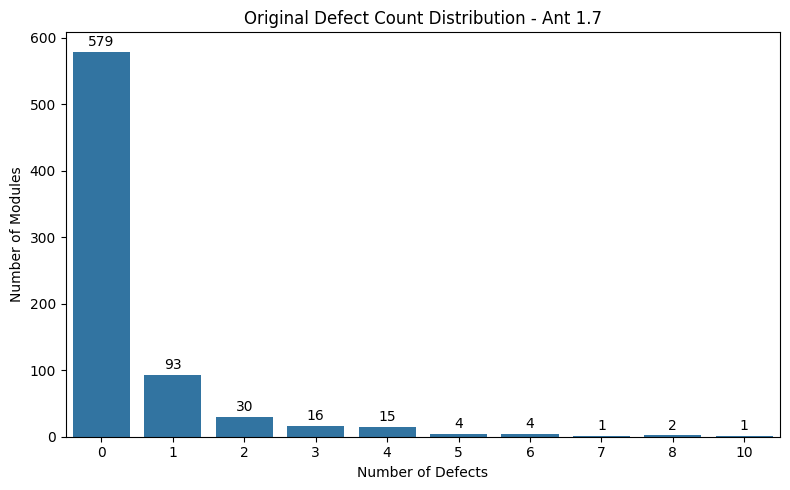

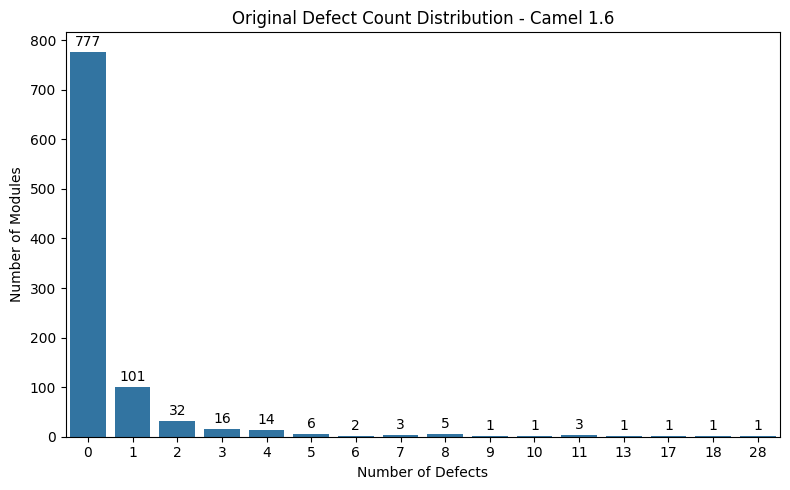

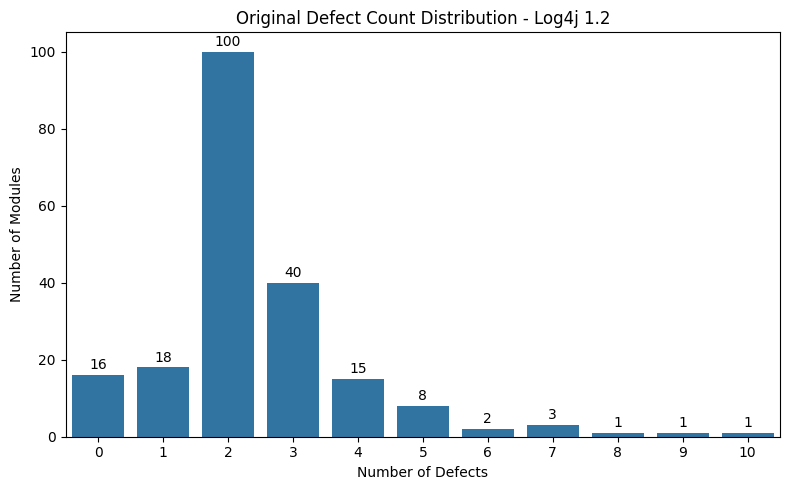

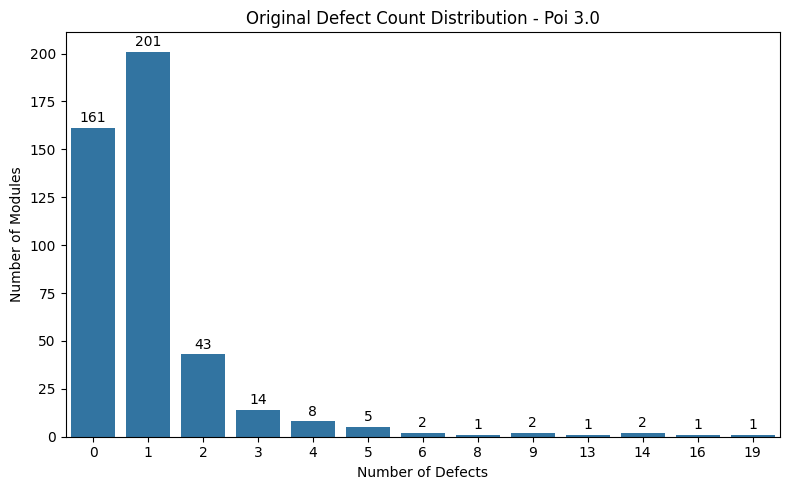

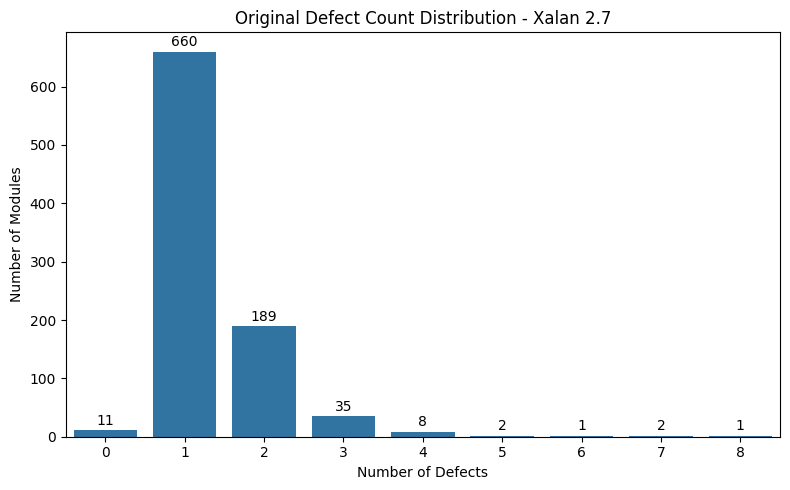

In [13]:
# Original Bug count Distribution
for name, df in datasets.items():

    plt.figure(figsize=(8, 5))

    ax = sns.countplot(
        data=df,
        x='bug'
    )

    for container in ax.containers:
      ax.bar_label(container, padding = 2)

    plt.title(
        f'Original Defect Count Distribution - {name}'
    )

    plt.xlabel('Number of Defects')
    plt.ylabel('Number of Modules')

    plt.tight_layout()
    plt.show()

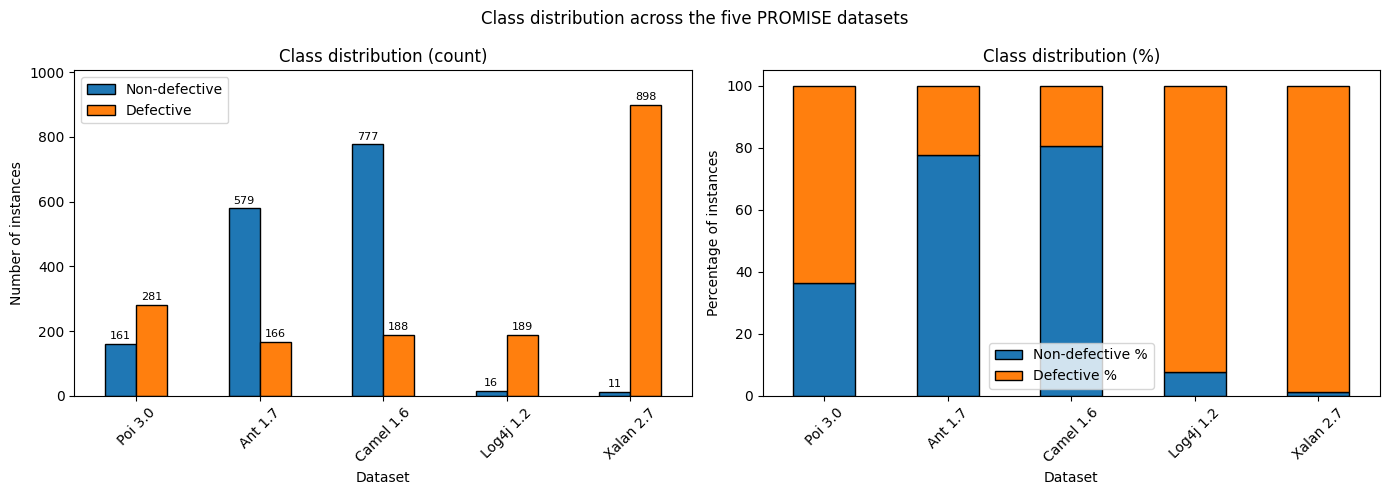

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = class_dist_df.set_index("Dataset")
plot_df[["Non-defective", "Defective"]].plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_ylabel("Number of instances")
axes[0].set_title("Class distribution (count)")
axes[0].tick_params(axis="x", rotation=45)

# label each bar with its count
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=2, fontsize=8)

axes[0].margins(y=0.12)   # headroom so labels aren't clipped

plot_df[["Non-defective %", "Defective %"]].plot(
    kind="bar", stacked=True, ax=axes[1], edgecolor="black"
)
axes[1].set_ylabel("Percentage of instances")
axes[1].set_title("Class distribution (%)")
axes[1].tick_params(axis="x", rotation=45)


plt.suptitle("Class distribution across the five PROMISE datasets")
plt.tight_layout()
plt.show()

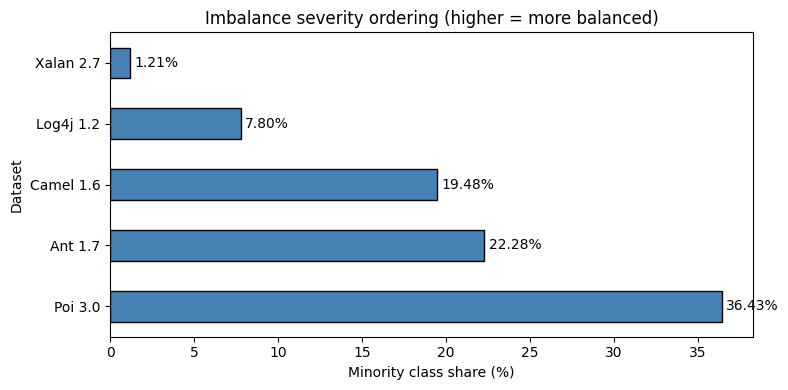

In [15]:
ax = class_dist_df.set_index("Dataset")["Minority %"].plot(
    kind="barh", figsize=(8, 4), edgecolor="black", color="steelblue"
)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", padding=3)
ax.set_xlabel("Minority class share (%)")
ax.set_title("Imbalance severity ordering (higher = more balanced)")
plt.tight_layout()
plt.show()

### 4.2 Descriptive Statistics of Static Code Metrics

In [16]:
descriptive_stats = {}
for name, df in datasets.items():
    descriptive_stats[name] = df[metric_cols].describe().T.round(2)

# Full table for one dataset; the remainder are stored in `descriptive_stats`
# and exported to CSV in Section 6 for the appendix.
print("Full descriptive statistics — Ant 1.7")
display(descriptive_stats["Ant 1.7"])


Full descriptive statistics — Ant 1.7


,count,mean,std,min,25%,50%,75%,max
wmc,745.0,11.07,11.98,0.0,4.00,7.00,14.00,120.00
dit,745.0,2.52,1.40,1.0,1.00,2.00,4.00,7.00
noc,745.0,0.73,4.80,0.0,0.00,0.00,0.00,102.00
cbo,745.0,11.05,26.34,0.0,4.00,6.00,11.00,499.00
rfc,745.0,34.36,36.02,0.0,11.00,23.00,43.00,288.00
lcom,745.0,89.15,349.94,0.0,0.00,6.00,53.00,6692.00
ca,745.0,5.66,25.81,0.0,0.00,1.00,4.00,498.00
ce,745.0,5.75,5.65,0.0,2.00,4.00,8.00,37.00
npm,745.0,8.37,9.33,0.0,3.00,6.00,10.00,103.00
lcom3,745.0,1.01,0.62,0.0,0.67,0.83,1.50,2.00


In [17]:
key_metrics = ["loc", "wmc", "rfc", "cbo", "lcom"]
compare_rows = []
for name, df in datasets.items():
    row = {"Dataset": name}
    for m in key_metrics:
        row[f"{m}_mean"] = round(df[m].mean(), 2)
        row[f"{m}_median"] = round(df[m].median(), 2)
    compare_rows.append(row)

display(pd.DataFrame(compare_rows))

,Dataset,loc_mean,loc_median,wmc_mean,wmc_median,rfc_mean,rfc_median,cbo_mean,cbo_median,lcom_mean,lcom_median
0,Ant 1.7,280.07,143.0,11.07,7.0,34.36,23.0,11.05,6.0,89.15,6.0
1,Camel 1.6,117.16,57.0,8.57,5.0,21.42,14.0,11.10,7.0,79.33,4.0
2,Log4j 1.2,186.30,123.0,8.42,6.0,25.22,18.0,7.61,5.0,53.93,6.0
3,Poi 3.0,292.60,124.5,13.51,10.0,30.35,21.0,10.12,6.0,100.46,22.0
4,Xalan 2.7,471.46,175.0,10.87,5.0,29.20,17.0,11.99,6.0,125.96,3.0


### 4.3 Skewness Analysis

In [18]:
skewness_df = pd.DataFrame({
    name: df[metric_cols].skew() for name, df in datasets.items()
}).round(2)
skewness_df["Mean skew"] = skewness_df.mean(axis=1).round(2)
display(skewness_df.sort_values("Mean skew", ascending=False))

,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Mean skew
lcom,11.96,20.35,13.33,11.16,8.29,13.02
noc,15.79,8.65,7.03,16.84,7.94,11.25
amc,24.70,3.68,2.34,10.39,4.15,9.05
ca,13.67,13.07,3.65,8.97,5.36,8.94
cbo,12.82,11.41,3.39,7.13,3.88,7.73
max_cc,3.93,4.28,2.81,10.52,8.26,5.96
loc,3.86,4.15,4.64,9.49,3.06,5.04
moa,3.28,3.07,4.18,7.30,4.50,4.47
wmc,2.99,5.47,5.68,3.58,3.79,4.30
avg_cc,1.94,3.91,1.36,8.18,5.61,4.20


In [19]:
highly_skewed_counts = []
for name, df in datasets.items():
    skew = df[metric_cols].skew()
    highly_skewed_counts.append({
        "Dataset": name,
        "Metrics with |skew| > 1": int((skew.abs() > 1).sum()),
        "Metrics with |skew| > 3": int((skew.abs() > 3).sum()),
        "Most skewed metric": skew.abs().idxmax(),
        "Max |skew|": round(skew.abs().max(), 1),
    })
display(pd.DataFrame(highly_skewed_counts))

,Dataset,Metrics with |skew| > 1,Metrics with |skew| > 3,Most skewed metric,Max |skew|
0,Ant 1.7,15,10,amc,24.7
1,Camel 1.6,15,13,lcom,20.4
2,Log4j 1.2,16,10,lcom,13.3
3,Poi 3.0,16,13,noc,16.8
4,Xalan 2.7,15,12,lcom,8.3


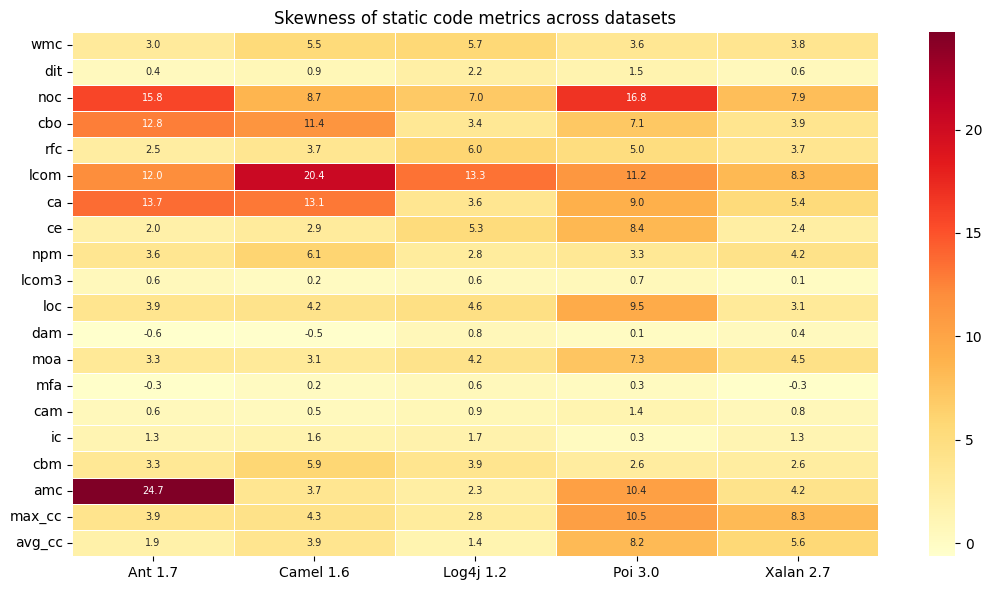

In [20]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    skewness_df.drop(columns="Mean skew"),
    annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.4, annot_kws={"size": 7}
)
plt.title("Skewness of static code metrics across datasets")
plt.tight_layout()
plt.show()


### 4.4 Distribution Visualization

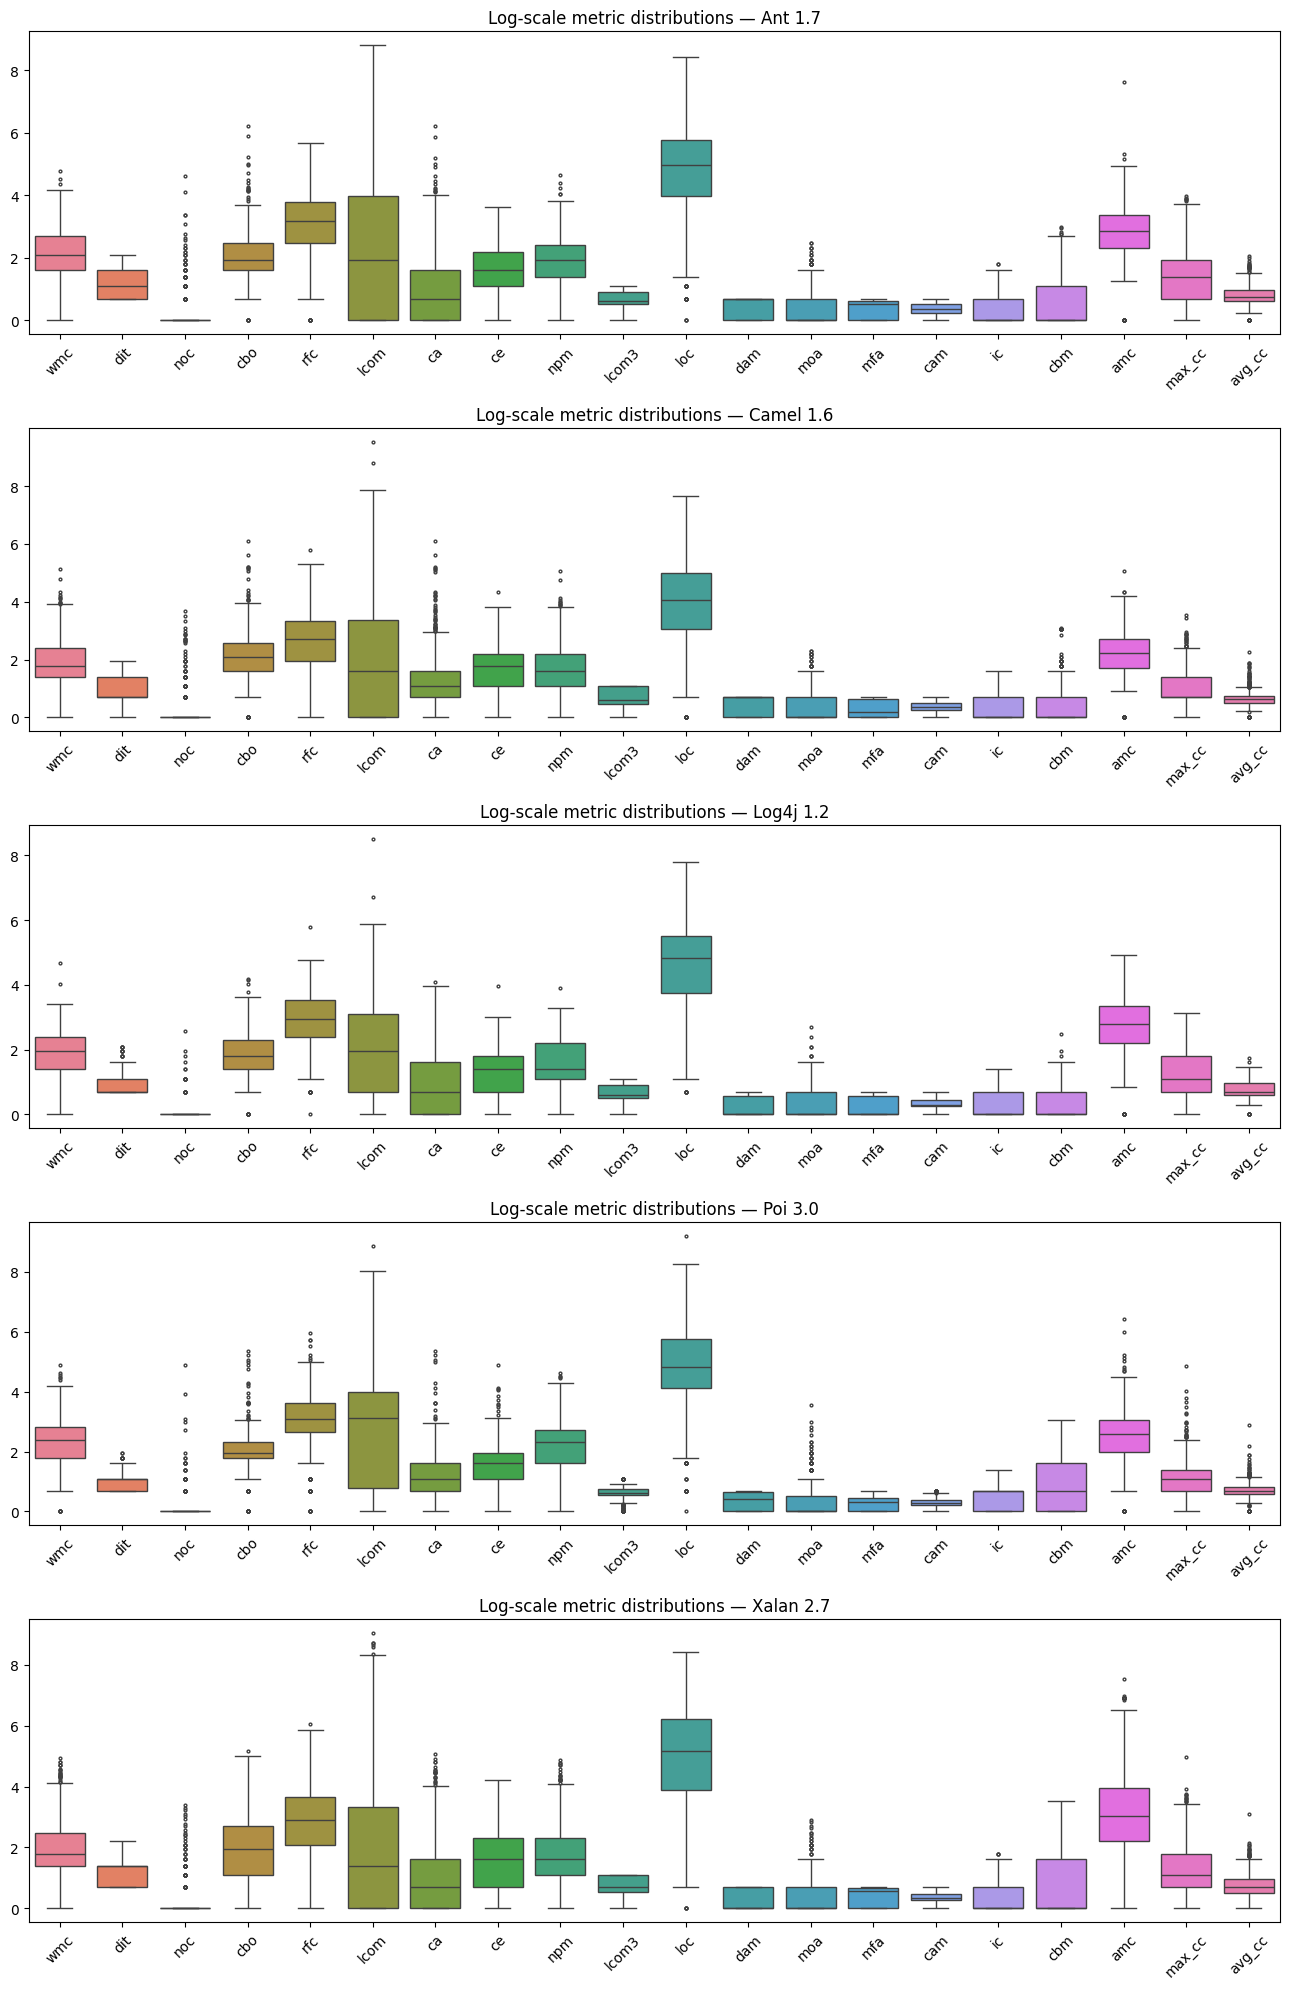

In [21]:
fig, axes = plt.subplots(5, 1, figsize=(13, 20))
for ax, (name, df) in zip(axes, datasets.items()):
    log_data = np.log1p(df[metric_cols].clip(lower=0))
    sns.boxplot(data=log_data, ax=ax, fliersize=2)
    ax.set_title(f"Log-scale metric distributions — {name}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

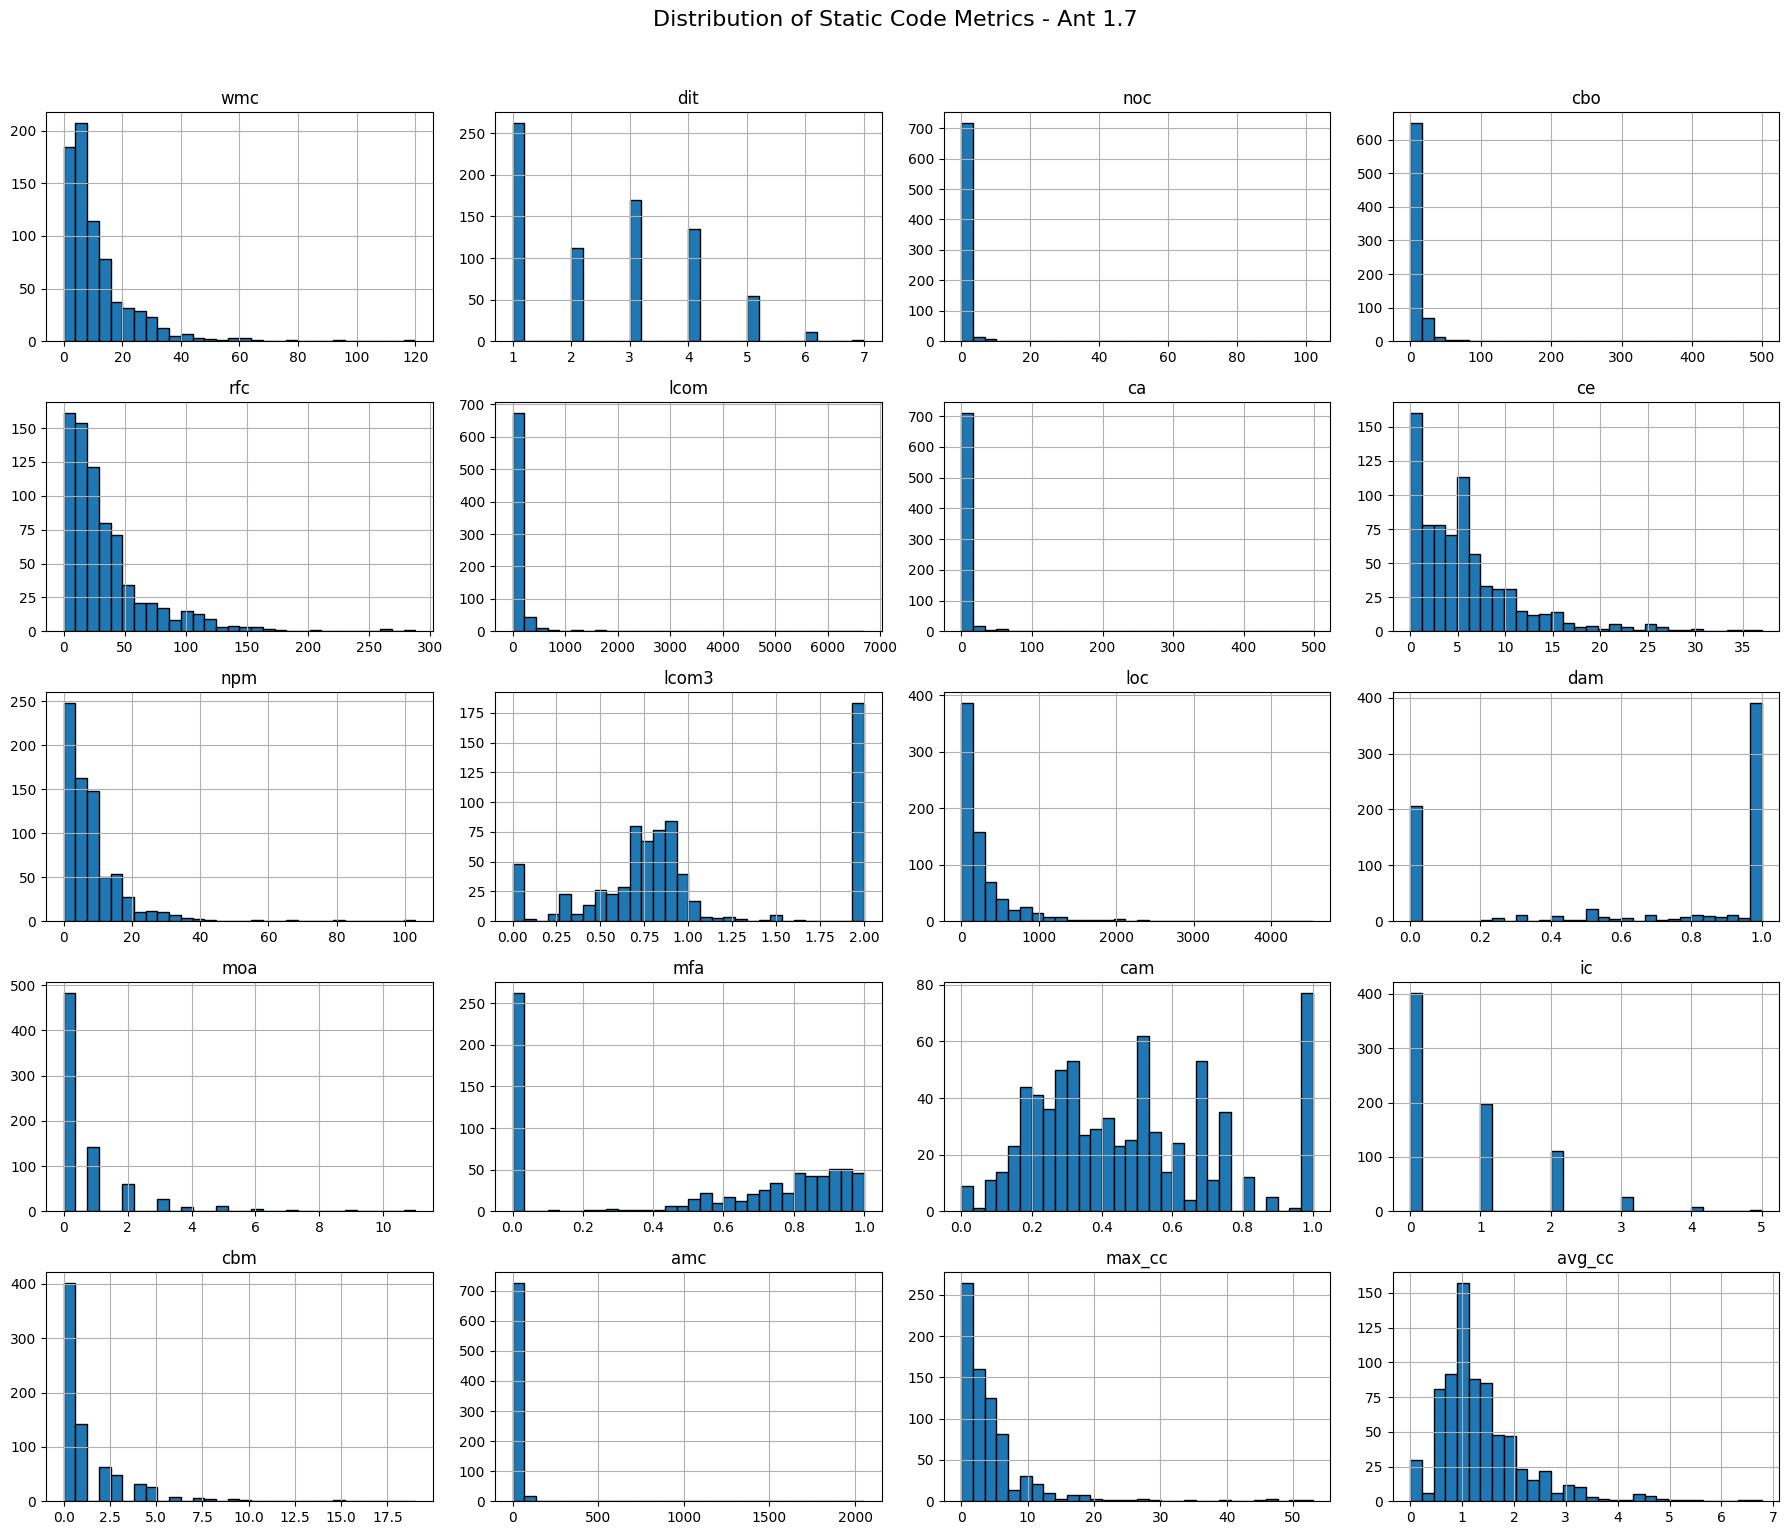

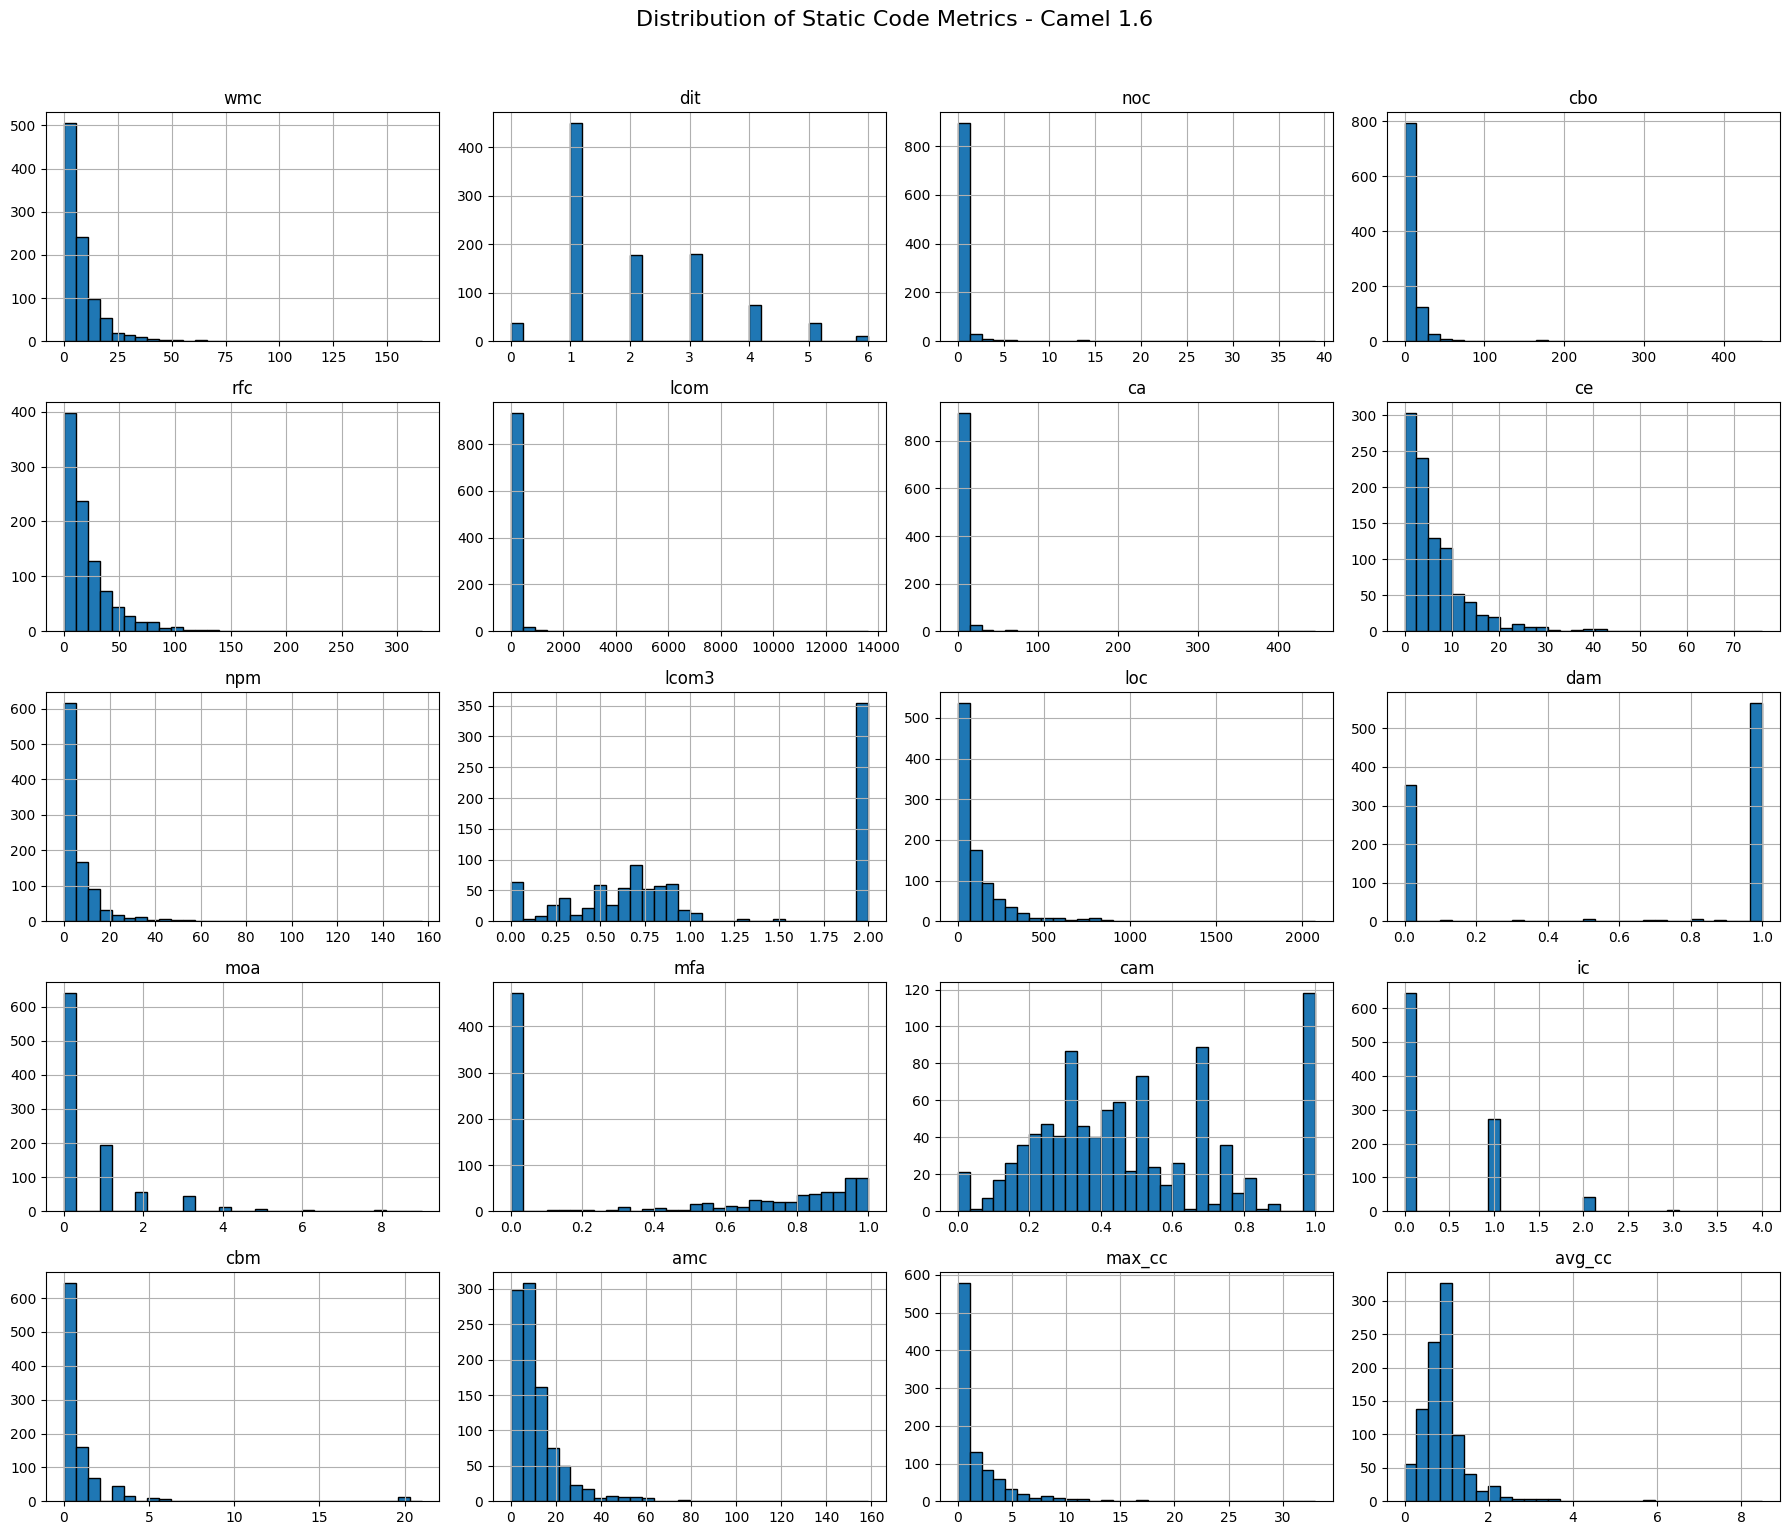

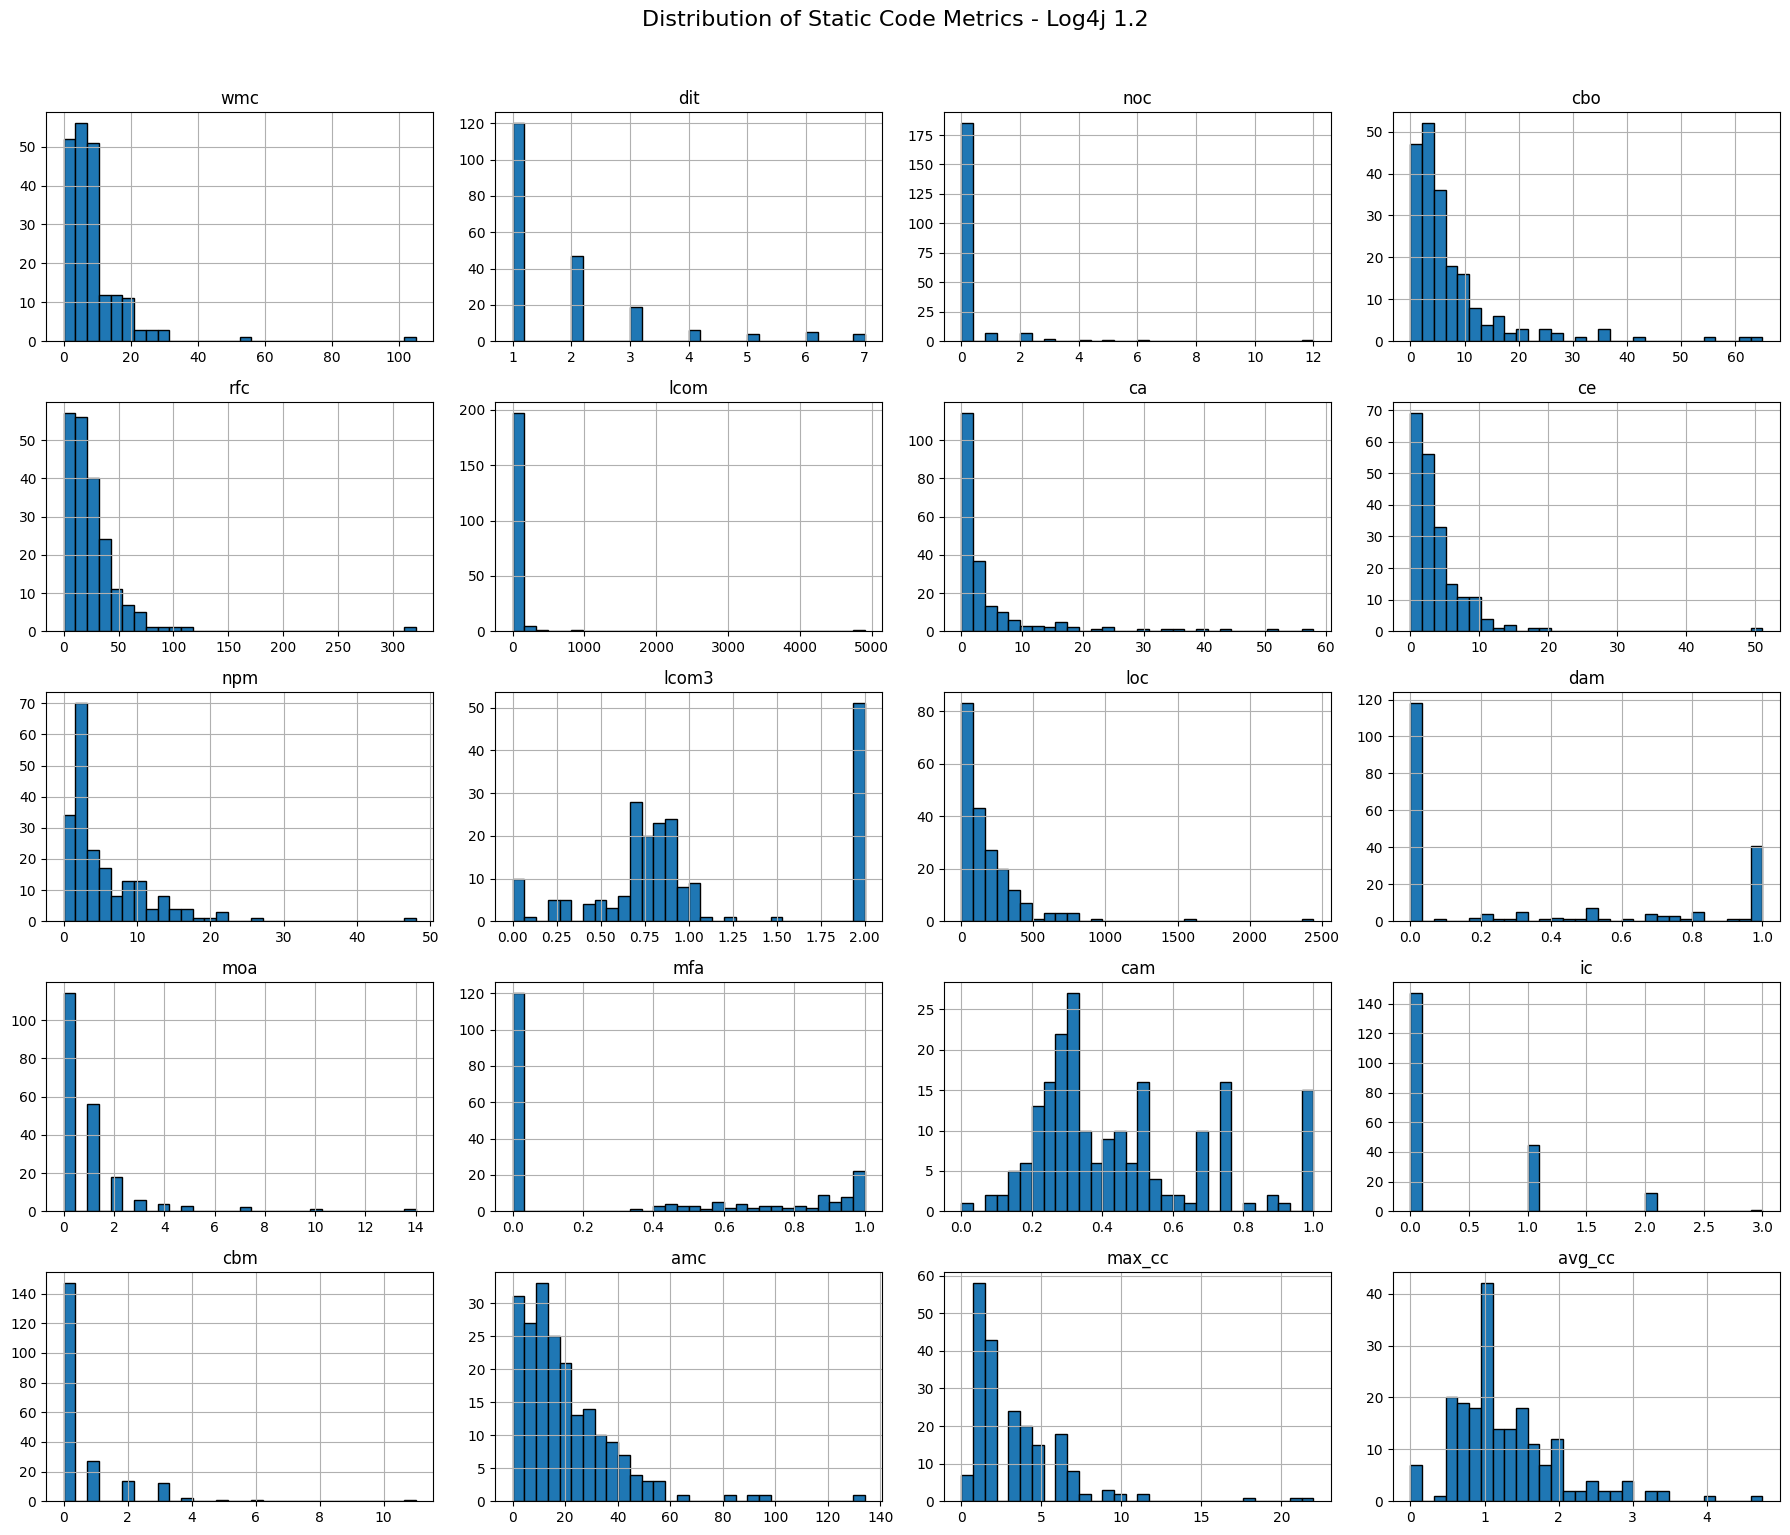

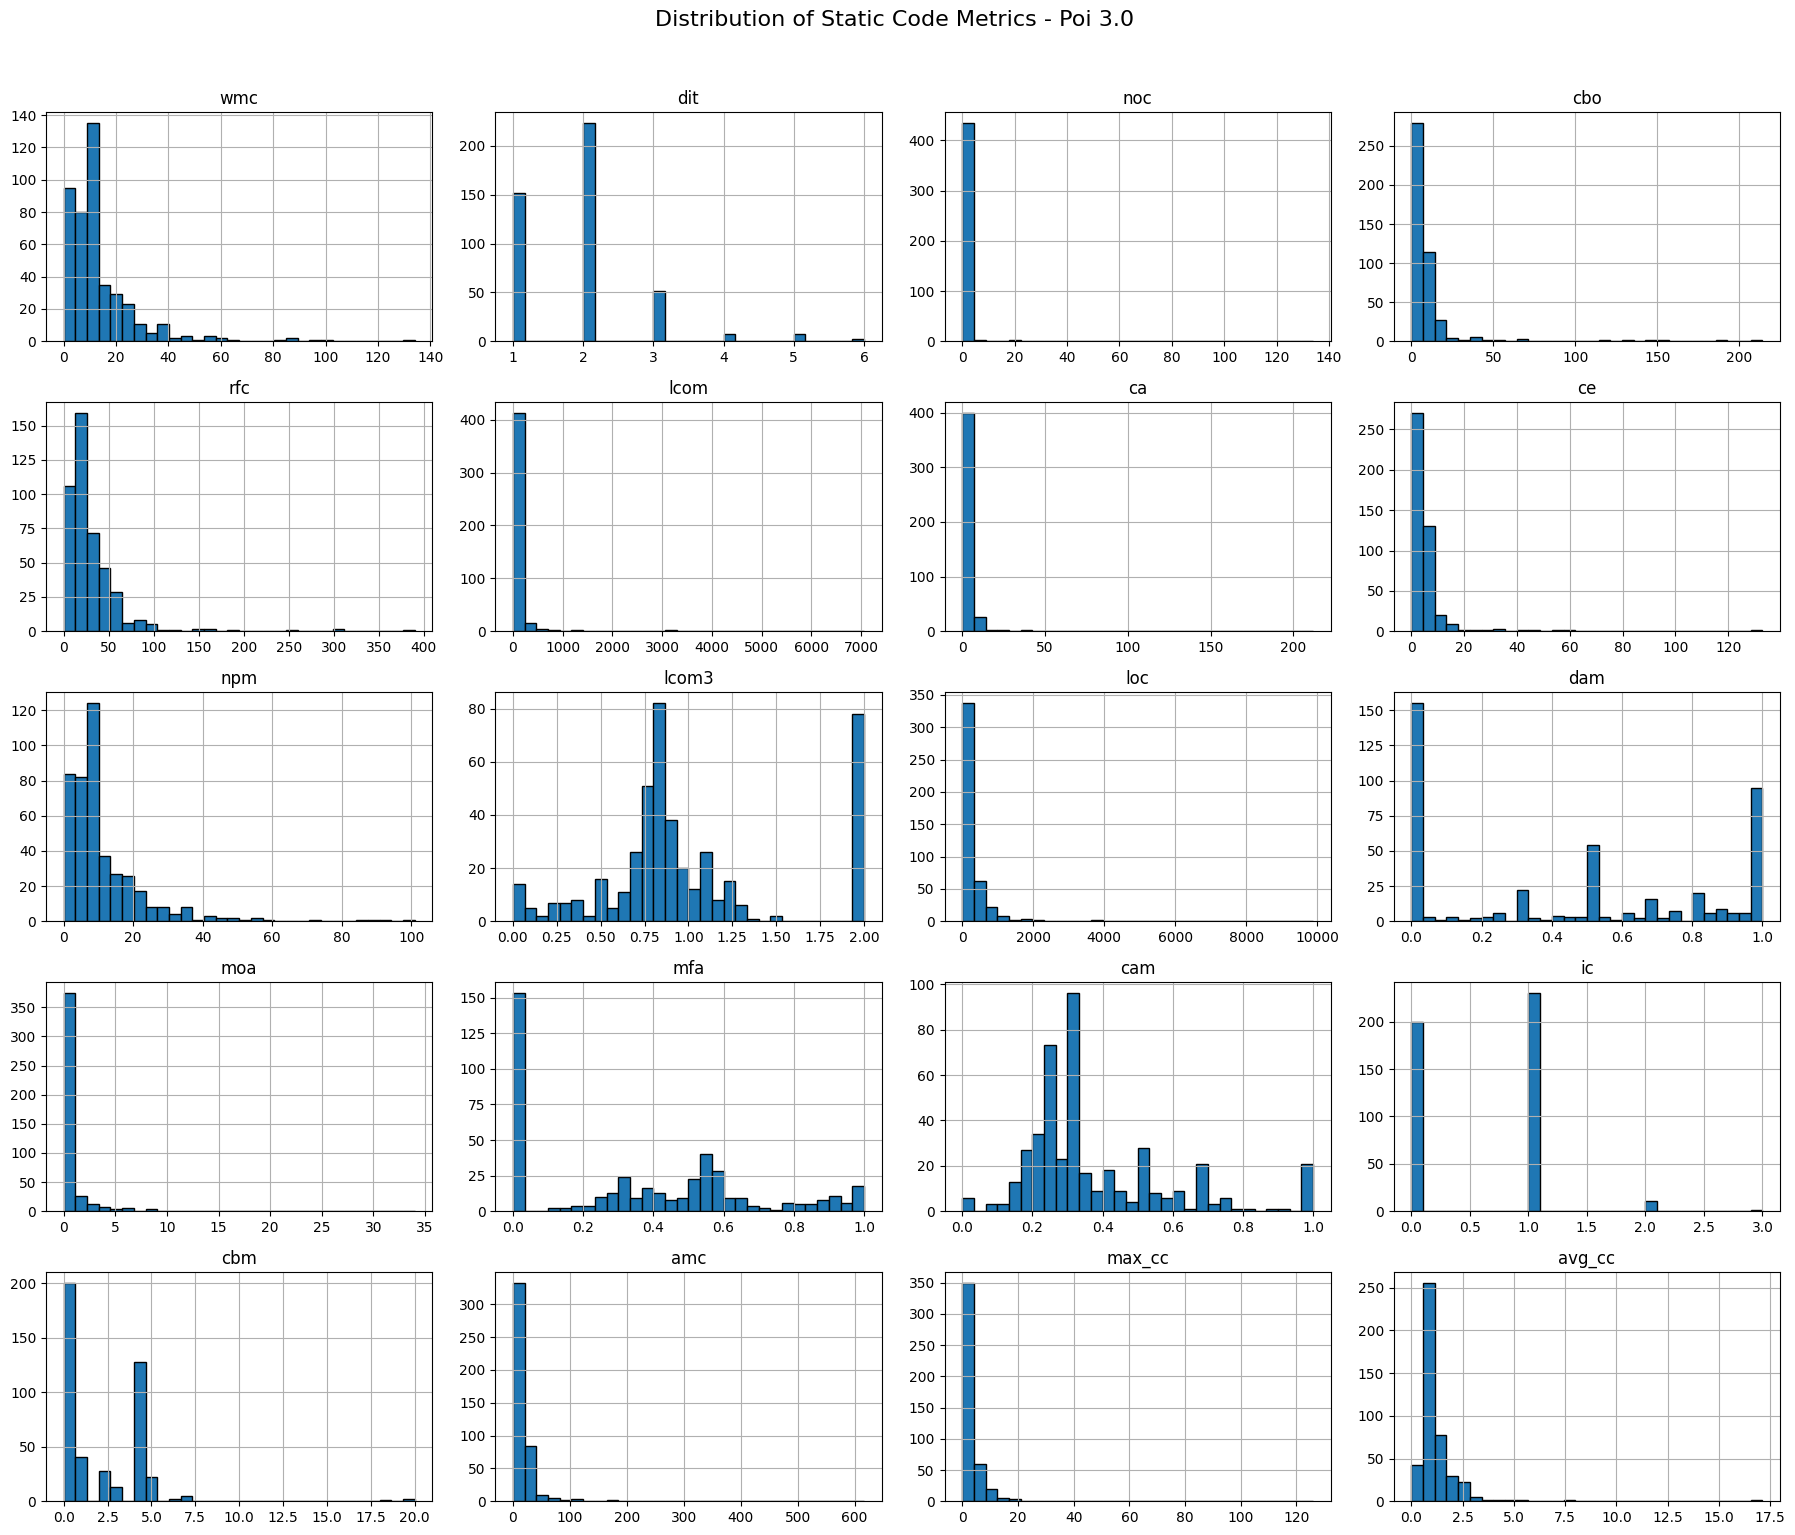

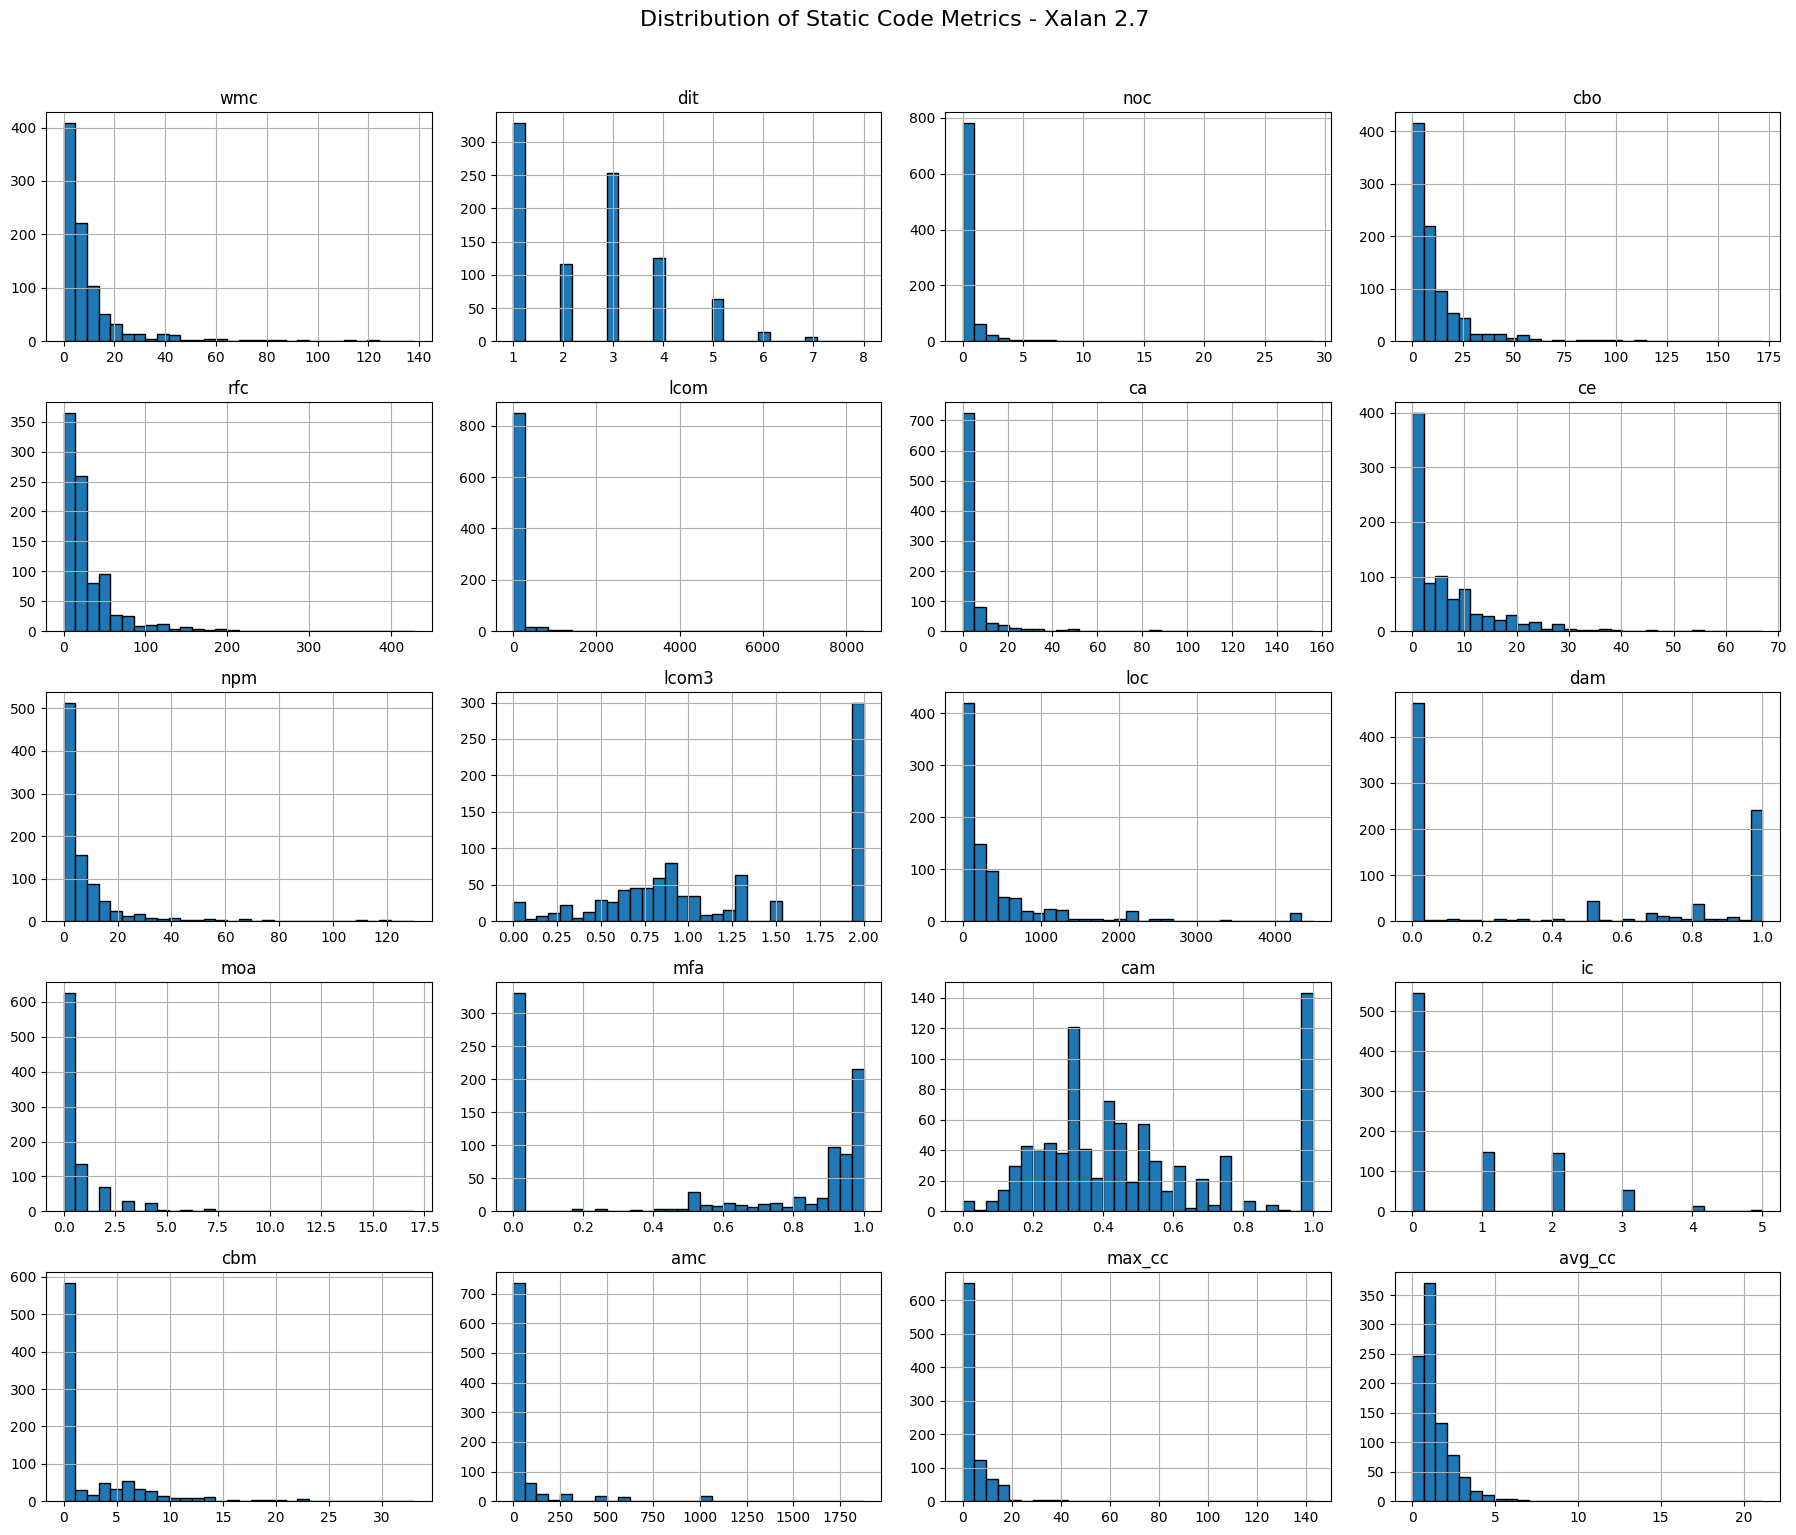

In [22]:
for name, df in datasets.items():

    df[metric_cols].hist(
        bins=30,
        figsize=(18, 15),
        edgecolor='black'
    )

    plt.suptitle(
        f'Distribution of Static Code Metrics - {name}',
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

### 4.5 Correlation Analysis

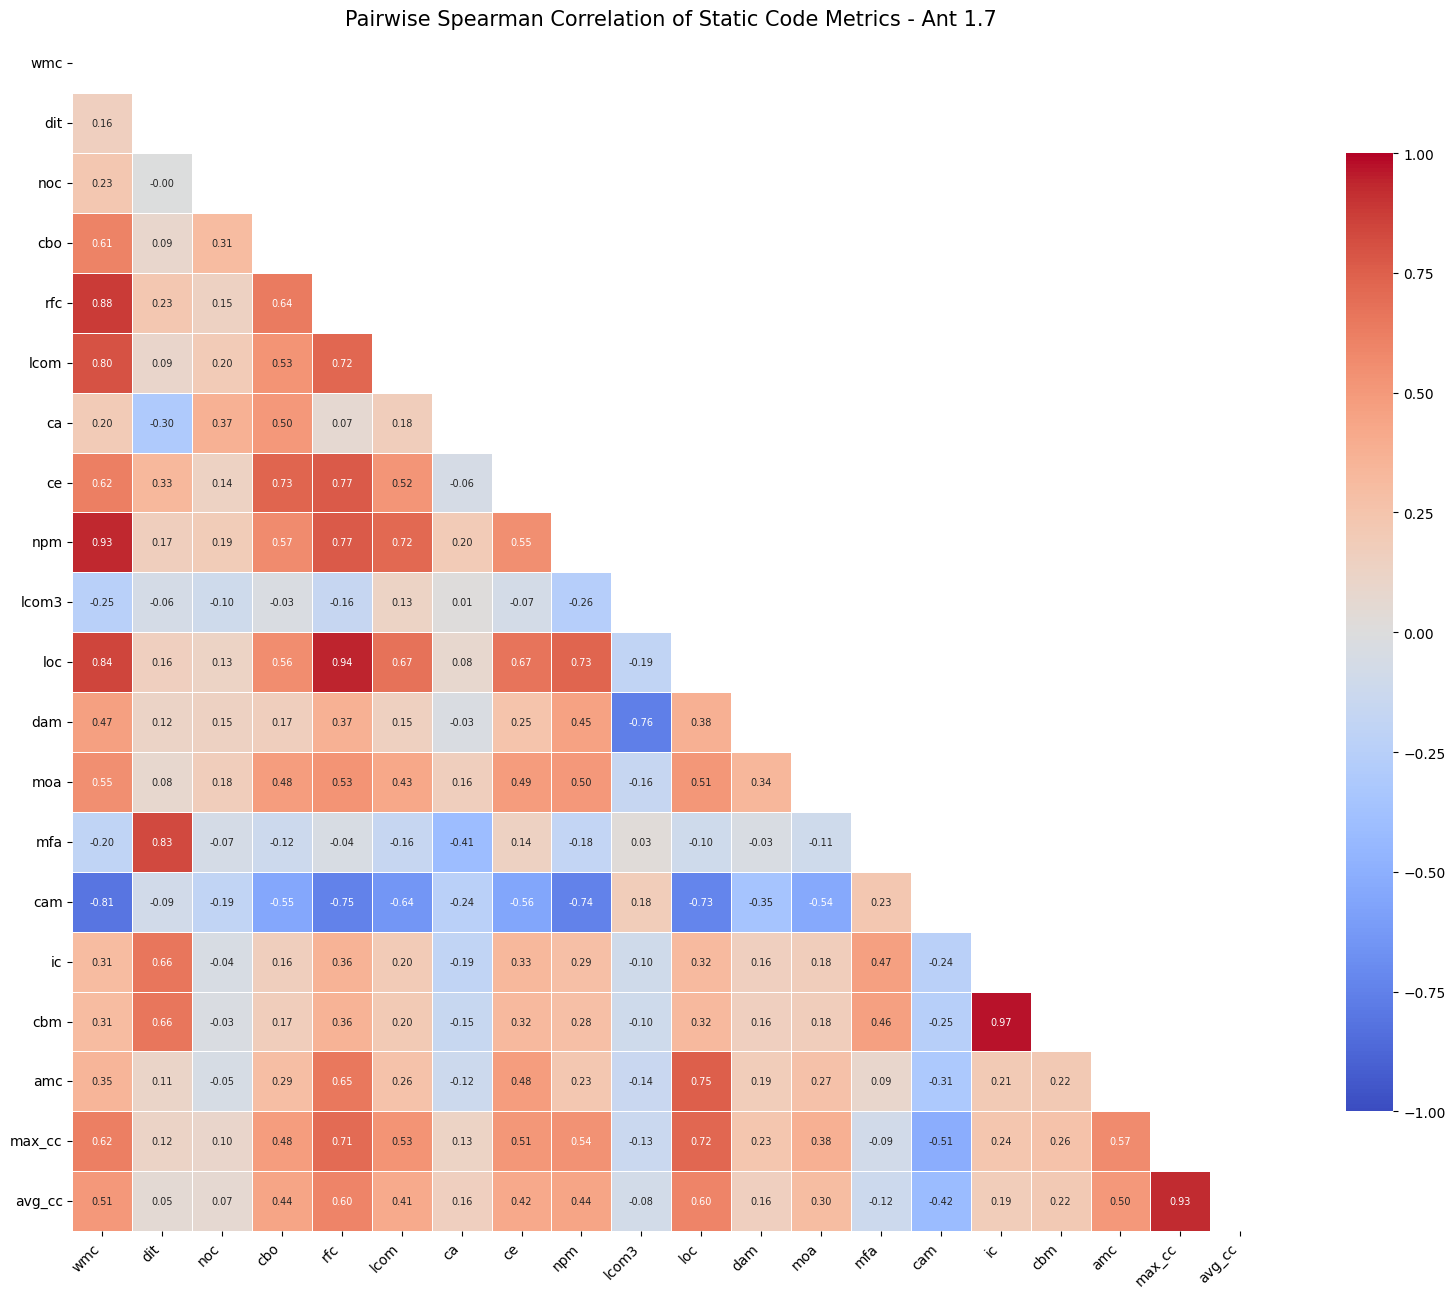

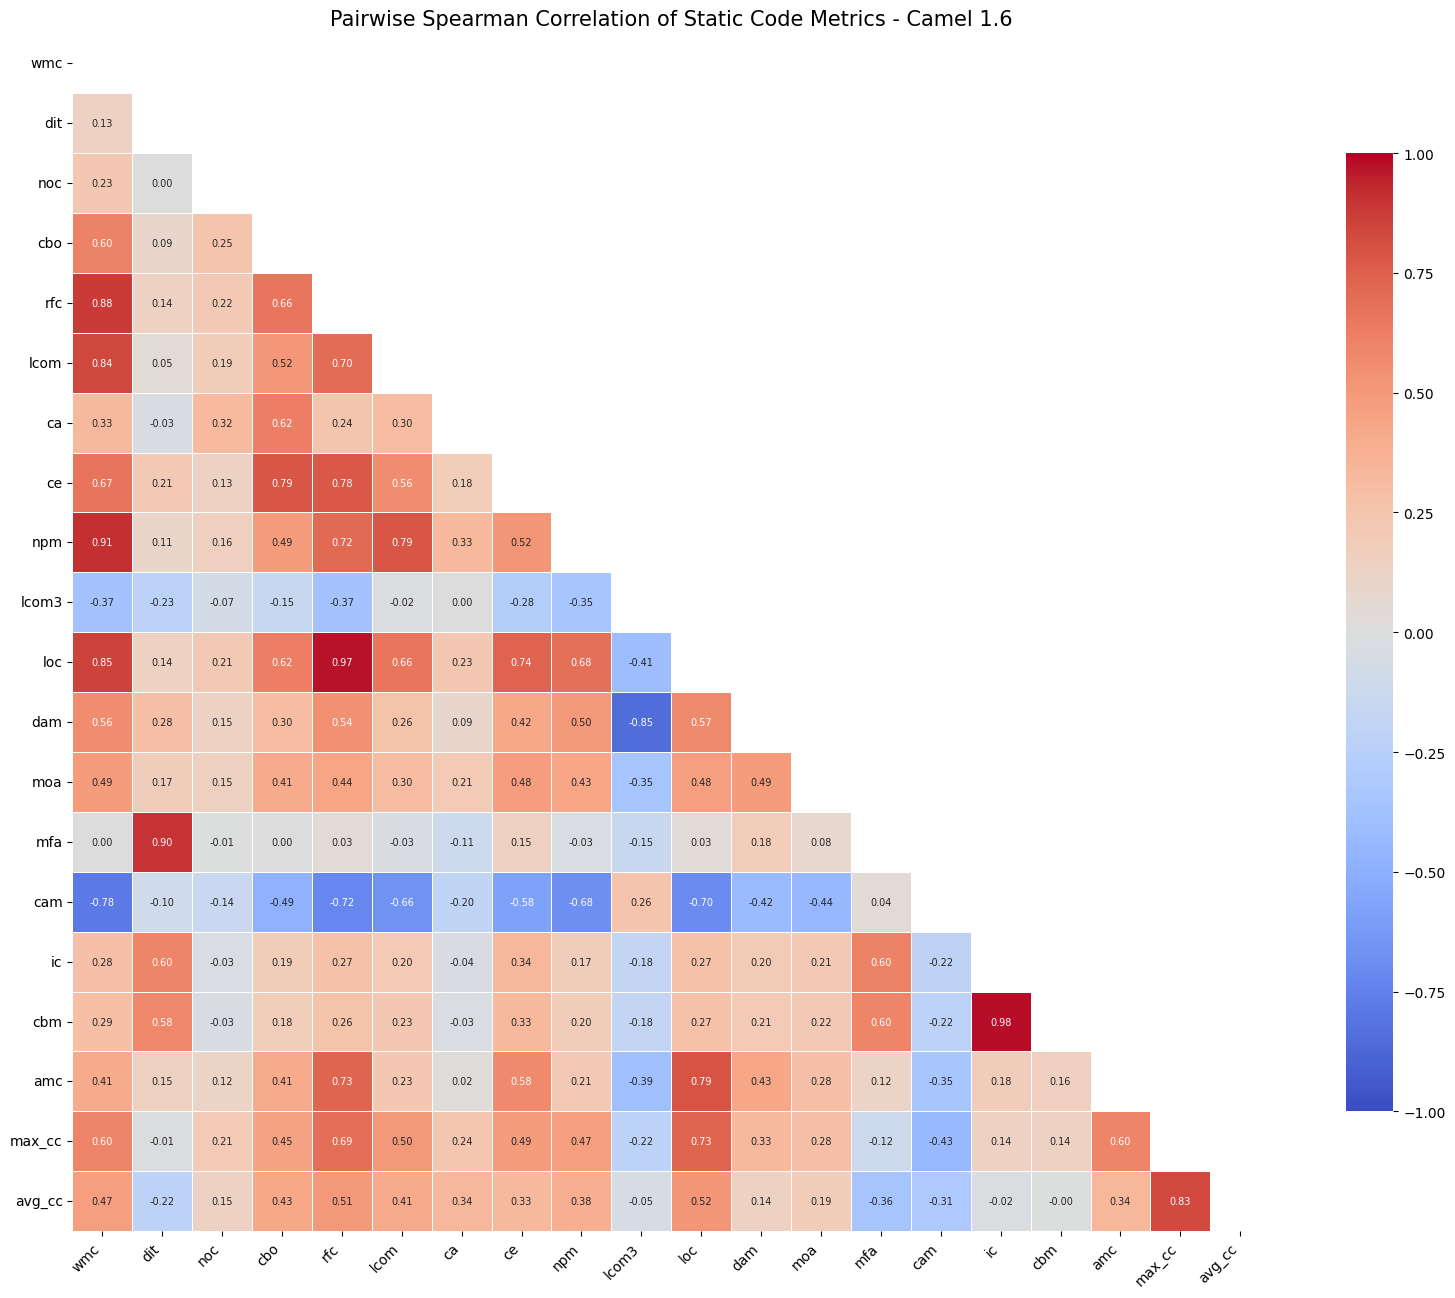

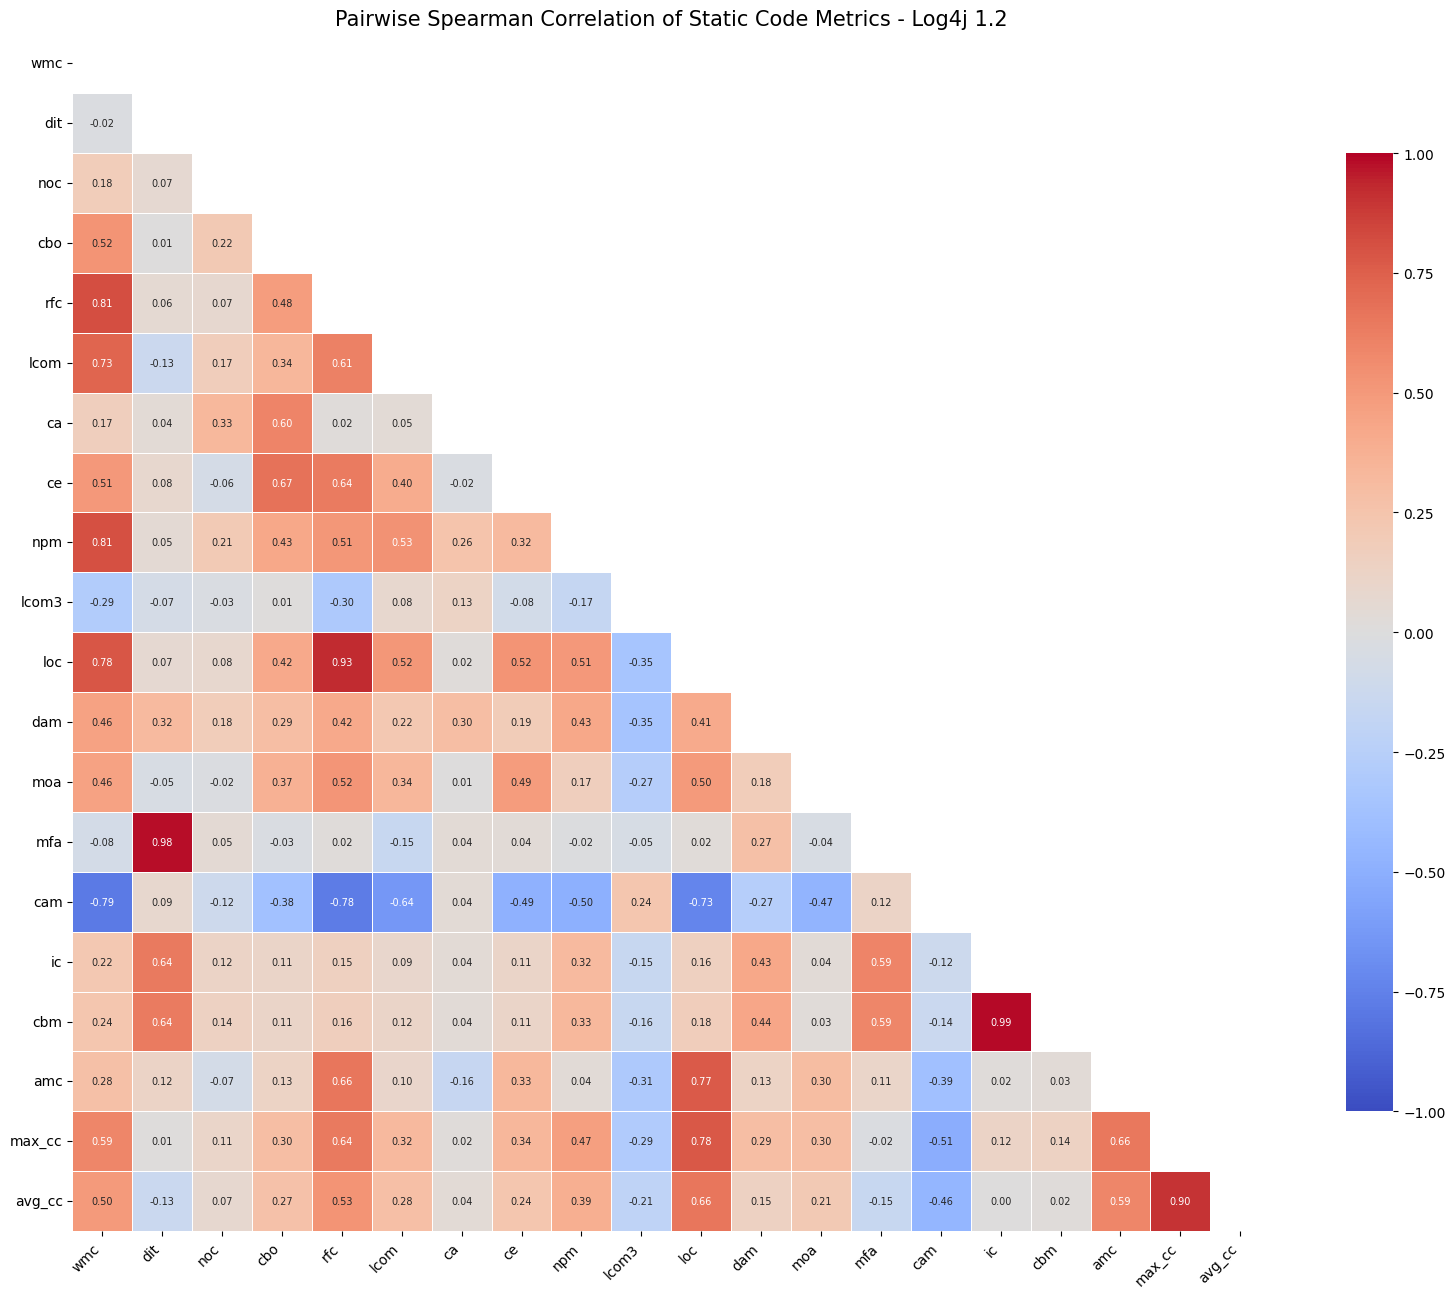

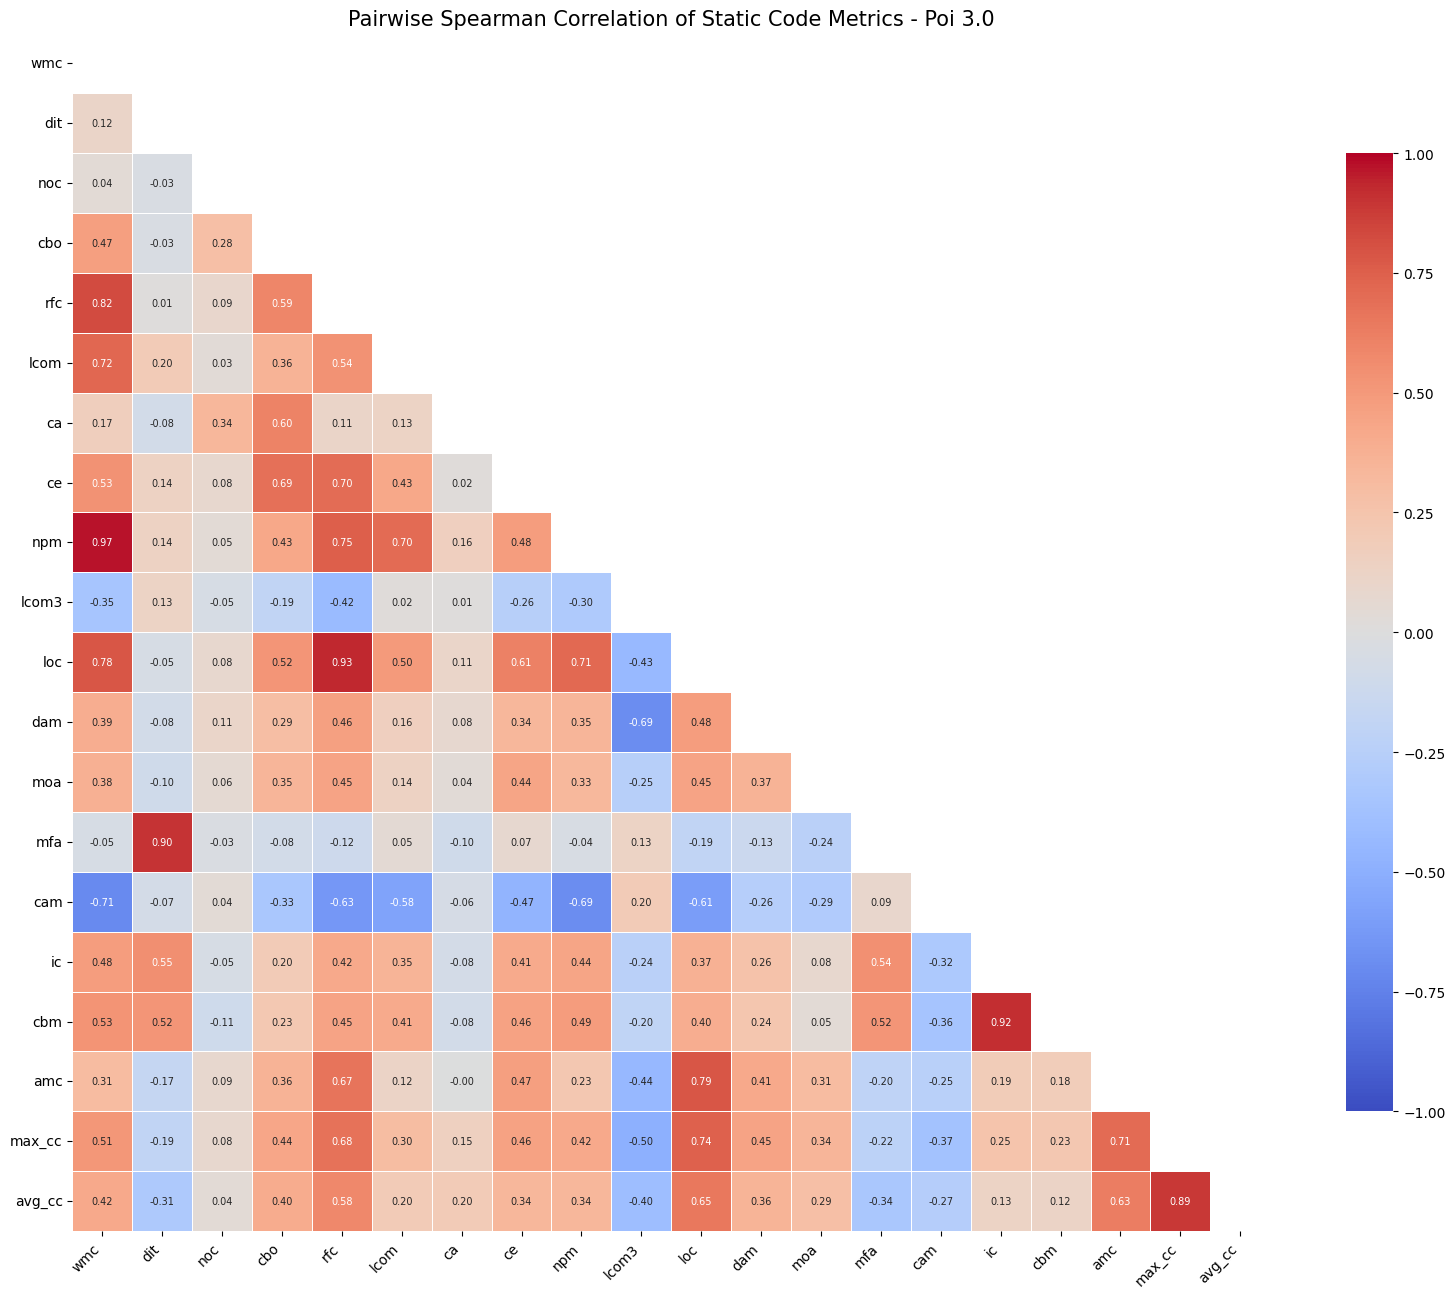

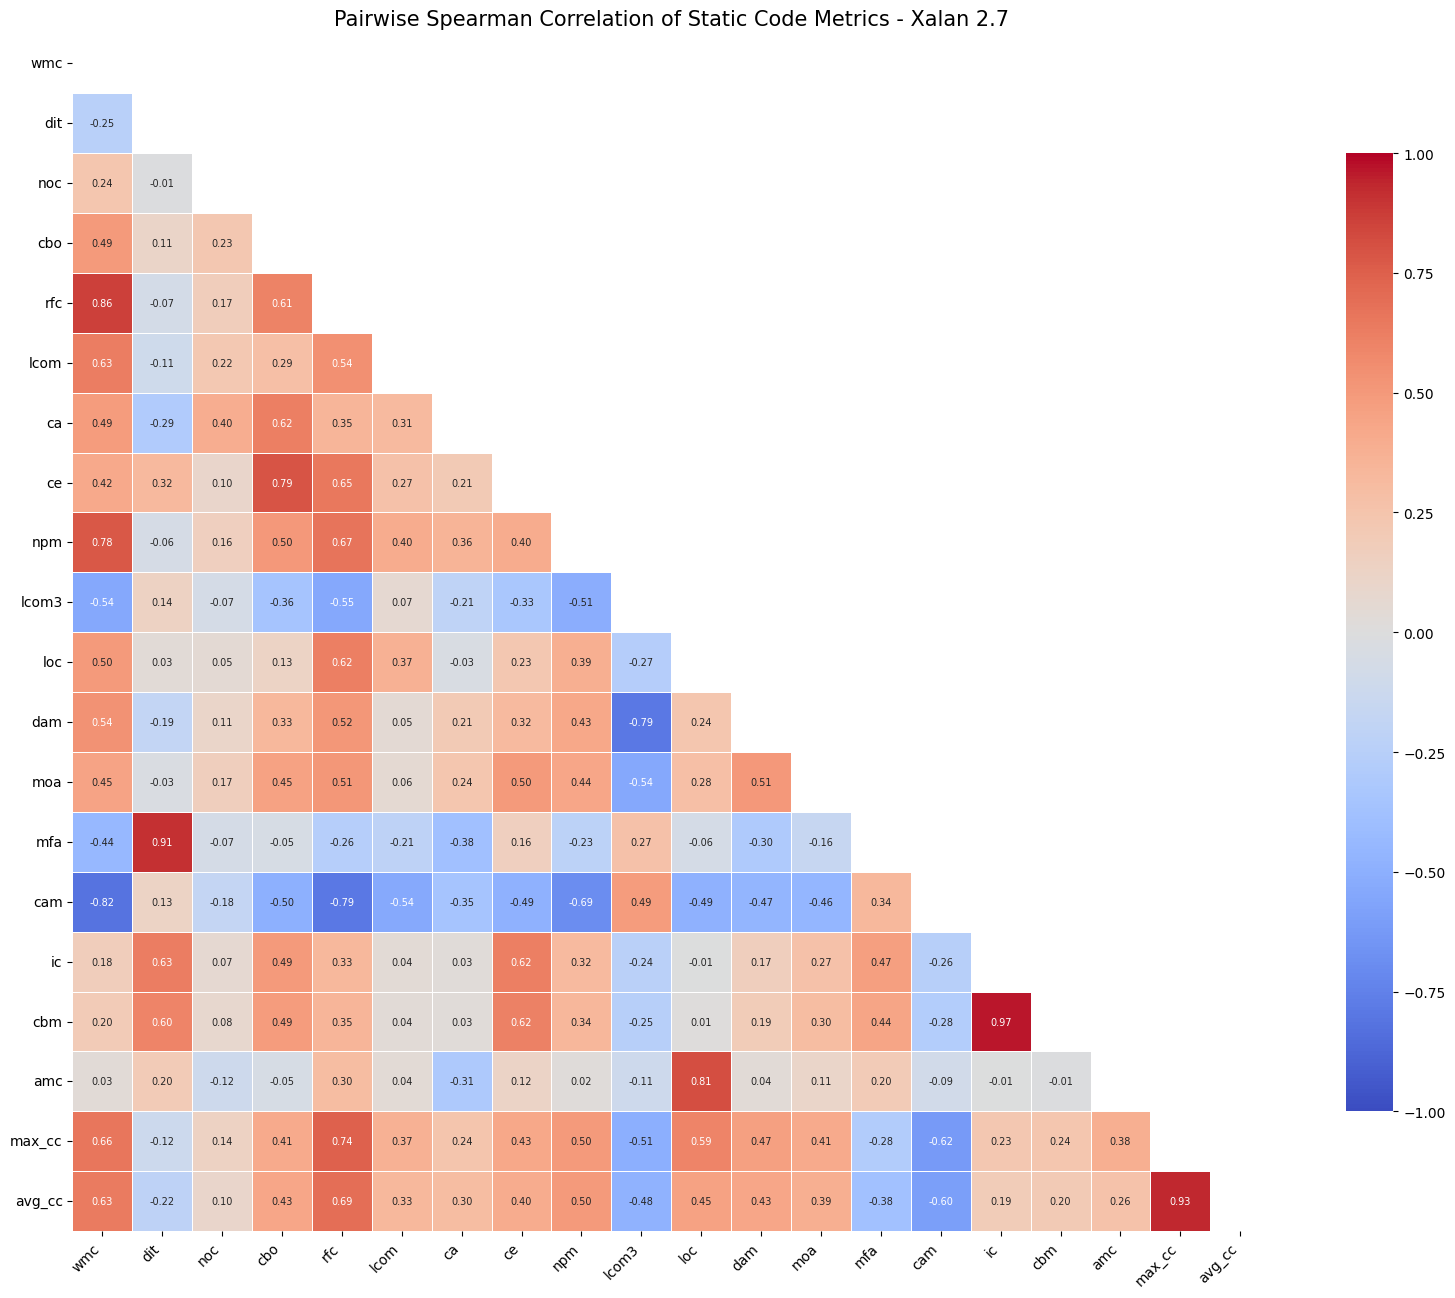

In [23]:
for name, df in datasets.items():
  corr_matrix = df[metric_cols].corr(method='spearman')

  # Create mask for upper triangle
  mask = np.triu(
      np.ones_like(corr_matrix, dtype=bool)
  )

  plt.figure(figsize=(16, 13))

  sns.heatmap(
      corr_matrix,
      mask=mask,
      annot=True,
      fmt='.2f',
      cmap='coolwarm',
      vmin=-1,
      vmax=1,
      center=0,
      square=True,
      linewidths=0.5,
      annot_kws={'size': 7},
      cbar_kws={'shrink': 0.8}
  )

  plt.title(
      f'Pairwise Spearman Correlation of Static Code Metrics - {name}',
      fontsize=15
  )

  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)

  plt.tight_layout()
  plt.show()

In [24]:
def get_high_correlations(df, features, threshold=0.90):
    corr_matrix = df[features].corr(method="spearman").abs()
    pairs = (
        corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack().sort_values(ascending=False)
    )
    return pairs[pairs >= threshold]

for name, df in datasets.items():
    high = get_high_correlations(df, metric_cols, threshold=0.90)
    print(f"\n{name} — {len(high)} feature pairs with |rho| >= 0.90")
    for (f1, f2), rho in high.items():
        print(f"    {f1:>7} - {f2:<7} {rho:.3f}")


Ant 1.7 — 4 feature pairs with |rho| >= 0.90
         ic - cbm     0.971
        rfc - loc     0.941
        wmc - npm     0.933
     max_cc - avg_cc  0.925

Camel 1.6 — 4 feature pairs with |rho| >= 0.90
         ic - cbm     0.981
        rfc - loc     0.969
        wmc - npm     0.913
        dit - mfa     0.900

Log4j 1.2 — 4 feature pairs with |rho| >= 0.90
         ic - cbm     0.987
        dit - mfa     0.981
        rfc - loc     0.926
     max_cc - avg_cc  0.905

Poi 3.0 — 3 feature pairs with |rho| >= 0.90
        wmc - npm     0.970
        rfc - loc     0.934
         ic - cbm     0.921

Xalan 2.7 — 3 feature pairs with |rho| >= 0.90
         ic - cbm     0.967
     max_cc - avg_cc  0.930
        dit - mfa     0.907


### 4.6 Defective vs Non-defective Metric Comparison

Distributions are compared between the two classes on a `log1p` scale. Note that for Xalan 2.7 (1.21% minority) and Log4j 1.2 (7.80% minority) the minority group is very small, so the corresponding boxes summarise few observations and should be read with caution.

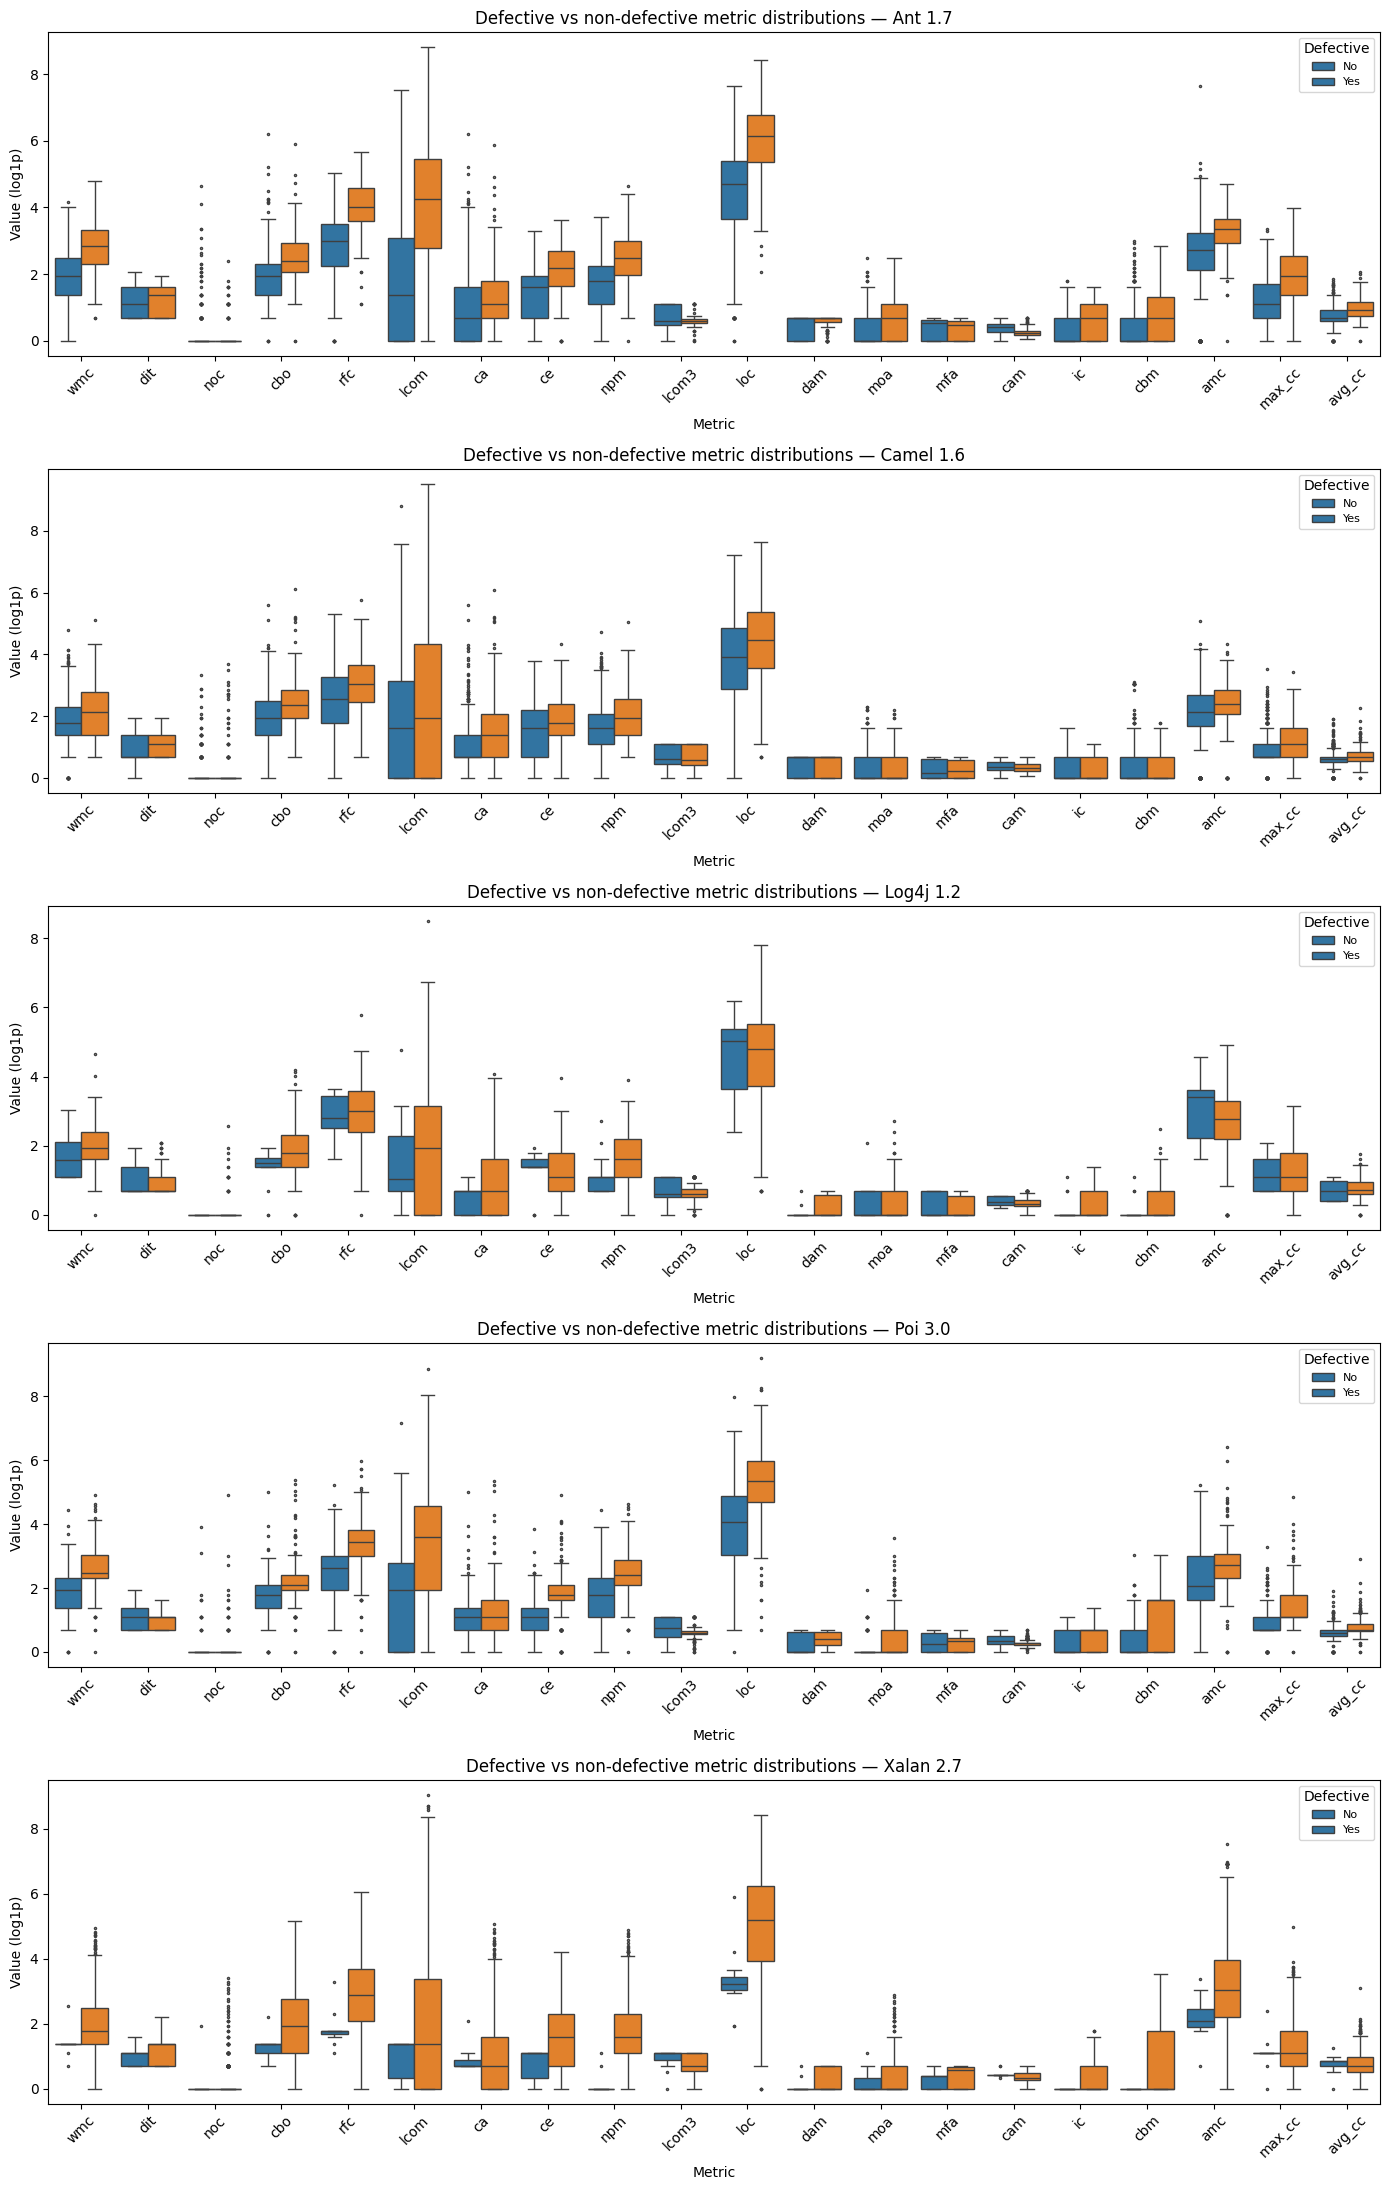

In [25]:
fig, axes = plt.subplots(5, 1, figsize=(14, 22))
for ax, (name, df) in zip(axes, datasets.items()):
    temp = df.copy()
    temp["defective"] = (temp["bug"] > 0).astype(int)
    temp[metric_cols] = np.log1p(temp[metric_cols].clip(lower=0))
    long_df = temp.melt(id_vars="defective", value_vars=metric_cols,
                        var_name="Metric", value_name="Value (log1p)")
    sns.boxplot(data=long_df, x="Metric", y="Value (log1p)",
                hue="defective", ax=ax, fliersize=1.5)
    ax.set_title(f"Defective vs non-defective metric distributions — {name}")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Defective", labels=["No", "Yes"], fontsize=8)
plt.tight_layout()
plt.show()

### 4.7 Statistical Significance Testing (Mann-Whitney U)

Because the metrics are strongly non-normal (Section 4.3), the non-parametric Mann-Whitney U test is used to test whether each metric's distribution differs between defective and non-defective classes. A Holm-Bonferroni correction is applied within each dataset to control the family-wise error rate across the 20 simultaneous tests.

In [26]:
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

def mannwhitney_table(df, metric_cols, alpha=0.05):
    defective = (df["bug"] > 0).astype(int)
    rows = []

    for m in metric_cols:
        group0 = df.loc[defective == 0, m]
        group1 = df.loc[defective == 1, m]

        try:
            u_stat, p_val = stats.mannwhitneyu(
                group0, group1, alternative="two-sided"
            )
        except ValueError:
            u_stat, p_val = np.nan, np.nan

        rows.append({
            "Metric": m,
            "U": u_stat,
            "p_value": p_val,
            "Significant (alpha=0.05)": (
                p_val < alpha if pd.notnull(p_val) else False
            ),
        })

    return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)


# Run for all five datasets
mannwhitney_results = {}

for name, df in datasets.items():
    mannwhitney_results[name] = mannwhitney_table(df, metric_cols)

    print(f"\nMANN-WHITNEY U TEST — {name}")
    display(mannwhitney_results[name].round(6))


MANN-WHITNEY U TEST — Ant 1.7


,Metric,U,p_value,Significant (alpha=0.05)
0,loc,16286.5,0.000000,True
1,rfc,16403.0,0.000000,True
2,wmc,20237.5,0.000000,True
3,lcom,21901.5,0.000000,True
4,cam,73265.5,0.000000,True
5,max_cc,24091.0,0.000000,True
6,npm,24194.5,0.000000,True
7,ce,24986.0,0.000000,True
8,amc,25694.0,0.000000,True
9,cbo,25902.5,0.000000,True



MANN-WHITNEY U TEST — Camel 1.6


,Metric,U,p_value,Significant (alpha=0.05)
0,ca,50567.5,0.000000,True
1,cbo,51334.0,0.000000,True
2,max_cc,54643.5,0.000000,True
3,rfc,53606.5,0.000000,True
4,wmc,55513.0,0.000000,True
5,loc,55485.5,0.000000,True
6,npm,56390.5,0.000001,True
7,avg_cc,57709.0,0.000007,True
8,amc,58540.0,0.000023,True
9,noc,64884.5,0.000027,True



MANN-WHITNEY U TEST — Log4j 1.2


,Metric,U,p_value,Significant (alpha=0.05)
0,npm,857.0,0.003696,True
1,dam,1012.0,0.014318,True
2,ca,988.0,0.018693,True
3,cbo,1020.0,0.030281,True
4,wmc,1089.0,0.062874,False
5,amc,1877.0,0.109579,False
6,noc,1352.0,0.173850,False
7,cam,1797.0,0.211344,False
8,cbm,1329.5,0.313648,False
9,lcom,1288.5,0.323435,False



MANN-WHITNEY U TEST — Poi 3.0


,Metric,U,p_value,Significant (alpha=0.05)
0,rfc,8867.0,0.000000,True
1,wmc,9157.5,0.000000,True
2,loc,9745.0,0.000000,True
3,ce,9912.5,0.000000,True
4,cbm,11421.0,0.000000,True
5,npm,10861.5,0.000000,True
6,max_cc,11452.5,0.000000,True
7,lcom,11464.5,0.000000,True
8,cbo,11507.0,0.000000,True
9,ic,13847.0,0.000000,True



MANN-WHITNEY U TEST — Xalan 2.7


,Metric,U,p_value,Significant (alpha=0.05)
0,npm,616.0,0.000001,True
1,loc,1946.0,0.000545,True
2,rfc,2191.5,0.001494,True
3,amc,2594.0,0.006742,True
4,ic,2937.0,0.008652,True
5,cbm,2937.0,0.009001,True
6,cbo,2700.0,0.009566,True
7,cam,7085.5,0.012936,True
8,ce,2840.0,0.014675,True
9,wmc,2867.0,0.016252,True


In [27]:
# Cross-dataset p-value matrix
pvalue_matrix = pd.DataFrame({
    name: res.set_index("Metric")["p_value"]
    for name, res in mannwhitney_results.items()
}).loc[metric_cols]

pvalue_matrix["Significant in N/5"] = (pvalue_matrix < 0.05).sum(axis=1)

display(
    pvalue_matrix
    .sort_values("Significant in N/5", ascending=False)
    .round(6)
)

,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Significant in N/5
Metric,,,,,,
cbo,0.000000,0.000000,0.030281,0.000000,0.009566,5
dam,0.000056,0.007050,0.014318,0.000000,0.049545,5
npm,0.000000,0.000001,0.003696,0.000000,0.000001,5
wmc,0.000000,0.000000,0.062874,0.000000,0.016252,4
loc,0.000000,0.000000,0.905664,0.000000,0.000545,4
ce,0.000000,0.001575,0.950596,0.000000,0.014675,4
rfc,0.000000,0.000000,0.565172,0.000000,0.001494,4
ca,0.002793,0.000000,0.018693,0.013133,0.857620,4
amc,0.000000,0.000023,0.109579,0.000000,0.006742,4


### 4.8 Effect Size (Rank-Biserial Correlation)

In [28]:
def rank_biserial_effect_size(df, metric_cols):
    defective = (df["bug"] > 0).astype(int)
    rows = []

    for m in metric_cols:
        group0 = df.loc[defective == 0, m]
        group1 = df.loc[defective == 1, m]
        n0, n1 = len(group0), len(group1)

        if n0 == 0 or n1 == 0:
            rows.append({"Metric": m, "Effect size (r)": np.nan})
            continue

        u_stat, _ = stats.mannwhitneyu(
            group0, group1, alternative="two-sided"
        )
        r = 1 - (2 * u_stat) / (n0 * n1)

        rows.append({"Metric": m, "Effect size (r)": round(r, 3)})

    return (
        pd.DataFrame(rows)
        .sort_values("Effect size (r)", key=abs, ascending=False)
        .reset_index(drop=True)
    )


def magnitude_label(r):
    a = abs(r)
    if pd.isnull(a):
        return "n/a"
    if a < 0.10:
        return "negligible"
    if a < 0.30:
        return "small"
    if a < 0.50:
        return "medium"
    return "large"


# Effect sizes for all five datasets
effect_size_results = {}

for name, df in datasets.items():
    effect_size_results[name] = rank_biserial_effect_size(df, metric_cols)


# Combine significance and effect size, per dataset
combined_sig_effect = {}

for name in datasets:
    merged = mannwhitney_results[name].merge(
        effect_size_results[name], on="Metric"
    )
    merged["Magnitude"] = merged["Effect size (r)"].apply(magnitude_label)

    combined_sig_effect[name] = (
        merged
        .sort_values("Effect size (r)", key=abs, ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nSIGNIFICANCE AND EFFECT SIZE — {name}")
    display(combined_sig_effect[name].round(6))


SIGNIFICANCE AND EFFECT SIZE — Ant 1.7


,Metric,U,p_value,Significant (alpha=0.05),Effect size (r),Magnitude
0,loc,16286.5,0.000000,True,0.661,large
1,rfc,16403.0,0.000000,True,0.659,large
2,wmc,20237.5,0.000000,True,0.579,large
3,lcom,21901.5,0.000000,True,0.544,large
4,cam,73265.5,0.000000,True,-0.525,large
5,max_cc,24091.0,0.000000,True,0.499,medium
6,npm,24194.5,0.000000,True,0.497,medium
7,ce,24986.0,0.000000,True,0.480,medium
8,amc,25694.0,0.000000,True,0.465,medium
9,cbo,25902.5,0.000000,True,0.461,medium



SIGNIFICANCE AND EFFECT SIZE — Camel 1.6


,Metric,U,p_value,Significant (alpha=0.05),Effect size (r),Magnitude
0,ca,50567.5,0.000000,True,0.308,medium
1,cbo,51334.0,0.000000,True,0.297,small
2,rfc,53606.5,0.000000,True,0.266,small
3,max_cc,54643.5,0.000000,True,0.252,small
4,wmc,55513.0,0.000000,True,0.240,small
5,loc,55485.5,0.000000,True,0.240,small
6,npm,56390.5,0.000001,True,0.228,small
7,avg_cc,57709.0,0.000007,True,0.210,small
8,amc,58540.0,0.000023,True,0.198,small
9,cam,87360.5,0.000029,True,-0.196,small



SIGNIFICANCE AND EFFECT SIZE — Log4j 1.2


,Metric,U,p_value,Significant (alpha=0.05),Effect size (r),Magnitude
0,npm,857.0,0.003696,True,0.433,medium
1,ca,988.0,0.018693,True,0.347,medium
2,dam,1012.0,0.014318,True,0.331,medium
3,cbo,1020.0,0.030281,True,0.325,medium
4,wmc,1089.0,0.062874,False,0.280,small
5,amc,1877.0,0.109579,False,-0.241,small
6,cam,1797.0,0.211344,False,-0.188,small
7,lcom,1288.5,0.323435,False,0.148,small
8,avg_cc,1296.5,0.343539,False,0.143,small
9,mfa,1699.5,0.358640,False,-0.124,small



SIGNIFICANCE AND EFFECT SIZE — Poi 3.0


,Metric,U,p_value,Significant (alpha=0.05),Effect size (r),Magnitude
0,rfc,8867.0,0.000000,True,0.608,large
1,wmc,9157.5,0.000000,True,0.595,large
2,loc,9745.0,0.000000,True,0.569,large
3,ce,9912.5,0.000000,True,0.562,large
4,npm,10861.5,0.000000,True,0.520,large
5,cbm,11421.0,0.000000,True,0.495,medium
6,max_cc,11452.5,0.000000,True,0.494,medium
7,lcom,11464.5,0.000000,True,0.493,medium
8,cbo,11507.0,0.000000,True,0.491,medium
9,cam,31934.5,0.000000,True,-0.412,medium



SIGNIFICANCE AND EFFECT SIZE — Xalan 2.7


,Metric,U,p_value,Significant (alpha=0.05),Effect size (r),Magnitude
0,npm,616.0,0.000001,True,0.875,large
1,loc,1946.0,0.000545,True,0.606,large
2,rfc,2191.5,0.001494,True,0.556,large
3,amc,2594.0,0.006742,True,0.475,medium
4,cbo,2700.0,0.009566,True,0.453,medium
5,cam,7085.5,0.012936,True,-0.435,medium
6,ce,2840.0,0.014675,True,0.425,medium
7,wmc,2867.0,0.016252,True,0.420,medium
8,ic,2937.0,0.008652,True,0.405,medium
9,cbm,2937.0,0.009001,True,0.405,medium


,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Mean |r|
Metric,,,,,,
npm,0.497,0.228,0.433,0.520,0.875,0.511
rfc,0.659,0.266,0.087,0.608,0.556,0.435
wmc,0.579,0.240,0.280,0.595,0.420,0.423
loc,0.661,0.240,-0.018,0.569,0.606,0.419
cbo,0.461,0.297,0.325,0.491,0.453,0.405
cam,-0.525,-0.196,-0.188,-0.412,-0.435,0.351
amc,0.465,0.198,-0.241,0.352,0.475,0.346
ce,0.480,0.148,-0.010,0.562,0.425,0.325
lcom,0.544,0.126,0.148,0.493,0.249,0.312


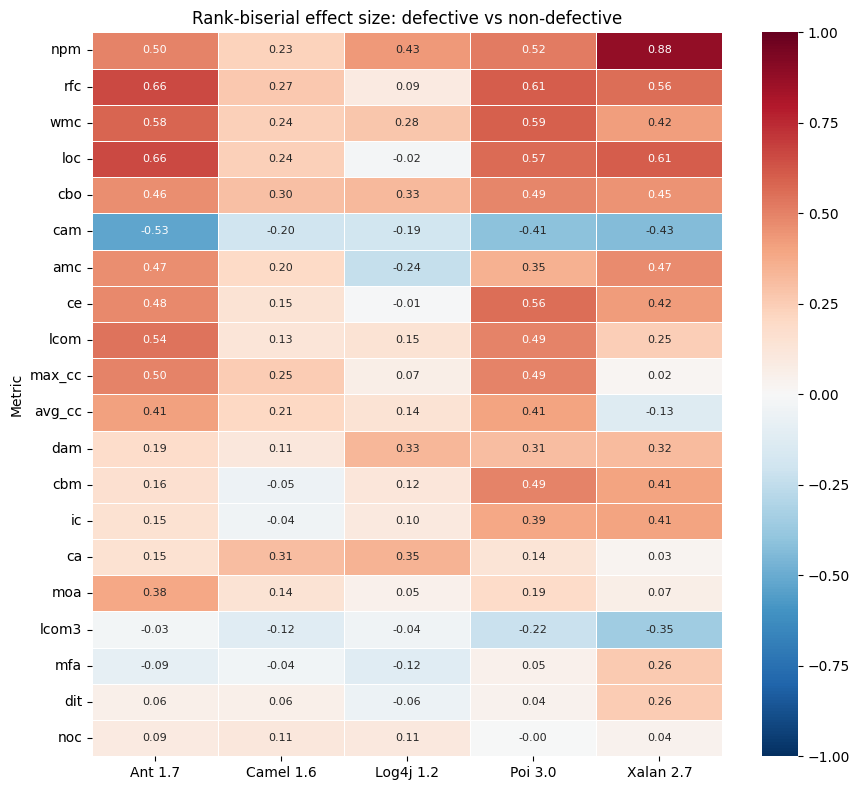

In [29]:
effect_matrix = pd.DataFrame({
    name: res.set_index("Metric")["Effect size (r)"]
    for name, res in effect_size_results.items()
}).loc[metric_cols]

effect_matrix["Mean |r|"] = effect_matrix.abs().mean(axis=1).round(3)
effect_matrix = effect_matrix.sort_values("Mean |r|", ascending=False)

display(effect_matrix)

# Heatmap — sign matters, so diverging colormap centred on zero
plt.figure(figsize=(9, 8))
sns.heatmap(
    effect_matrix.drop(columns="Mean |r|"),
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={"size": 8},
)
plt.title(
    "Rank-biserial effect size: defective vs non-defective"
)
plt.tight_layout()
plt.show()

### 4.9 Outlier Quantification

In [30]:
def outlier_percentage(df, metric_cols):
    rows = []
    for m in metric_cols:
        q1, q3 = df[m].quantile(0.25), df[m].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((df[m] < lower) | (df[m] > upper)).sum())
        rows.append({
            "Metric": m,
            "Outliers (n)": n_out,
            "Outliers (%)": round(100 * n_out / len(df), 2),
        })
    return pd.DataFrame(rows).sort_values("Outliers (%)", ascending=False)


outlier_results = {name: outlier_percentage(df, metric_cols) for name, df in datasets.items()}

outlier_matrix = pd.DataFrame({
    name: res.set_index("Metric")["Outliers (%)"]
    for name, res in outlier_results.items()
}).loc[metric_cols]

display(outlier_matrix)

,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7
Metric,,,,,
wmc,6.98,7.88,5.37,7.24,9.90
dit,0.00,0.00,9.27,3.62,0.88
noc,15.44,12.12,9.76,10.41,14.08
cbo,8.86,6.94,8.78,9.05,7.81
rfc,8.19,7.77,4.39,5.88,6.16
lcom,15.03,15.34,15.12,11.54,12.65
ca,7.52,8.91,11.22,8.82,11.66
ce,4.43,6.22,2.93,5.20,7.92
npm,7.25,7.67,3.41,6.79,10.45


## 5 Feature Selection and Engineering

### 5.1 Working Copies and Metadata Removal

In [31]:
feature_datasets = {name: df.copy() for name, df in datasets.items()}

for name, df in feature_datasets.items():
    df.drop(columns=[c for c in metadata_cols if c in df.columns], inplace=True)

print("Removed non-predictive metadata columns:", metadata_cols)
for name, df in feature_datasets.items():
    print(f"  {name:<12} -> {df.shape[1]} columns")

Removed non-predictive metadata columns: ['name', 'version', 'name.1']
  Ant 1.7      -> 21 columns
  Camel 1.6    -> 21 columns
  Log4j 1.2    -> 21 columns
  Poi 3.0      -> 21 columns
  Xalan 2.7    -> 21 columns


### 5.2 Binary Target Creation and Raw Count Removal

In [32]:
for name, df in feature_datasets.items():
    df["defective"] = (df["bug"] > 0).astype(int)
    df.drop(columns="bug", inplace=True)

target_check = pd.DataFrame([{
    "Dataset": name,
    "Shape": str(df.shape),
    "Predictors": df.shape[1] - 1,
    "Defective": int(df["defective"].sum()),
    "Non-defective": int((df["defective"] == 0).sum()),
} for name, df in feature_datasets.items()])
display(target_check)

,Dataset,Shape,Predictors,Defective,Non-defective
0,Ant 1.7,"(745, 21)",20,166,579
1,Camel 1.6,"(965, 21)",20,188,777
2,Log4j 1.2,"(205, 21)",20,189,16
3,Poi 3.0,"(442, 21)",20,281,161
4,Xalan 2.7,"(909, 21)",20,898,11


### 5.3 Mutual Information with the Target

In [33]:
def calculate_mutual_information(df, random_state=42):
    feature_cols = [c for c in df.columns if c != "defective"]
    mi = mutual_info_classif(df[feature_cols], df["defective"], random_state=random_state)
    return pd.DataFrame({"Feature": feature_cols, "MI": mi}).set_index("Feature")


mi_results = {name: calculate_mutual_information(df) for name, df in feature_datasets.items()}

mi_comparison = pd.DataFrame({name: mi["MI"] for name, mi in mi_results.items()})
mi_comparison["Mean_MI"] = mi_comparison.mean(axis=1)
mi_comparison = mi_comparison.sort_values("Mean_MI", ascending=False)
display(mi_comparison.round(4))

,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Mean_MI
Feature,,,,,,
rfc,0.1334,0.0593,0.0188,0.1800,0.0236,0.0830
loc,0.1404,0.0124,0.0310,0.1757,0.0257,0.0770
cam,0.0894,0.0206,0.0328,0.1986,0.0233,0.0729
lcom,0.0976,0.0140,0.0175,0.1876,0.0137,0.0661
amc,0.0806,0.0376,0.0323,0.1540,0.0192,0.0647
ce,0.0635,0.0000,0.0346,0.1936,0.0121,0.0608
lcom3,0.0925,0.0000,0.0000,0.1846,0.0084,0.0571
mfa,0.0044,0.0178,0.0430,0.1931,0.0218,0.0560
avg_cc,0.0561,0.0209,0.0283,0.1549,0.0145,0.0549


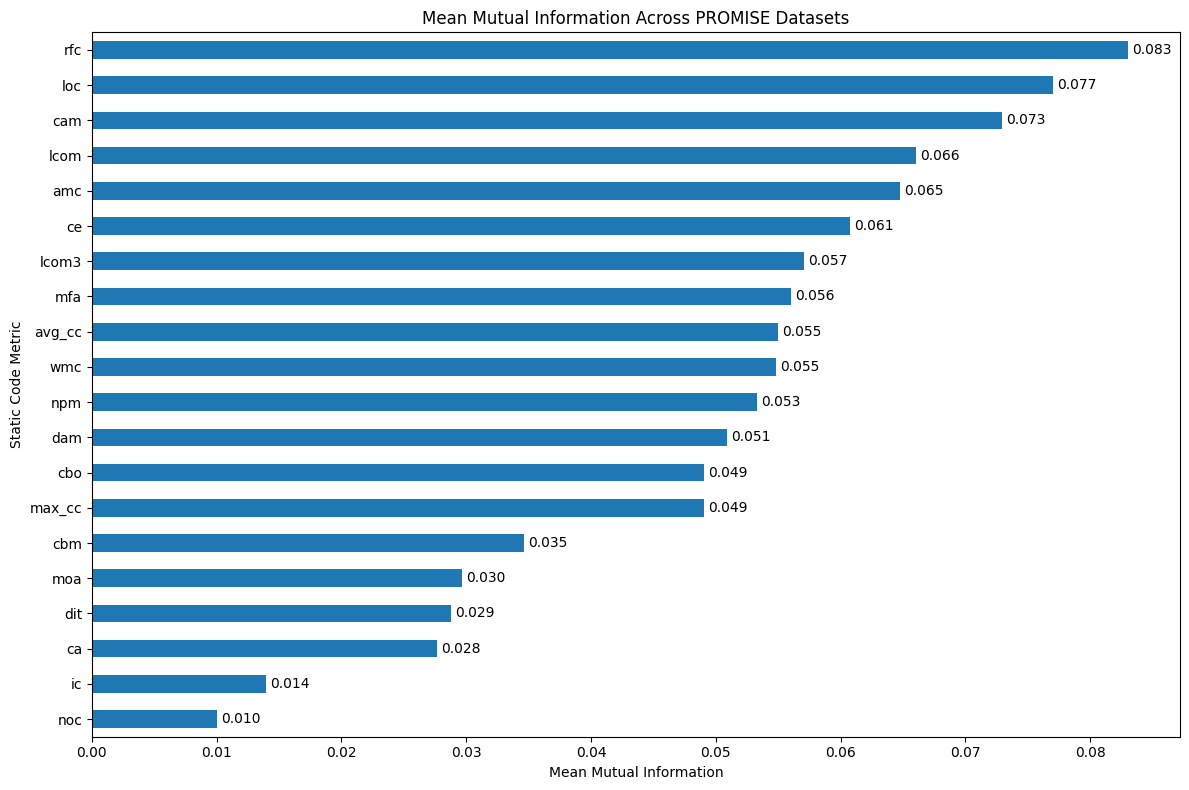

In [34]:
# MEAN MUTUAL INFORMATION
plt.figure(figsize=(12, 8))

ax = (
    mi_comparison['Mean_MI']
    .sort_values()
    .plot(kind='barh')
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.3f')

plt.title('Mean Mutual Information Across PROMISE Datasets')
plt.xlabel('Mean Mutual Information')
plt.ylabel('Static Code Metric')
plt.tight_layout()
plt.show()

### 5.4 Correlation-Based Redundancy Screening


Feature pairs with `|Spearman rho| >= 0.90` are treated as redundant. The 0.90 threshold is deliberately conservative: it removes only near-duplicate measurements while preserving moderately correlated metrics that may still carry complementary information for the explanation analyses in RQ2-RQ3.

In [35]:
def get_high_correlation_pairs(df, threshold=0.90):
    feature_cols = [c for c in df.columns if c != "defective"]
    corr_matrix = df[feature_cols].corr(method="spearman").abs()
    pairs = (
        corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack().reset_index()
    )
    pairs.columns = ["Feature_1", "Feature_2", "abs_rho"]
    return pairs[pairs["abs_rho"] >= threshold].sort_values("abs_rho", ascending=False)


high_corr_results = {
    name: get_high_correlation_pairs(df, threshold=0.90)
    for name, df in feature_datasets.items()
}

for name, pairs in high_corr_results.items():
    print(f"\n{name} — {len(pairs)} pairs with |rho| >= 0.90")
    if len(pairs):
        print(pairs.round(3).to_string(index=False))


Ant 1.7 — 4 pairs with |rho| >= 0.90
Feature_1 Feature_2  abs_rho
       ic       cbm    0.971
      rfc       loc    0.941
      wmc       npm    0.933
   max_cc    avg_cc    0.925

Camel 1.6 — 4 pairs with |rho| >= 0.90
Feature_1 Feature_2  abs_rho
       ic       cbm    0.981
      rfc       loc    0.969
      wmc       npm    0.913
      dit       mfa    0.900

Log4j 1.2 — 4 pairs with |rho| >= 0.90
Feature_1 Feature_2  abs_rho
       ic       cbm    0.987
      dit       mfa    0.981
      rfc       loc    0.926
   max_cc    avg_cc    0.905

Poi 3.0 — 3 pairs with |rho| >= 0.90
Feature_1 Feature_2  abs_rho
      wmc       npm    0.970
      rfc       loc    0.934
       ic       cbm    0.921

Xalan 2.7 — 3 pairs with |rho| >= 0.90
Feature_1 Feature_2  abs_rho
       ic       cbm    0.967
   max_cc    avg_cc    0.930
      dit       mfa    0.907


In [36]:
# CORRELATED PAIRS ACROSS DATASETS
pair_occurrence = {}

for name, corr_df in high_corr_results.items():

    if corr_df.empty:
        continue

    for _, row in corr_df.iterrows():

        pair = tuple(
            sorted([
                row['Feature_1'],
                row['Feature_2']
            ])
        )

        if pair not in pair_occurrence:

            pair_occurrence[pair] = 0

        pair_occurrence[pair] += 1

In [37]:
# CORRELATED PAIRS ACROSS DATASETS - DECISION TABLE
# Occurrence count, the full per-project correlation profile, and
# the mean MI of each member, so every criterion needed for the
# decision sits in a single table.

mean_mi_lookup = (
    mi_comparison['Mean_MI']
    .to_dict()
)

occurrence_rows = []

for pair, count in pair_occurrence.items():

    f1, f2 = pair

    row = {
        'Feature_1': f1,
        'Feature_2': f2,
        'Datasets_with_|rho|>=0.90': count
    }

    rhos = []

    for name, df in feature_datasets.items():

        rho = abs(
            df[[f1, f2]]
            .corr(method='spearman')
            .iloc[0, 1]
        )

        row[name] = round(rho, 3)

        rhos.append(rho)

    row['Mean_rho'] = round(np.mean(rhos), 3)
    row['Min_rho'] = round(min(rhos), 3)

    mi_1 = mean_mi_lookup.get(f1, 0)
    mi_2 = mean_mi_lookup.get(f2, 0)

    row['Mean_MI_F1'] = round(mi_1, 4)
    row['Mean_MI_F2'] = round(mi_2, 4)
    row['MI_margin'] = round(abs(mi_1 - mi_2), 4)

    row['Recommended_Keep'] = (
        f1 if mi_1 >= mi_2 else f2
    )

    row['Recommended_Drop'] = (
        f2 if mi_1 >= mi_2 else f1
    )

    occurrence_rows.append(row)


pair_occurrence_df = (
    pd.DataFrame(occurrence_rows)
    .sort_values(
        ['Datasets_with_|rho|>=0.90', 'Mean_rho'],
        ascending=False
    )
    .reset_index(drop=True)
)

pair_occurrence_df


,Feature_1,Feature_2,Datasets_with_|rho|>=0.90,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Mean_rho,Min_rho,Mean_MI_F1,Mean_MI_F2,MI_margin,Recommended_Keep,Recommended_Drop
0,cbm,ic,5,0.971,0.981,0.987,0.921,0.967,0.965,0.921,0.0346,0.0140,0.0207,cbm,ic
1,loc,rfc,4,0.941,0.969,0.926,0.934,0.621,0.878,0.621,0.0770,0.0830,0.0060,rfc,loc
2,dit,mfa,3,0.834,0.900,0.981,0.899,0.907,0.904,0.834,0.0288,0.0560,0.0272,mfa,dit
3,avg_cc,max_cc,3,0.925,0.830,0.905,0.891,0.930,0.896,0.830,0.0549,0.0490,0.0059,avg_cc,max_cc
4,npm,wmc,3,0.933,0.913,0.806,0.970,0.779,0.880,0.779,0.0533,0.0549,0.0016,wmc,npm


In [38]:
# FINAL REDUNDANT FEATURES TO REMOVE
#
# One decision per flagged pair, applied to all five projects so
# that the resulting feature space is identical across datasets.
#
# DECISION CRITERION
# Relevance evidence (effect size, significance frequency) converges
# mechanically as correlation rises: across all 190 metric pairs, the
# mean absolute effect-size difference falls from 0.163 at rho < 0.3
# to 0.023 at rho >= 0.9. "Their evidence is comparable" is therefore
# a symptom of redundancy, not grounds for retaining both.
#
# A pair is retained only where its members diverge MORE than their
# correlation would predict. On that test npm-wmc is the sole
# exception among the five flagged pairs.

redundant_features_to_remove = [

    # cbm - ic  |  5/5 projects  |  mean rho 0.965  |  MI margin 0.016
    # |effect diff| = 0.029. The only pair flagged in every project.
    # cbm has both higher MI and a larger effect size, so all
    # criteria agree.
    'ic',

    # dit - mfa |  3/5 projects  |  mean rho 0.904  |  MI margin 0.032
    # |effect diff| = 0.017. dit is the weakest metric in the set:
    # MI 0.027, effect size 0.096, significant in 0/5 projects. It
    # also carries the dit = 0 extraction artefact found in Camel 1.6.
    'dit',

    # loc - rfc |  4/5 projects  |  mean rho 0.878  | MI margin 0.0005
    # |effect diff| = 0.016. MI cannot separate these (margin far
    # below the seed-to-seed SD), so the tie is broken on
    # interpretability: "this class is 2,000 lines" is directly
    # actionable in a SHAP or LIME explanation, whereas "rfc = 180"
    # is not. loc is also the canonical size baseline in the SDP
    # literature.
    'rfc',

    # avg_cc - max_cc | 3/5 projects | mean rho 0.896 | margin 0.001
    # |effect diff| = 0.009 - the SMALLEST divergence of any flagged
    # pair, i.e. the closest thing to a true duplicate in the set.
    # Every relevance signal is tied (effect 0.258 vs 0.267,
    # significant 3/5 vs 3/5), which is the signature of duplication
    # rather than of two complementary constructs. Retaining both
    # would split SHAP attribution between them, pushing cyclomatic
    # complexity down the RQ2 ranking as an artefact of the feature
    # set rather than a property of the data.
    'max_cc'
]

# ------------------------------------------------------------------
# RETAINED DESPITE REDUNDANCY
#
# npm - wmc |  3/5 projects  |  mean rho 0.880  |  MI margin 0.009
# |effect diff| = 0.088 - three to five times larger than any other
# flagged pair despite comparable correlation, so npm carries signal
# that wmc does not. It is also the weakest redundancy case in the
# set: rho falls to 0.779 in Xalan 2.7 and only 3/5 projects cross
# the threshold. npm additionally has the largest mean absolute
# effect size in the study (0.511) and is the only metric significant
# in all five projects. Both are therefore retained.
# ------------------------------------------------------------------

print(
    f"Features selected for removal "
    f"({len(redundant_features_to_remove)}):"
)

for feature in redundant_features_to_remove:
    print(f"  - {feature}")

print("\nRetained despite partial redundancy:")
print("  - npm, wmc (effect-size divergence exceeds correlation prediction)")

print(
    f"\nExpected remaining predictors: "
    f"{len(metric_cols) - len(redundant_features_to_remove)}"
)

Features selected for removal (4):
  - ic
  - dit
  - rfc
  - max_cc

Retained despite partial redundancy:
  - npm, wmc (effect-size divergence exceeds correlation prediction)

Expected remaining predictors: 16


In [39]:
# REMOVE FINAL REDUNDANT FEATURES
selected_datasets = {}

for name, df in feature_datasets.items():

    temp = df.copy()

    cols_to_drop = [
        col
        for col in redundant_features_to_remove
        if col in temp.columns
    ]

    temp.drop(
        columns=cols_to_drop,
        inplace=True
    )

    selected_datasets[name] = temp

    print(
        f"{name}: "
        f"{temp.shape[1] - 1} predictors remaining"
    )

Ant 1.7: 16 predictors remaining
Camel 1.6: 16 predictors remaining
Log4j 1.2: 16 predictors remaining
Poi 3.0: 16 predictors remaining
Xalan 2.7: 16 predictors remaining


In [40]:
# VERIFY COMMON FEATURE SPACE
feature_sets = {}

for name, df in selected_datasets.items():

    feature_sets[name] = set(
        df.columns
    ) - {
        'defective'
    }

    print(
        f"{name}: {len(feature_sets[name])} features"
    )

identical = (
    len({
        frozenset(fs)
        for fs in feature_sets.values()
    }) == 1
)

print(
    f"\nIdentical feature space "
    f"across all five projects: {identical}"
)

assert identical, (
    "Feature spaces differ - RQ2 cross-project comparison "
    "requires a common feature set."
)


Ant 1.7: 16 features
Camel 1.6: 16 features
Log4j 1.2: 16 features
Poi 3.0: 16 features
Xalan 2.7: 16 features

Identical feature space across all five projects: True


In [41]:
# FINAL SELECTED FEATURES

final_feature_cols = [
    col
    for col
    in next(
        iter(
            selected_datasets.values()
        )
    ).columns
    if col != 'defective'
]

print(
    f"Final number of features: "
    f"{len(final_feature_cols)}"
)

print("\nFinal selected features:")

for feature in final_feature_cols:

    print(feature)

Final number of features: 16

Final selected features:
wmc
noc
cbo
lcom
ca
ce
npm
lcom3
loc
dam
moa
mfa
cam
cbm
amc
avg_cc


### 5.6 Final Modelling-Ready Datasets

In [42]:
# BUILD FINAL DATASETS (common feature space)
final_feature_cols = [
    col for col in metric_cols
    if col not in redundant_features_to_remove
]

final_datasets = {
    name: df[final_feature_cols + ["defective"]].copy()
    for name, df in feature_datasets.items()
}

for name, df in final_datasets.items():
    print(f"{name:<12} shape={df.shape}  predictors={df.shape[1] - 1}")

print(f"\nCommon feature set ({len(final_feature_cols)}):")
print(final_feature_cols)

Ant 1.7      shape=(745, 17)  predictors=16
Camel 1.6    shape=(965, 17)  predictors=16
Log4j 1.2    shape=(205, 17)  predictors=16
Poi 3.0      shape=(442, 17)  predictors=16
Xalan 2.7    shape=(909, 17)  predictors=16

Common feature set (16):
['wmc', 'noc', 'cbo', 'lcom', 'ca', 'ce', 'npm', 'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'cbm', 'amc', 'avg_cc']


### 5.7 Save Feature-Selected Datasets

In [43]:
import os

OUTPUT_PATH = (
    "/content/drive/MyDrive/"
    "Software_Defect_Prediction/"
    "feature_selected_data/"
)

os.makedirs(
    OUTPUT_PATH,
    exist_ok=True
)

In [44]:
for name, df in selected_datasets.items():

    filename = (
        name
        .lower()
        .replace(' ', '_')
        .replace('.', '_')
    )

    filepath = (
        OUTPUT_PATH
        + filename
        + "_feature_selected.csv"
    )

    df.to_csv(
        filepath,
        index=False
    )

    print(
        f"Saved: {filepath}"
    )

Saved: /content/drive/MyDrive/Software_Defect_Prediction/feature_selected_data/ant_1_7_feature_selected.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/feature_selected_data/camel_1_6_feature_selected.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/feature_selected_data/log4j_1_2_feature_selected.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/feature_selected_data/poi_3_0_feature_selected.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/feature_selected_data/xalan_2_7_feature_selected.csv


## 6. Modelling and Explainability

### 6.1 Environment, configuration, and output folders

In [45]:
import sys
import subprocess

required_packages = [
    "imbalanced-learn>=0.12",
    "xgboost>=2.0",
    "shap>=0.45",
    "lime>=0.2.0.1",
    "openpyxl>=3.1",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])
print("Required modelling and XAI packages are available.")

Required modelling and XAI packages are available.


In [46]:
import json
import os
import platform
import time
import warnings
from itertools import combinations
from pathlib import Path

import joblib
import lime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import shap
import sklearn
import xgboost

from IPython.display import display
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import chi2, kendalltau
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path("/content/drive/MyDrive/Software_Defect_Prediction")
RESULT_ROOT = PROJECT_ROOT / "rq1_rq3_results"
LEGACY_RESULT_ROOT = PROJECT_ROOT / "rq1_rq4_results"
TABLE_DIR = RESULT_ROOT / "tables"
FIGURE_DIR = RESULT_ROOT / "figures"
APPENDIX_DIR = RESULT_ROOT / "appendix"
MODEL_DIR = RESULT_ROOT / "models"
CHECKPOINT_DIR = RESULT_ROOT / "checkpoints"
LEGACY_MODEL_DIR = LEGACY_RESULT_ROOT / "models"
LEGACY_CHECKPOINT_DIR = LEGACY_RESULT_ROOT / "checkpoints"

for folder in [TABLE_DIR, FIGURE_DIR, APPENDIX_DIR, MODEL_DIR, CHECKPOINT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SPLIT_SEED = 42
XAI_SEED = 42
STABILITY_SEEDS = list(range(20))
N_EXPLAIN = 50
N_LIME_SAMPLES = 2000
OVERFIT_GAP = 0.10
CV_SPLITS = 5

DATASET_ORDER = ["Poi 3.0", "Ant 1.7", "Camel 1.6", "Log4j 1.2", "Xalan 2.7"]
PROJECT_ORDER = ["Ant 1.7", "Camel 1.6", "Log4j 1.2", "Poi 3.0", "Xalan 2.7"]
MODEL_ORDER = ["Dummy", "Logistic Regression", "SVM", "KNN", "Random Forest", "XGBoost"]
CONDITION_ORDER = ["Original", "SMOTE"]

versions = {
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "imbalanced-learn": __import__("imblearn").__version__,
    "XGBoost": xgboost.__version__,
    "SHAP": shap.__version__,
    "LIME": getattr(lime, "__version__", "not exposed"),
}
pd.Series(versions, name="Version").to_csv(RESULT_ROOT / "software_versions.csv")
display(pd.Series(versions, name="Version"))
print(f"Results will be saved under: {RESULT_ROOT}")

,Version
Python,3.13.15
pandas,2.2.3
NumPy,2.1.3
SciPy,1.16.3
scikit-learn,1.6.1
imbalanced-learn,0.14.2
XGBoost,3.4.1
SHAP,0.52.0
LIME,not exposed


Results will be saved under: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results


### 6.2 Reproducible train-test split

In [47]:
splits = {}
split_rows = []

for dataset_name, df in final_datasets.items():
    X = df[final_feature_cols].copy()
    y = df["defective"].astype(int).copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=SPLIT_SEED,
        stratify=y,
    )
    splits[dataset_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }
    split_rows.append({
        "Dataset": dataset_name,
        "Train N": len(y_train),
        "Test N": len(y_test),
        "Train defective %": 100 * y_train.mean(),
        "Test defective %": 100 * y_test.mean(),
        "Overall minority %": 100 * min(y.mean(), 1 - y.mean()),
        "Minority class": "Defective" if y.mean() < 0.5 else "Non-defective",
    })

split_summary = pd.DataFrame(split_rows)
split_summary.to_csv(APPENDIX_DIR / "Appendix_Data_Split_Summary.csv", index=False)
display(split_summary.round(2))

,Dataset,Train N,Test N,Train defective %,Test defective %,Overall minority %,Minority class
0,Ant 1.7,521,224,22.26,22.32,22.28,Defective
1,Camel 1.6,675,290,19.56,19.31,19.48,Defective
2,Log4j 1.2,143,62,92.31,91.94,7.80,Non-defective
3,Poi 3.0,309,133,63.43,63.91,36.43,Non-defective
4,Xalan 2.7,636,273,98.74,98.90,1.21,Non-defective


### 6.3 Model pipelines and hyperparameter spaces

In [48]:
SCORING = {
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "accuracy": "accuracy",
}


def make_model(model_name, seed):
    models = {
        "Dummy": DummyClassifier(strategy="prior", random_state=seed),
        "Logistic Regression": LogisticRegression(
            solver="liblinear", max_iter=3000, random_state=seed
        ),
        "SVM": SVC(probability=True, random_state=seed),
        "KNN": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(
            random_state=seed, n_jobs=1
        ),
        "XGBoost": XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=seed,
            n_jobs=1,
        ),
    }
    return models[model_name]


PARAM_GRIDS = {
    "Dummy": {"model__strategy": ["prior"]},
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l1", "l2"],
    },
    "SVM": {
        "model__C": [0.5, 1.0, 5.0],
        "model__gamma": ["scale", 0.1],
        "model__kernel": ["rbf"],
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt"],
    },
    "XGBoost": {
        "model__n_estimators": [150, 300],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.03, 0.10],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
    },
}


def build_pipeline(model_name, condition, seed):
    scale_step = StandardScaler() if model_name in {
        "Logistic Regression", "SVM", "KNN"
    } else "passthrough"
    smote_step = SMOTE(random_state=seed, k_neighbors=3) if condition == "SMOTE" else "passthrough"
    return Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", scale_step),
        ("smote", smote_step),
        ("model", make_model(model_name, seed)),
    ])


def safe_name(text):
    return text.lower().replace(" ", "_").replace(".", "_").replace("-", "_")


def save_table(df, filename, folder=TABLE_DIR, index=False):
    path = folder / filename
    df.to_csv(path, index=index)
    print(f"Saved: {path}")
    return path


def evaluate_binary(y_true, probability, threshold=0.5):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, probability),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Accuracy": accuracy_score(y_true, prediction),
    }

## 7. Model performance and class imbalance - RQ1

In [49]:
CV_CHECKPOINT = CHECKPOINT_DIR / "rq1_cv_results.csv"
LEGACY_CV_CHECKPOINT = LEGACY_CHECKPOINT_DIR / "rq1_cv_results.csv"
cv_source = CV_CHECKPOINT if CV_CHECKPOINT.exists() else LEGACY_CV_CHECKPOINT
if cv_source.exists():
    cv_results = pd.read_csv(cv_source)
    cv_results.to_csv(CV_CHECKPOINT, index=False)
    print(f"Resuming from {len(cv_results)} completed searches.")
else:
    cv_results = pd.DataFrame()

completed = set()
if not cv_results.empty:
    completed = set(zip(cv_results["Dataset"], cv_results["Condition"], cv_results["Model"]))

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SPLIT_SEED)

for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    for condition in CONDITION_ORDER:
        for model_name in MODEL_ORDER:
            key = (dataset_name, condition, model_name)
            model_filename = f"{safe_name(dataset_name)}__{safe_name(condition)}__{safe_name(model_name)}.joblib"
            model_path = MODEL_DIR / model_filename
            legacy_model_path = LEGACY_MODEL_DIR / model_filename
            existing_model_path = model_path if model_path.exists() else legacy_model_path

            if key in completed and existing_model_path.exists():
                print("Already complete:", key)
                continue

            print("\nTuning:", key)
            started = time.perf_counter()
            search = GridSearchCV(
                estimator=build_pipeline(model_name, condition, SPLIT_SEED),
                param_grid=PARAM_GRIDS[model_name],
                scoring=SCORING,
                refit="roc_auc",
                cv=cv,
                n_jobs=-1,
                return_train_score=True,
                error_score="raise",
            )
            search.fit(split["X_train"], split["y_train"])
            elapsed = time.perf_counter() - started
            i = search.best_index_
            result = {
                "Dataset": dataset_name,
                "Condition": condition,
                "Model": model_name,
                "ROC-AUC Mean": search.cv_results_["mean_test_roc_auc"][i],
                "ROC-AUC SD": search.cv_results_["std_test_roc_auc"][i],
                "F1 Mean": search.cv_results_["mean_test_f1"][i],
                "F1 SD": search.cv_results_["std_test_f1"][i],
                "Recall Mean": search.cv_results_["mean_test_recall"][i],
                "Recall SD": search.cv_results_["std_test_recall"][i],
                "Precision Mean": search.cv_results_["mean_test_precision"][i],
                "Precision SD": search.cv_results_["std_test_precision"][i],
                "Accuracy Mean": search.cv_results_["mean_test_accuracy"][i],
                "Accuracy SD": search.cv_results_["std_test_accuracy"][i],
                "Train ROC-AUC Mean": search.cv_results_["mean_train_roc_auc"][i],
                "CV Gap": search.cv_results_["mean_train_roc_auc"][i] - search.cv_results_["mean_test_roc_auc"][i],
                "Best Params": json.dumps(search.best_params_),
                "Search Seconds": elapsed,
            }
            result["Overfit Flag"] = result["CV Gap"] > OVERFIT_GAP

            if not cv_results.empty:
                mask = (
                    (cv_results["Dataset"] == dataset_name)
                    & (cv_results["Condition"] == condition)
                    & (cv_results["Model"] == model_name)
                )
                cv_results = cv_results.loc[~mask]
            cv_results = pd.concat([cv_results, pd.DataFrame([result])], ignore_index=True)
            cv_results.to_csv(CV_CHECKPOINT, index=False)
            joblib.dump(search.best_estimator_, model_path)
            completed.add(key)
            print(f"Best CV ROC-AUC={result['ROC-AUC Mean']:.3f}; saved checkpoint and model.")

cv_results = cv_results.sort_values(["Dataset", "Condition", "Model"]).reset_index(drop=True)
print(f"\nCompleted {len(cv_results)} searches.")

Resuming from 60 completed searches.
Already complete: ('Poi 3.0', 'Original', 'Dummy')
Already complete: ('Poi 3.0', 'Original', 'Logistic Regression')
Already complete: ('Poi 3.0', 'Original', 'SVM')
Already complete: ('Poi 3.0', 'Original', 'KNN')
Already complete: ('Poi 3.0', 'Original', 'Random Forest')
Already complete: ('Poi 3.0', 'Original', 'XGBoost')
Already complete: ('Poi 3.0', 'SMOTE', 'Dummy')
Already complete: ('Poi 3.0', 'SMOTE', 'Logistic Regression')
Already complete: ('Poi 3.0', 'SMOTE', 'SVM')
Already complete: ('Poi 3.0', 'SMOTE', 'KNN')
Already complete: ('Poi 3.0', 'SMOTE', 'Random Forest')
Already complete: ('Poi 3.0', 'SMOTE', 'XGBoost')
Already complete: ('Ant 1.7', 'Original', 'Dummy')
Already complete: ('Ant 1.7', 'Original', 'Logistic Regression')
Already complete: ('Ant 1.7', 'Original', 'SVM')
Already complete: ('Ant 1.7', 'Original', 'KNN')
Already complete: ('Ant 1.7', 'Original', 'Random Forest')
Already complete: ('Ant 1.7', 'Original', 'XGBoost')
Alr

### 7.1 CV performance and champion selection

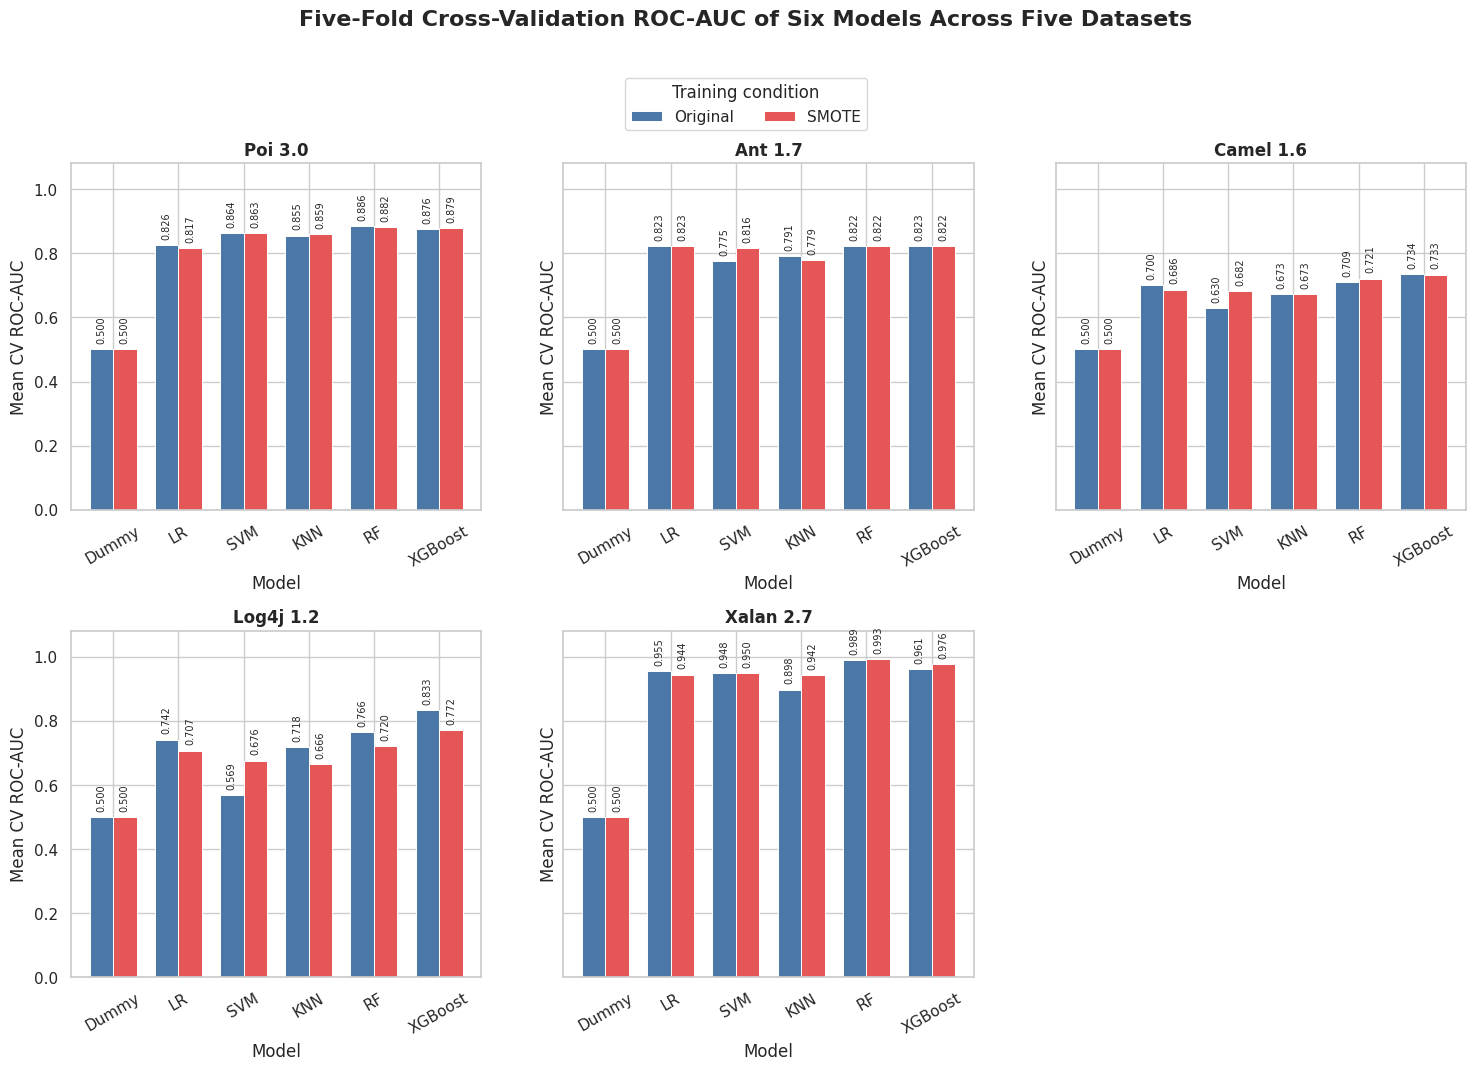

In [50]:
# Figure 4.1 — five-fold CV ROC-AUC comparison for all six models
# across the five software defect datasets

model_labels = {
    "Dummy": "Dummy",
    "Logistic Regression": "LR",
    "SVM": "SVM",
    "KNN": "KNN",
    "Random Forest": "RF",
    "XGBoost": "XGBoost",
}

plot_model_order = [
    "Dummy",
    "Logistic Regression",
    "SVM",
    "KNN",
    "Random Forest",
    "XGBoost",
]

condition_colours = {
    "Original": "#4C78A8",
    "SMOTE": "#E45756",
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11),
    sharey=True,
)

axes = axes.ravel()

x_positions = np.arange(len(plot_model_order))
bar_width = 0.36

for ax, dataset_name in zip(
    axes,
    DATASET_ORDER,
):
    dataset_results = cv_results[
        cv_results["Dataset"] == dataset_name
    ].copy()

    for condition_index, condition in enumerate(
        ["Original", "SMOTE"]
    ):
        condition_results = (
            dataset_results[
                dataset_results["Condition"] == condition
            ]
            .set_index("Model")
            .reindex(plot_model_order)
        )

        offset = (
            condition_index - 0.5
        ) * bar_width

        bars = ax.bar(
            x_positions + offset,
            condition_results["ROC-AUC Mean"],
            width=bar_width,
            color=condition_colours[condition],
            edgecolor="white",
            linewidth=0.7,
            label=condition,
        )

        # Display the mean CV ROC-AUC above each bar
        for bar, score in zip(
            bars,
            condition_results["ROC-AUC Mean"],
        ):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.018,
                f"{score:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90,
            )

    ax.set_title(
        dataset_name,
        fontweight="bold",
    )

    ax.set_xticks(
        x_positions,
        [
            model_labels[model]
            for model in plot_model_order
        ],
    )

    ax.tick_params(
        axis="x",
        rotation=30,
    )

    ax.set_xlabel("Model")
    ax.set_ylabel("Mean CV ROC-AUC")
    ax.set_ylim(0, 1.08)

# Remove unused sixth subplot
axes[-1].axis("off")

# One shared legend outside the subplots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Training condition",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    ncol=2,
    frameon=True,
)

fig.suptitle(
    "Five-Fold Cross-Validation ROC-AUC of Six Models Across Five Datasets",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Reserve sufficient space for the title and shared legend
fig.subplots_adjust(
    top=0.84,
    bottom=0.10,
    hspace=0.35,
    wspace=0.20,
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_1_CV_ROC_AUC_Six_Models_Five_Datasets.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [51]:
def format_mean_sd(mean, sd):
    return f"{mean:.3f} ± {sd:.3f}"


def cv_display_table(condition):
    part = cv_results[cv_results["Condition"] == condition].copy()
    out = part[["Dataset", "Model"]].copy()
    for metric in ["ROC-AUC", "F1", "Recall", "Precision", "Accuracy"]:
        out[metric] = [
            format_mean_sd(m, s)
            for m, s in zip(part[f"{metric} Mean"], part[f"{metric} SD"])
        ]
    return out


table_4_1 = cv_display_table("Original")
table_4_2 = cv_display_table("SMOTE")
save_table(table_4_1, "Table_4_1_CV_Original.csv")
save_table(table_4_2, "Table_4_2_CV_SMOTE.csv")

rank_source = cv_results.copy()
rank_source["ROC-AUC Rank"] = rank_source.groupby(["Dataset", "Condition"])["ROC-AUC Mean"].rank(
    ascending=False, method="average"
)

champion_rows = []
for model_name in MODEL_ORDER:
    m = rank_source[rank_source["Model"] == model_name]
    sm = m[m["Condition"] == "SMOTE"]
    champion_rows.append({
        "Model": model_name,
        "Mean CV ROC-AUC (Original)": m.loc[m["Condition"] == "Original", "ROC-AUC Mean"].mean(),
        "Mean CV ROC-AUC (SMOTE)": sm["ROC-AUC Mean"].mean(),
        "_Selection ROC-AUC": m["ROC-AUC Mean"].mean(),
        "Mean rank (ROC-AUC)": m["ROC-AUC Rank"].mean(),
        "Mean CV F1 (SMOTE)": sm["F1 Mean"].mean(),
    })

table_4_3 = pd.DataFrame(champion_rows).sort_values(
    ["_Selection ROC-AUC", "Mean rank (ROC-AUC)", "Mean CV F1 (SMOTE)"],
    ascending=[False, True, False],
).reset_index(drop=True)
CHAMPION_MODEL = table_4_3.iloc[0]["Model"]
table_4_3 = table_4_3.drop(columns="_Selection ROC-AUC")
save_table(table_4_3, "Table_4_3_Champion_Selection.csv")
save_table(
    cv_results[["Dataset", "Condition", "Model", "Best Params", "Search Seconds"]],
    "Appendix_RQ1_Best_Parameters.csv",
    folder=APPENDIX_DIR,
)

print(f"Champion algorithm selected from CV only: {CHAMPION_MODEL}")
display(table_4_3.round(3))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_1_CV_Original.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_2_CV_SMOTE.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_3_Champion_Selection.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ1_Best_Parameters.csv
Champion algorithm selected from CV only: XGBoost


,Model,Mean CV ROC-AUC (Original),Mean CV ROC-AUC (SMOTE),Mean rank (ROC-AUC),Mean CV F1 (SMOTE)
0,XGBoost,0.845,0.836,1.5,0.741
1,Random Forest,0.834,0.828,1.8,0.754
2,Logistic Regression,0.809,0.795,3.2,0.700
3,KNN,0.787,0.784,4.5,0.699
4,SVM,0.757,0.797,4.0,0.725
5,Dummy,0.500,0.500,6.0,0.000


The cross-validated selection identifies **XGBoost** as the champion algorithm. Its mean ROC-AUC is 0.845 under the Original condition and 0.836 under SMOTE, exceeding the corresponding mean ROC-AUC of the other five algorithms. Random Forest produces a slightly higher mean SMOTE F1-score (0.754 versus 0.741), but ROC-AUC was defined in advance as the primary selection metric. Consequently, RQ2-RQ3 use the **SMOTE-trained, dataset-specific tuned XGBoost models**. The same champion algorithm is used across all five projects, while its tuned hyperparameters may differ by project.

### 7.2 Champion refit and held-out test evaluation

In [52]:
all_test_rows = []
prediction_store = {}
fitted_models = {}

for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    for condition in CONDITION_ORDER:
        for model_name in MODEL_ORDER:
            model_filename = f"{safe_name(dataset_name)}__{safe_name(condition)}__{safe_name(model_name)}.joblib"
            model_path = MODEL_DIR / model_filename
            legacy_model_path = LEGACY_MODEL_DIR / model_filename
            existing_model_path = model_path if model_path.exists() else legacy_model_path
            if existing_model_path.exists():
                fitted = joblib.load(existing_model_path)
            else:
                row = cv_results.query(
                    "Dataset == @dataset_name and Condition == @condition and Model == @model_name"
                ).iloc[0]
                fitted = build_pipeline(model_name, condition, SPLIT_SEED)
                fitted.set_params(**json.loads(row["Best Params"]))
                fitted.fit(split["X_train"], split["y_train"])
                joblib.dump(fitted, model_path)

            probability = fitted.predict_proba(split["X_test"])[:, 1]
            metrics = evaluate_binary(split["y_test"], probability)
            all_test_rows.append({
                "Dataset": dataset_name,
                "Condition": condition,
                "Model": model_name,
                **metrics,
            })

            if model_name == CHAMPION_MODEL:
                fitted_models[(dataset_name, condition)] = fitted
                prediction_store[(dataset_name, condition)] = probability

all_test_results = pd.DataFrame(all_test_rows)
save_table(all_test_results, "Appendix_RQ1_All_Models_Heldout_Test.csv", folder=APPENDIX_DIR)

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ1_All_Models_Heldout_Test.csv


PosixPath('/content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ1_All_Models_Heldout_Test.csv')

In [53]:
# Table 4.4 — champion held-out performance
minority_lookup = split_summary.set_index("Dataset")["Overall minority %"].to_dict()
minority_class_lookup = split_summary.set_index("Dataset")["Minority class"].to_dict()
table_4_4 = all_test_results[all_test_results["Model"] == CHAMPION_MODEL].copy()
table_4_4.insert(1, "Minority %", table_4_4["Dataset"].map(minority_lookup))
table_4_4 = table_4_4.drop(columns="Model")
table_4_4["Dataset"] = pd.Categorical(table_4_4["Dataset"], DATASET_ORDER, ordered=True)
table_4_4["Condition"] = pd.Categorical(table_4_4["Condition"], CONDITION_ORDER, ordered=True)
table_4_4 = table_4_4.sort_values(["Dataset", "Condition"]).reset_index(drop=True)
save_table(table_4_4, "Table_4_4_Champion_Heldout_Test.csv")

# Table 4.5 — SMOTE effects
effect_rows = []
for dataset_name in DATASET_ORDER:
    o = table_4_4.query("Dataset == @dataset_name and Condition == 'Original'").iloc[0]
    s = table_4_4.query("Dataset == @dataset_name and Condition == 'SMOTE'").iloc[0]
    effect_rows.append({
        "Dataset": dataset_name,
        "Minority %": minority_lookup[dataset_name],
        "Minority class": minority_class_lookup[dataset_name],
        "ROC-AUC (Orig)": o["ROC-AUC"],
        "ROC-AUC (SMOTE)": s["ROC-AUC"],
        "Δ ROC-AUC": s["ROC-AUC"] - o["ROC-AUC"],
        "F1 (Orig)": o["F1"],
        "F1 (SMOTE)": s["F1"],
        "Δ F1": s["F1"] - o["F1"],
    })
table_4_5 = pd.DataFrame(effect_rows)
save_table(table_4_5, "Table_4_5_SMOTE_Effect.csv")
display(table_4_4.round(3))
display(table_4_5.round(3))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_4_Champion_Heldout_Test.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_5_SMOTE_Effect.csv


,Dataset,Minority %,Condition,ROC-AUC,F1,Recall,Precision,Accuracy
0,Poi 3.0,36.425,Original,0.885,0.854,0.859,0.849,0.812
1,Poi 3.0,36.425,SMOTE,0.895,0.866,0.835,0.899,0.835
2,Ant 1.7,22.282,Original,0.826,0.488,0.420,0.583,0.804
3,Ant 1.7,22.282,SMOTE,0.809,0.600,0.660,0.550,0.804
4,Camel 1.6,19.482,Original,0.680,0.182,0.107,0.600,0.814
5,Camel 1.6,19.482,SMOTE,0.682,0.351,0.304,0.415,0.783
6,Log4j 1.2,7.805,Original,0.870,0.949,0.982,0.918,0.903
7,Log4j 1.2,7.805,SMOTE,0.877,0.957,0.965,0.948,0.919
8,Xalan 2.7,1.210,Original,0.901,0.996,1.000,0.993,0.993
9,Xalan 2.7,1.210,SMOTE,0.907,0.996,1.000,0.993,0.993


,Dataset,Minority %,Minority class,ROC-AUC (Orig),ROC-AUC (SMOTE),Δ ROC-AUC,F1 (Orig),F1 (SMOTE),Δ F1
0,Poi 3.0,36.425,Non-defective,0.885,0.895,0.010,0.854,0.866,0.012
1,Ant 1.7,22.282,Defective,0.826,0.809,-0.017,0.488,0.600,0.112
2,Camel 1.6,19.482,Defective,0.680,0.682,0.001,0.182,0.351,0.169
3,Log4j 1.2,7.805,Non-defective,0.870,0.877,0.007,0.949,0.957,0.007
4,Xalan 2.7,1.210,Non-defective,0.901,0.907,0.006,0.996,0.996,0.000


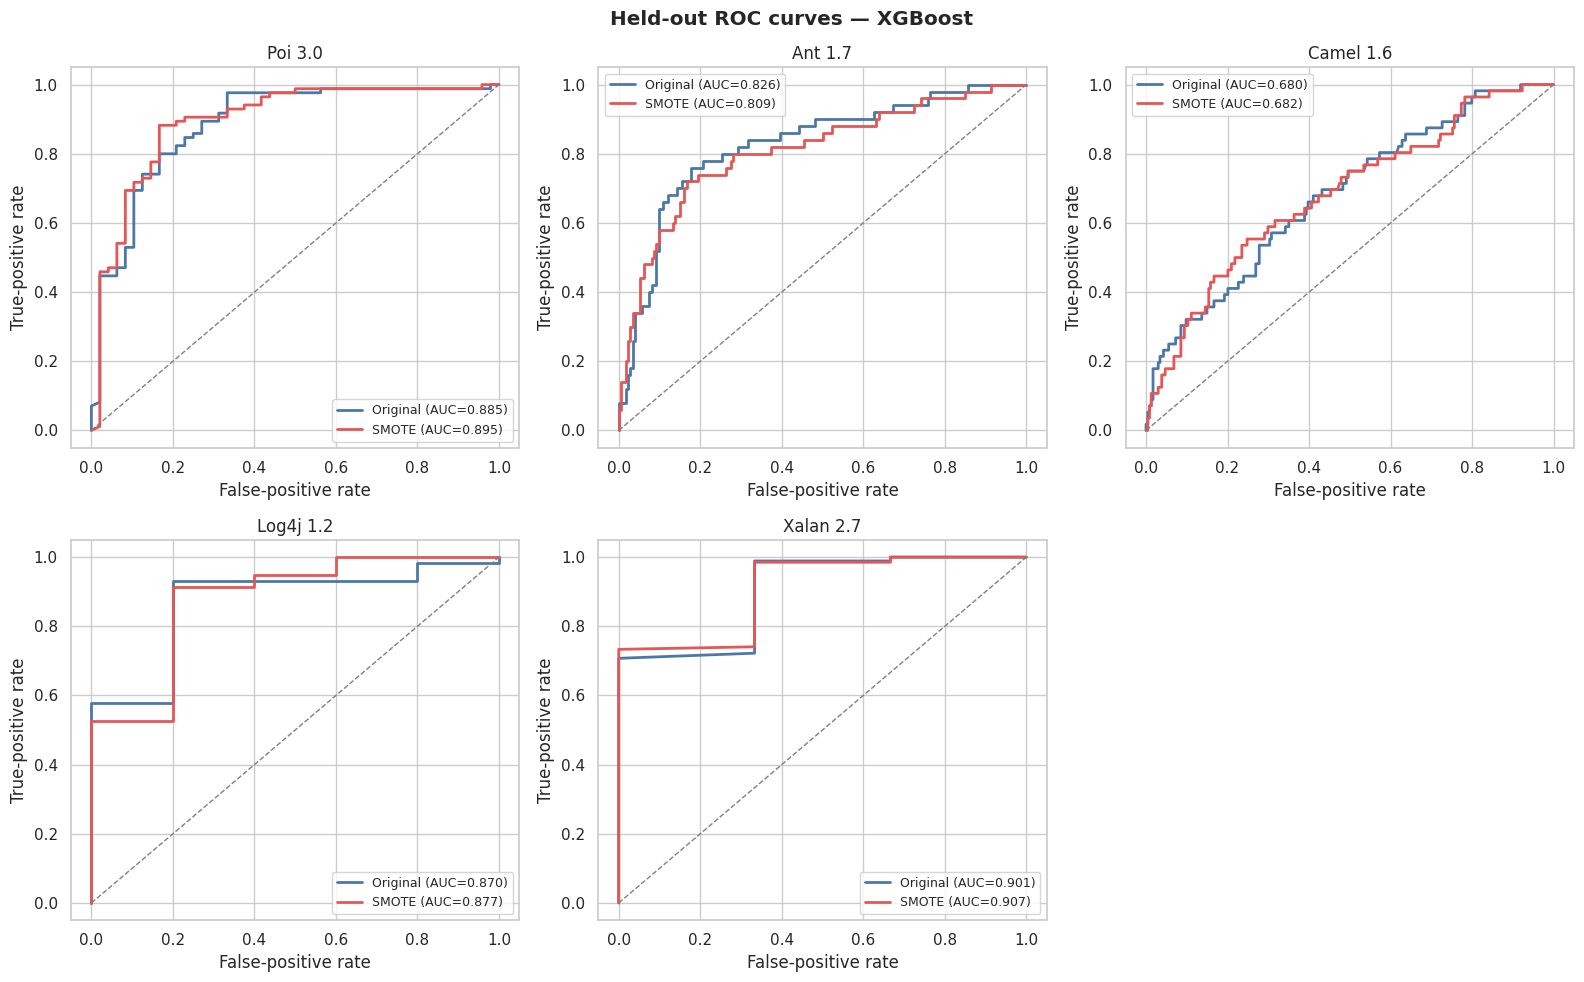

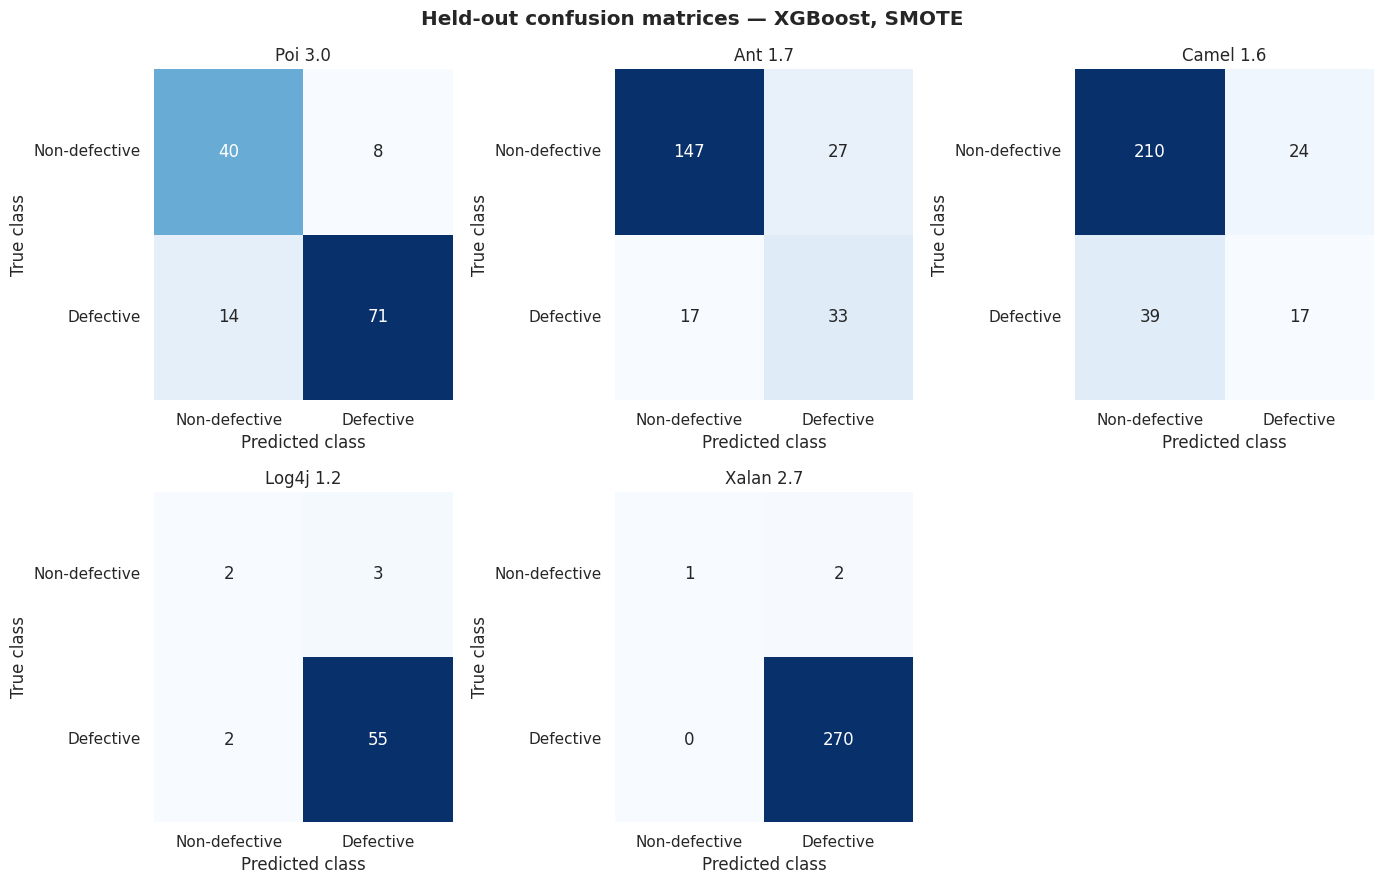

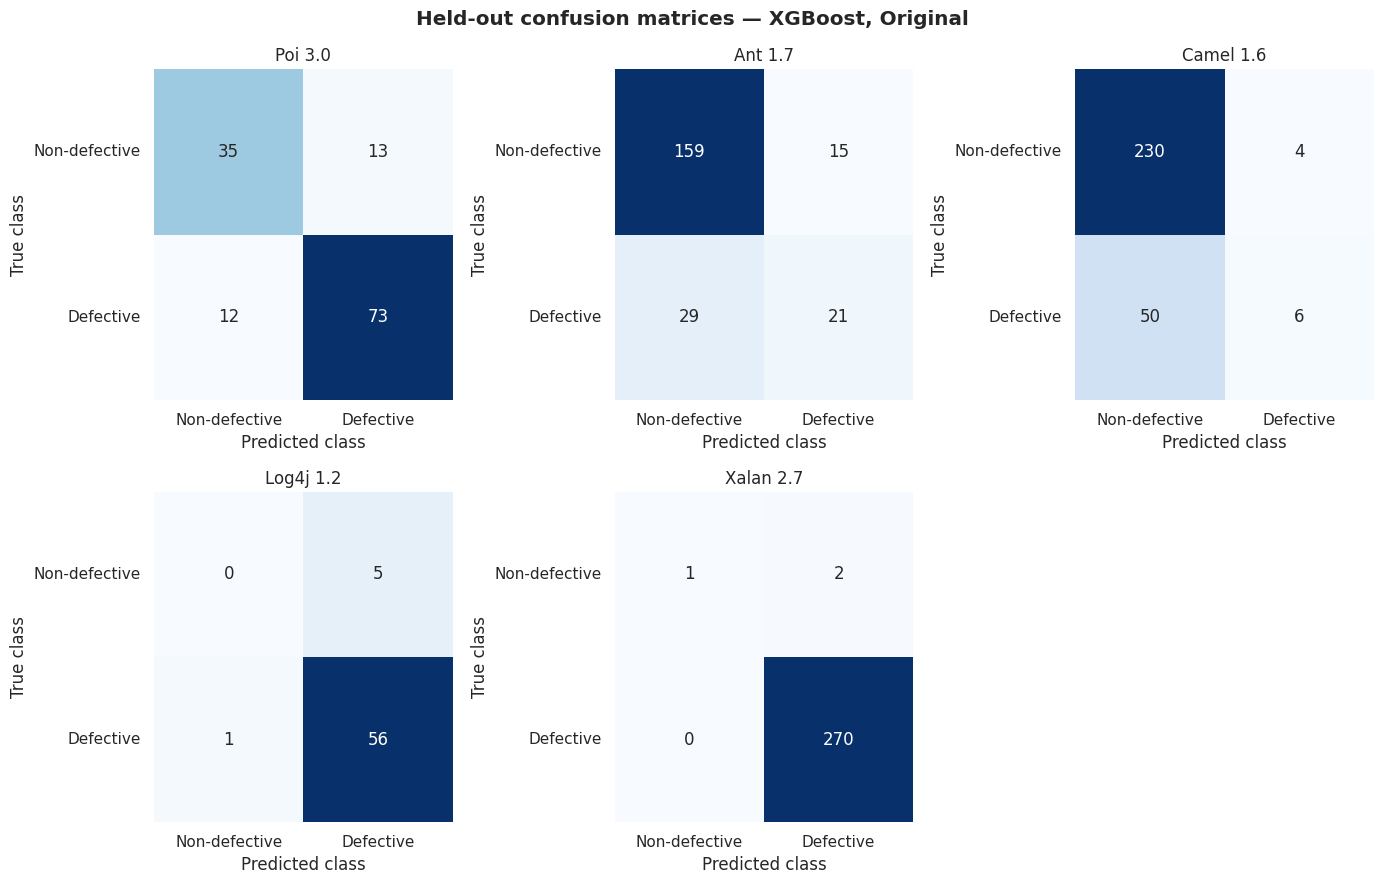

In [54]:
# Figure 4.2 — held-out ROC curves
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for ax, dataset_name in zip(axes, DATASET_ORDER):
    y_test = splits[dataset_name]["y_test"]
    for condition, colour in [("Original", "#4C78A8"), ("SMOTE", "#E45756")]:
        prob = prediction_store[(dataset_name, condition)]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, lw=2, color=colour, label=f"{condition} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
    ax.set(title=dataset_name, xlabel="False-positive rate", ylabel="True-positive rate")
    ax.legend(fontsize=9)
axes[-1].axis("off")
fig.suptitle(f"Held-out ROC curves — {CHAMPION_MODEL}", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure_4_2_Heldout_ROC_Curves_XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()


def plot_confusion_grid(condition, output_path, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.ravel()
    for ax, dataset_name in zip(axes, DATASET_ORDER):
        y_true = splits[dataset_name]["y_test"]
        y_pred = (prediction_store[(dataset_name, condition)] >= 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set(title=dataset_name, xlabel="Predicted class", ylabel="True class")
        ax.set_xticklabels(["Non-defective", "Defective"])
        ax.set_yticklabels(["Non-defective", "Defective"], rotation=0)
    axes[-1].axis("off")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_confusion_grid(
    "SMOTE",
    FIGURE_DIR / "Figure_4_3_SMOTE_Confusion_Matrices_XGBoost.png",
    f"Held-out confusion matrices — {CHAMPION_MODEL}, SMOTE",
)
plot_confusion_grid(
    "Original",
    APPENDIX_DIR / "Appendix_RQ1_Original_Confusion_Matrices.png",
    f"Held-out confusion matrices — {CHAMPION_MODEL}, Original",
)

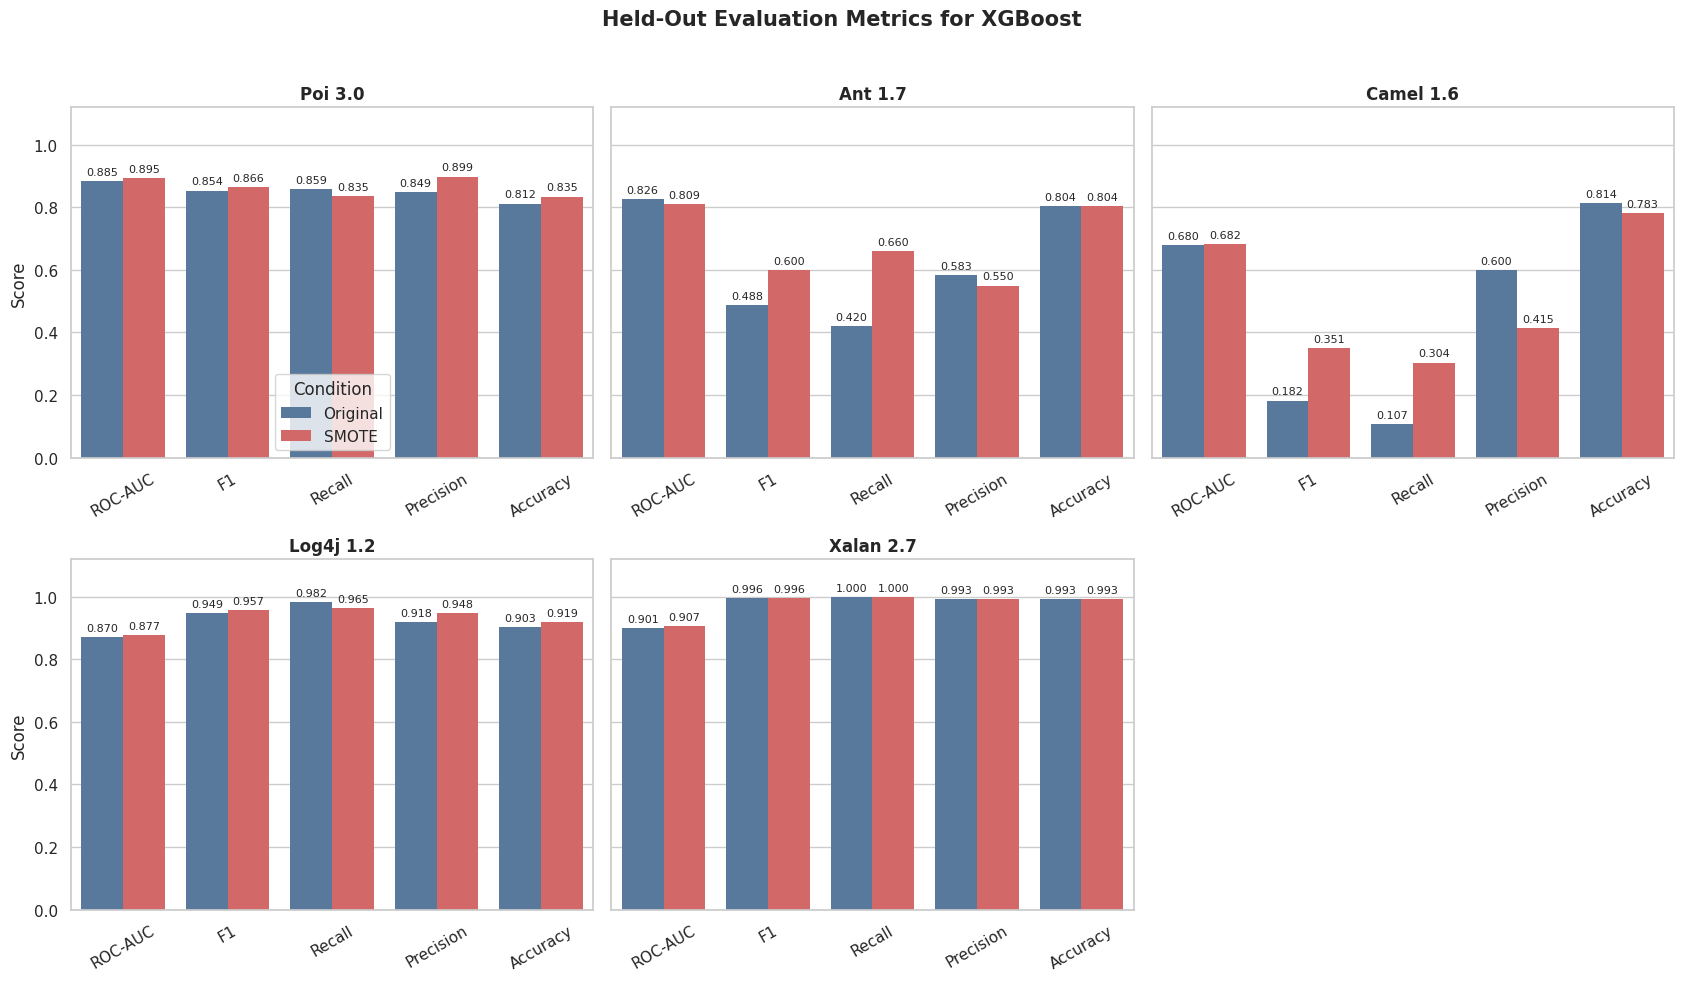

In [55]:
metric_columns = [
    "ROC-AUC",
    "F1",
    "Recall",
    "Precision",
    "Accuracy",
]

metric_plot_data = table_4_4.melt(
    id_vars=["Dataset", "Condition"],
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score",
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 10),
    sharey=True,
)

axes = axes.ravel()

for ax, dataset_name in zip(
    axes,
    DATASET_ORDER,
):
    subset = metric_plot_data[
        metric_plot_data["Dataset"] == dataset_name
    ]

    sns.barplot(
        data=subset,
        x="Metric",
        y="Score",
        hue="Condition",
        hue_order=["Original", "SMOTE"],
        palette={
            "Original": "#4C78A8",
            "SMOTE": "#E45756",
        },
        errorbar=None,
        edgecolor="None",
        ax=ax,
    )

    # Add the score above every bar
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=8,
        )

    ax.set_title(
        dataset_name,
        fontweight="bold",
    )

    # Extra space prevents labels from being cut off
    ax.set_ylim(0, 1.12)

    ax.tick_params(
        axis="x",
        rotation=30,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Score")

    if ax is not axes[0]:
        legend = ax.get_legend()

        if legend is not None:
            legend.remove()

# Remove unused subplot
axes[-1].axis("off")

fig.suptitle(
    "Held-Out Evaluation Metrics for XGBoost",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_4_Heldout_Metric_Comparison_XGBoost.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

XGBoost achieved the highest overall cross-validated ROC-AUC and was therefore selected even though Random Forest recorded a slightly higher mean SMOTE F1-score. On the held-out test sets, SMOTE increased ROC-AUC for Poi (+0.010), Camel (+0.001), Log4j (+0.007), and Xalan (+0.006), but reduced it for Ant (-0.017). The strongest threshold-dependent improvements occurred for Ant and Camel, where F1 increased by 0.112 and 0.169 respectively because recall increased after balancing. This shows that SMOTE mainly changed the classification operating point rather than uniformly improving discrimination.

The very high F1-score and accuracy for Log4j and Xalan require caution. In these two projects, the **non-defective class is the minority**, while F1 treats defective modules as the positive class. A model can therefore obtain a high F1-score by predicting the dominant defective class well. Xalan's test set also contains only approximately three non-defective modules, so its ROC-AUC should be reported with less confidence than the other projects.

## 8. Shared XAI utilities and fixed 50-module subsets


In [56]:
def select_fixed_positions(predicted_class, n=N_EXPLAIN, seed=SPLIT_SEED):
    predicted_class = np.asarray(predicted_class)
    total = len(predicted_class)
    n = min(n, total)
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(predicted_class, return_counts=True)
    if len(classes) == 1:
        return np.sort(rng.choice(np.arange(total), size=n, replace=False))

    raw = counts / counts.sum() * n
    allocation = np.floor(raw).astype(int)
    allocation = np.maximum(allocation, 1)
    allocation = np.minimum(allocation, counts)
    while allocation.sum() < n:
        candidates = np.where(allocation < counts)[0]
        j = candidates[np.argmax(raw[candidates] - allocation[candidates])]
        allocation[j] += 1
    while allocation.sum() > n:
        candidates = np.where(allocation > 1)[0]
        j = candidates[np.argmax(allocation[candidates] - raw[candidates])]
        allocation[j] -= 1

    chosen = []
    for class_value, take in zip(classes, allocation):
        positions = np.where(predicted_class == class_value)[0]
        chosen.extend(rng.choice(positions, size=int(take), replace=False).tolist())
    return np.array(sorted(chosen))


fixed_positions = {}
fixed_rows = []
for dataset_name in DATASET_ORDER:
    smote_pred = (prediction_store[(dataset_name, "SMOTE")] >= 0.5).astype(int)
    positions = select_fixed_positions(smote_pred)
    fixed_positions[dataset_name] = positions
    split = splits[dataset_name]
    for subset_position, test_position in enumerate(positions):
        fixed_rows.append({
            "Dataset": dataset_name,
            "Subset position": subset_position,
            "Test position": int(test_position),
            "Original row index": split["X_test"].index[test_position],
            "True class": int(split["y_test"].iloc[test_position]),
            "SMOTE predicted class": int(smote_pred[test_position]),
        })

fixed_instance_table = pd.DataFrame(fixed_rows)
save_table(fixed_instance_table, "Appendix_Fixed_50_Test_Modules.csv", folder=APPENDIX_DIR)
display(fixed_instance_table.groupby(["Dataset", "SMOTE predicted class"]).size().unstack(fill_value=0))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_Fixed_50_Test_Modules.csv


SMOTE predicted class,0,1
Dataset,,
Ant 1.7,37,13
Camel 1.6,43,7
Log4j 1.2,3,47
Poi 3.0,20,30
Xalan 2.7,1,49


In [57]:
def transformed_features(fitted_pipeline, X):
    values = fitted_pipeline.named_steps["log1p"].transform(X)
    scaler = fitted_pipeline.named_steps["scale"]
    if scaler != "passthrough":
        values = scaler.transform(values)
    return np.asarray(values)


def positive_class_shap(fitted_pipeline, X_background, X_explain):
    model = fitted_pipeline.named_steps["model"]
    background_t = transformed_features(fitted_pipeline, X_background)
    explain_t = transformed_features(fitted_pipeline, X_explain)

    if isinstance(model, (RandomForestClassifier, XGBClassifier)):
        explainer = shap.TreeExplainer(model)
        raw = explainer(explain_t)
    elif isinstance(model, LogisticRegression):
        explainer = shap.LinearExplainer(model, background_t)
        raw = explainer(explain_t)
    else:
        background_small = shap.sample(background_t, min(50, len(background_t)), random_state=SPLIT_SEED)
        prediction_function = lambda a: model.predict_proba(a)[:, 1]
        explainer = shap.Explainer(prediction_function, background_small, algorithm="permutation")
        raw = explainer(explain_t, max_evals=2 * explain_t.shape[1] + 1)

    values = np.asarray(raw.values)
    base_values = np.asarray(raw.base_values)
    if values.ndim == 3:
        values = values[:, :, 1]
        if base_values.ndim == 2:
            base_values = base_values[:, 1]
    if base_values.ndim == 0:
        base_values = np.repeat(float(base_values), len(X_explain))
    elif base_values.ndim > 1:
        base_values = base_values.reshape(len(X_explain), -1)[:, -1]
    return values, np.asarray(base_values), explain_t


def lime_weights_for_instances(fitted_pipeline, X_train, X_explain, seed, num_samples=N_LIME_SAMPLES):
    training_array = X_train[final_feature_cols].to_numpy(dtype=float)
    explainer = LimeTabularExplainer(
        training_data=training_array,
        feature_names=final_feature_cols,
        class_names=["Non-defective", "Defective"],
        mode="classification",
        discretize_continuous=True,
        random_state=seed,
    )

    def predict_array(array):
        frame = pd.DataFrame(array, columns=final_feature_cols)
        return fitted_pipeline.predict_proba(frame)

    rows = []
    for array in X_explain[final_feature_cols].to_numpy(dtype=float):
        explanation = explainer.explain_instance(
            array,
            predict_array,
            labels=(1,),
            num_features=len(final_feature_cols),
            num_samples=num_samples,
        )
        mapping = dict(explanation.as_map().get(1, []))
        rows.append([mapping.get(i, 0.0) for i in range(len(final_feature_cols))])
    return np.asarray(rows)


def importance_ranks(values):
    series = pd.Series(np.asarray(values), index=final_feature_cols)
    return series.rank(ascending=False, method="first").astype(int)


def top_k_jaccard(rank_a, rank_b, k):
    a = set(pd.Series(rank_a).nsmallest(k).index)
    b = set(pd.Series(rank_b).nsmallest(k).index)
    return len(a & b) / len(a | b)


def top_k_feature_agreement(rank_a, rank_b, k):
    a = set(pd.Series(rank_a).nsmallest(k).index)
    b = set(pd.Series(rank_b).nsmallest(k).index)
    return len(a & b) / k


def kendalls_w(rank_matrix):
    ranks = np.asarray(rank_matrix, dtype=float)
    m, n = ranks.shape
    rank_sums = ranks.sum(axis=0)
    expected = m * (n + 1) / 2
    s = np.square(rank_sums - expected).sum()
    denominator = (m ** 2) * (n ** 3 - n)
    w = 12 * s / denominator if denominator else np.nan
    chi_square = m * (n - 1) * w
    p_value = chi2.sf(chi_square, n - 1)
    return float(w), float(chi_square), int(n - 1), float(p_value)


def subset_w(rank_df, features):
    reranked = rank_df[features].rank(axis=1, method="first").to_numpy()
    return kendalls_w(reranked)

## 9. Influential static code metrics and SHAP–LIME analysis — RQ2

### 9.1 Full-test global SHAP importance


In [58]:
rq2_shap_values = {}
rq2_shap_bases = {}
rq2_shap_X = {}
rq2_shap_importance_rows = []

for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    X_explain = split["X_test"][final_feature_cols].copy()
    model = fitted_models[(dataset_name, "SMOTE")]
    values, bases, _ = positive_class_shap(
        model,
        split["X_train"],
        X_explain,
    )
    rq2_shap_values[dataset_name] = values
    rq2_shap_bases[dataset_name] = bases
    rq2_shap_X[dataset_name] = X_explain

    importance = pd.Series(
        np.abs(values).mean(axis=0),
        index=final_feature_cols,
    )
    ranks = importance_ranks(importance)
    for feature in final_feature_cols:
        rq2_shap_importance_rows.append({
            "Dataset": dataset_name,
            "Metric": feature,
            "Mean absolute SHAP": importance[feature],
            "Rank": int(ranks[feature]),
            "Test modules": len(X_explain),
        })

rq2_shap_importance = pd.DataFrame(rq2_shap_importance_rows)
save_table(
    rq2_shap_importance,
    "Appendix_RQ2_Full_Test_SHAP_Importance.csv",
    folder=APPENDIX_DIR,
)

rq2_shap_rank_table = rq2_shap_importance.pivot(
    index="Metric", columns="Dataset", values="Rank"
)[PROJECT_ORDER]
rq2_shap_rank_table["Mean rank"] = rq2_shap_rank_table.mean(axis=1)
rq2_shap_rank_table["Times in top 5"] = (
    (rq2_shap_rank_table[PROJECT_ORDER] <= 5).sum(axis=1).astype(str) + " / 5"
)
table_4_6 = rq2_shap_rank_table.sort_values("Mean rank").reset_index()
save_table(table_4_6, "Table_4_6_Full_Test_Global_SHAP_Ranks.csv")
display(table_4_6.round(1))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ2_Full_Test_SHAP_Importance.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_6_Full_Test_Global_SHAP_Ranks.csv


Dataset,Metric,Ant 1.7,Camel 1.6,Log4j 1.2,Poi 3.0,Xalan 2.7,Mean rank,Times in top 5
0,loc,1,9,2,4,2,3.6,4 / 5
1,ce,13,4,1,2,8,5.6,3 / 5
2,cbo,9,5,3,9,7,6.6,2 / 5
3,amc,5,3,9,5,13,7.0,3 / 5
4,npm,8,6,5,15,1,7.0,2 / 5
5,lcom,4,11,8,6,10,7.8,1 / 5
6,cam,10,8,7,10,4,7.8,1 / 5
7,avg_cc,3,13,12,8,5,8.2,2 / 5
8,mfa,11,1,10,13,6,8.2,1 / 5
9,lcom3,6,10,13,3,9,8.2,1 / 5


### 9.2 Cross-project consistency of SHAP rankings


Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_7_Cross_Project_SHAP_Consistency.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_8_Pairwise_SHAP_Kendall_Tau.csv


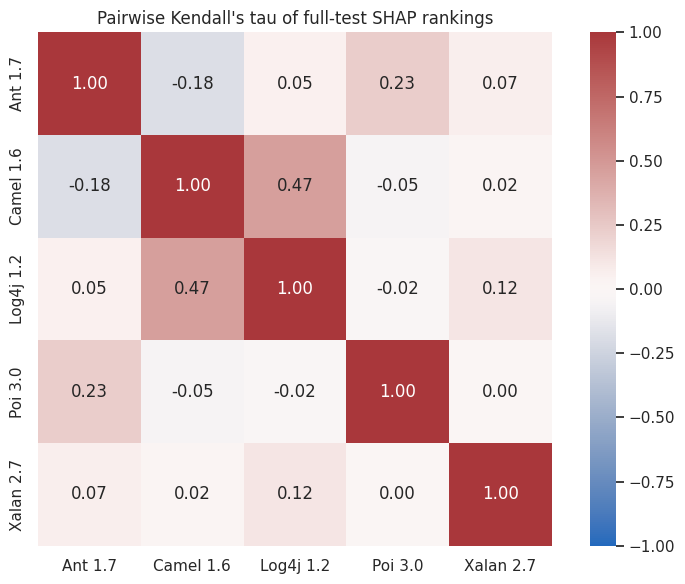

,Statistic,Value
0,"Kendall's W (5 rankings, 16 features)",0.294
1,df,15.000
2,p-value,0.106
3,Mean pairwise Kendall's tau,0.070
4,Mean pairwise top-5 Jaccard,0.183


In [59]:
rank_matrix_projects = rq2_shap_rank_table.loc[:, PROJECT_ORDER].T.to_numpy()
w, chi_square, df_w, p_w = kendalls_w(rank_matrix_projects)

tau_matrix = pd.DataFrame(
    np.eye(len(PROJECT_ORDER)),
    index=PROJECT_ORDER,
    columns=PROJECT_ORDER,
)
pair_taus = []
pair_jaccards = []
for a, b in combinations(PROJECT_ORDER, 2):
    tau, _ = kendalltau(rq2_shap_rank_table[a], rq2_shap_rank_table[b])
    tau_matrix.loc[a, b] = tau
    tau_matrix.loc[b, a] = tau
    pair_taus.append(tau)
    pair_jaccards.append(top_k_jaccard(rq2_shap_rank_table[a], rq2_shap_rank_table[b], 5))

table_4_7 = pd.DataFrame({
    "Statistic": [
        "Kendall's W (5 rankings, 16 features)",
        "df",
        "p-value",
        "Mean pairwise Kendall's tau",
        "Mean pairwise top-5 Jaccard",
    ],
    "Value": [w, df_w, p_w, np.mean(pair_taus), np.mean(pair_jaccards)],
})
table_4_8 = tau_matrix.where(
    np.tril(np.ones(tau_matrix.shape), k=0).astype(bool)
)
save_table(table_4_7, "Table_4_7_Cross_Project_SHAP_Consistency.csv")
save_table(
    table_4_8,
    "Table_4_8_Pairwise_SHAP_Kendall_Tau.csv",
    index=True,
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    tau_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Pairwise Kendall's tau of full-test SHAP rankings")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "Figure_4_5_Full_Test_SHAP_Kendall_Tau_Heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
display(table_4_7.round(3))

__Cross-Project Consistency of SHAP Feature Rankings__

The SHAP feature rankings demonstrated weak consistency across the five software projects. Kendall’s coefficient of concordance was \(W=0.294\), indicating that the five project-specific rankings showed limited overall agreement. The result was not statistically significant at the 5% level (\(\chi^2(15)=22.05\), \(p=0.106\)); therefore, there is insufficient evidence that the projects share a common ordering of the 16 static code metrics. This interpretation is further supported by the mean pairwise Kendall’s \(\tau\) of 0.070, which indicates almost no average rank correlation between pairs of projects. The mean top-five Jaccard similarity was also low at 0.183, showing limited overlap among the features identified as most influential. Overall, the findings suggest that SHAP feature importance is largely project-specific rather than universally consistent across the five datasets. Consequently, defect predictors should be interpreted within the context of each software project instead of assuming that a single feature ranking applies to all projects.


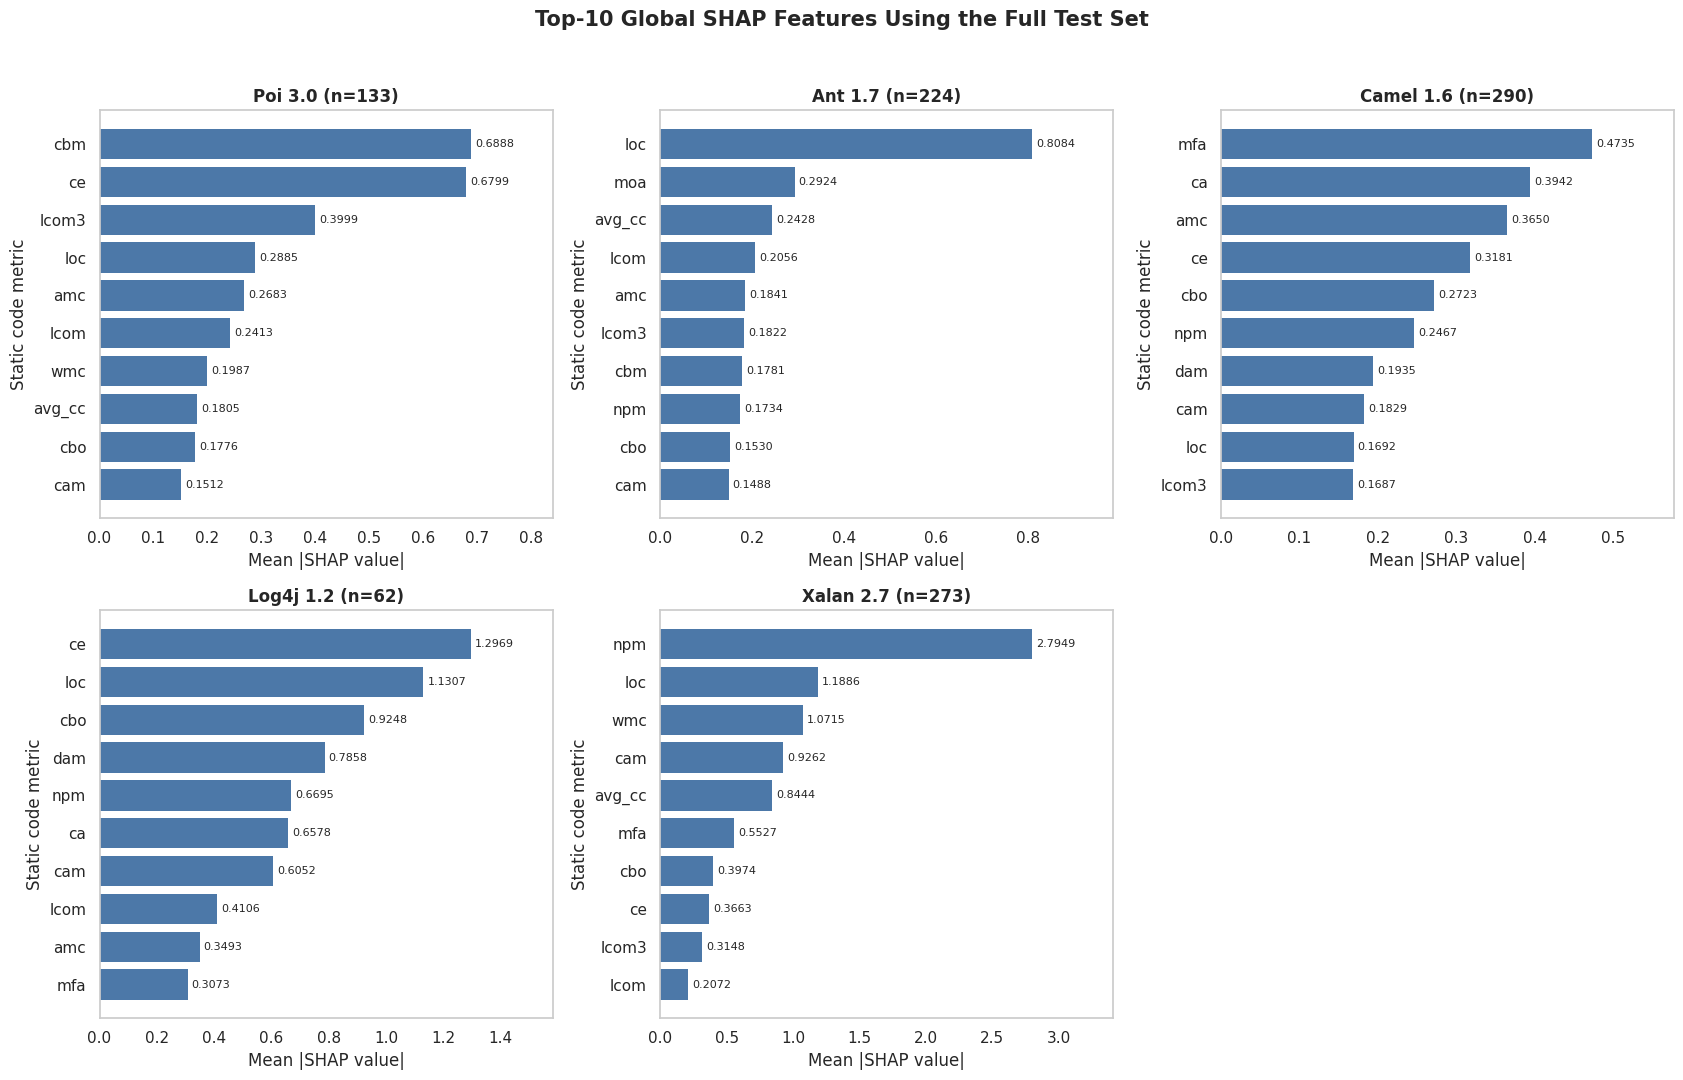

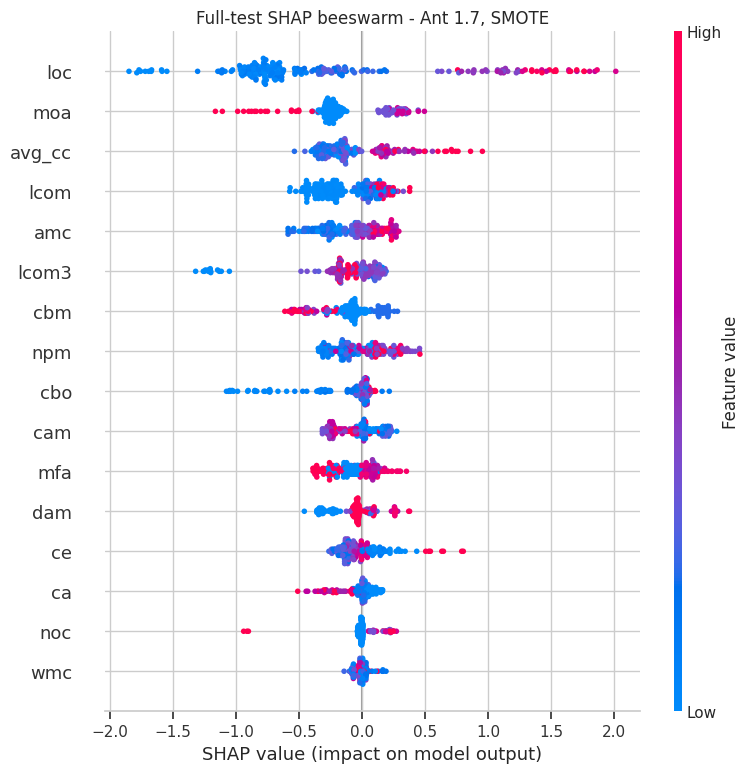

In [60]:
fig, axes = plt.subplots(2, 3,
    figsize=(17, 11),
)

axes = axes.ravel()

for ax, dataset_name in zip(axes, DATASET_ORDER):
    subset = (
        rq2_shap_importance[
            rq2_shap_importance["Dataset"]
            == dataset_name
        ]
        .nlargest(
            10,
            "Mean absolute SHAP",
        )
        .sort_values(
            "Mean absolute SHAP",
        )
    )

    bars = ax.barh(
        subset["Metric"],
        subset["Mean absolute SHAP"],
        color="#4C78A8",
        edgecolor="none",
    )

    # Add importance values beside the bars
    ax.bar_label(
        bars,
        labels=[
            f"{value:.4f}"
            for value in subset[
                "Mean absolute SHAP"
            ]
        ],
        label_type="edge",
        padding=3,
        fontsize=8,
    )

    # Add space for the labels
    maximum = subset[
        "Mean absolute SHAP"
    ].max()

    ax.set_xlim(
        0,
        maximum * 1.22,
    )
    ax.grid(False)

    ax.set_title(
        f"{dataset_name} "
        f"(n={int(subset['Test modules'].iloc[0])})",
        fontweight="bold",
    )

    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Static code metric")

# Remove unused sixth subplot
axes[-1].axis("off")

fig.suptitle(
    "Top-10 Global SHAP Features Using the Full Test Set",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_6_Top10_Full_Test_SHAP_Importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


REPRESENTATIVE_DATASET = "Ant 1.7"
shap.summary_plot(
    rq2_shap_values[REPRESENTATIVE_DATASET],
    rq2_shap_X[REPRESENTATIVE_DATASET],
    feature_names=final_feature_cols,
    show=False,
    max_display=len(final_feature_cols),
)
plt.title(
    f"Full-test SHAP beeswarm - {REPRESENTATIVE_DATASET}, SMOTE"
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "Figure_4_7_Full_Test_SHAP_Beeswarm_Ant.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

for dataset_name in DATASET_ORDER:
    if dataset_name == REPRESENTATIVE_DATASET:
        continue
    shap.summary_plot(
        rq2_shap_values[dataset_name],
        rq2_shap_X[dataset_name],
        feature_names=final_feature_cols,
        show=False,
        max_display=len(final_feature_cols),
    )
    plt.title(f"Appendix full-test SHAP beeswarm - {dataset_name}, SMOTE")
    plt.tight_layout()
    plt.savefig(
        APPENDIX_DIR / f"Appendix_RQ2_Full_Test_SHAP_Beeswarm_{safe_name(dataset_name)}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()

### 9.3 SHAP–LIME agreement and subset representativeness


In [61]:
rq2_lime_weights = {}
rq2_lime_ranks = {}
rq2_subset_shap_values = {}
rq2_subset_shap_bases = {}
rq2_subset_shap_ranks = {}
rq2_agreement_rows = []
rq2_local_lime_rows = []
rq2_lime_importance_rows = []
rq2_representativeness_rows = []

for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    positions = fixed_positions[dataset_name]
    X_fixed = split["X_test"].iloc[positions][final_feature_cols]
    model = fitted_models[(dataset_name, "SMOTE")]

    subset_shap_values, subset_shap_bases, _ = positive_class_shap(
        model,
        split["X_train"],
        X_fixed,
    )
    rq2_subset_shap_values[dataset_name] = subset_shap_values
    rq2_subset_shap_bases[dataset_name] = subset_shap_bases
    shap_importance = pd.Series(
        np.abs(subset_shap_values).mean(axis=0),
        index=final_feature_cols,
    )
    shap_rank = importance_ranks(shap_importance)

    lime_weights = lime_weights_for_instances(
        model,
        split["X_train"],
        X_fixed,
        seed=XAI_SEED,
    )
    rq2_lime_weights[dataset_name] = lime_weights
    lime_importance = pd.Series(
        np.abs(lime_weights).mean(axis=0),
        index=final_feature_cols,
    )
    lime_rank = importance_ranks(lime_importance)

    rq2_subset_shap_ranks[dataset_name] = shap_rank
    rq2_lime_ranks[dataset_name] = lime_rank

    tau, p_value = kendalltau(shap_rank, lime_rank)
    rq2_agreement_rows.append({
        "Dataset": dataset_name,
        "Minority %": minority_lookup[dataset_name],
        "Kendall's tau": tau,
        "p-value": p_value,
        "Top-5 Jaccard": top_k_jaccard(shap_rank, lime_rank, 5),
        "Top-3 Jaccard": top_k_jaccard(shap_rank, lime_rank, 3),
    })

    full_rank = importance_ranks(
        pd.Series(
            np.abs(rq2_shap_values[dataset_name]).mean(axis=0),
            index=final_feature_cols,
        )
    )
    full_subset_tau, full_subset_p = kendalltau(full_rank, shap_rank)
    rq2_representativeness_rows.append({
        "Dataset": dataset_name,
        "Full-test N": len(split["X_test"]),
        "Subset N": len(X_fixed),
        "Kendall's tau": full_subset_tau,
        "p-value": full_subset_p,
        "Top-5 Jaccard": top_k_jaccard(full_rank, shap_rank, 5),
    })

    for feature in final_feature_cols:
        rq2_lime_importance_rows.append({
            "Dataset": dataset_name,
            "Feature": feature,
            "Mean absolute LIME weight": lime_importance[feature],
            "Rank": int(lime_rank[feature]),
            "N modules": len(X_fixed),
        })

    for subset_position, row_weights in enumerate(lime_weights):
        for feature, weight in zip(final_feature_cols, row_weights):
            rq2_local_lime_rows.append({
                "Dataset": dataset_name,
                "Subset position": subset_position,
                "Feature": feature,
                "LIME weight": weight,
                "Absolute weight": abs(weight),
            })

table_4_9 = pd.DataFrame(rq2_lime_importance_rows).sort_values(
    ["Dataset", "Rank"]
)
table_4_10 = pd.DataFrame(rq2_agreement_rows)
rq2_representativeness_table = pd.DataFrame(rq2_representativeness_rows)
save_table(table_4_9, "Table_4_9_Aggregated_LIME_Importance.csv")
save_table(table_4_10, "Table_4_10_SHAP_LIME_Agreement.csv")
save_table(
    rq2_representativeness_table,
    "Appendix_RQ2_Full_Test_vs_50_SHAP_Representativeness.csv",
    folder=APPENDIX_DIR,
)
save_table(
    pd.DataFrame(rq2_local_lime_rows),
    "Appendix_RQ2_All_Local_LIME_Weights.csv",
    folder=APPENDIX_DIR,
)
display(table_4_9.groupby("Dataset").head(10).reset_index(drop=True).round(4))
display(table_4_10.round(3))
display(rq2_representativeness_table.round(3))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_9_Aggregated_LIME_Importance.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_10_SHAP_LIME_Agreement.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ2_Full_Test_vs_50_SHAP_Representativeness.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ2_All_Local_LIME_Weights.csv


,Dataset,Feature,Mean absolute LIME weight,Rank,N modules
0,Ant 1.7,loc,0.1114,1,50
1,Ant 1.7,cbm,0.1071,2,50
2,Ant 1.7,dam,0.0956,3,50
3,Ant 1.7,noc,0.0939,4,50
4,Ant 1.7,avg_cc,0.0641,5,50
5,Ant 1.7,cbo,0.0572,6,50
6,Ant 1.7,lcom,0.0521,7,50
7,Ant 1.7,amc,0.0435,8,50
8,Ant 1.7,npm,0.0430,9,50
9,Ant 1.7,moa,0.0427,10,50


,Dataset,Minority %,Kendall's tau,p-value,Top-5 Jaccard,Top-3 Jaccard
0,Poi 3.0,36.425,0.750,0.000,0.667,0.5
1,Ant 1.7,22.282,0.400,0.033,0.250,0.2
2,Camel 1.6,19.482,0.533,0.003,0.667,0.5
3,Log4j 1.2,7.805,0.767,0.000,1.000,0.5
4,Xalan 2.7,1.210,0.717,0.000,0.667,0.5


,Dataset,Full-test N,Subset N,Kendall's tau,p-value,Top-5 Jaccard
0,Poi 3.0,133,50,0.983,0.0,1.000
1,Ant 1.7,224,50,0.817,0.0,0.667
2,Camel 1.6,290,50,0.833,0.0,0.667
3,Log4j 1.2,62,50,0.983,0.0,1.000
4,Xalan 2.7,273,50,1.000,0.0,1.000


__SHAP–LIME Agreement and Subset Representativeness__

The agreement between SHAP and LIME varied across the five datasets. Log4j demonstrated the strongest agreement, with Kendall’s \(\tau=0.767\) and a top-five Jaccard similarity of 1.000. This indicates that SHAP and LIME selected the same five leading features, although their exact ordering could differ. Poi and Xalan also showed relatively strong ranking agreement, with Kendall’s \(\tau\) values of 0.750 and 0.717, respectively. In both projects, a top-five Jaccard value of 0.667 indicates that four of the five leading features were shared by the two methods.

Camel demonstrated moderate agreement (\(\tau=0.533\)), while Ant produced the weakest agreement (\(\tau=0.400\)). For Ant, the top-five Jaccard similarity was only 0.250, meaning that SHAP and LIME shared two of their five leading features. Its top-three Jaccard value of 0.200 indicates that only one of the three most influential features was shared. Nevertheless, the rank correlations were statistically significant for all projects. Values displayed as \(p=0.000\) should be reported as \(p<0.001\). The results also show no clear relationship between class imbalance and explanation agreement because highly imbalanced projects such as Log4j and Xalan recorded relatively strong agreement.

The second analysis compared the full-test SHAP rankings with the rankings calculated from the fixed 50-module subset. Strong agreement was observed for every project, with Kendall’s \(\tau\) ranging from 0.817 to 1.000 and all comparisons significant at \(p<0.001\). Poi and Log4j achieved \(\tau=0.983\), while Xalan produced an identical ranking (\(\tau=1.000\)). Their top-five Jaccard values of 1.000 indicate complete agreement in top-five feature membership. Ant and Camel retained four of the five full-test leading features, producing Jaccard values of 0.667. These findings support using the fixed 50-module subset for the controlled SHAP–LIME comparison and repeated stability analysis, while the full test set remains the primary basis for reporting global SHAP feature importance.


### 9.4 Aggregated LIME feature importance


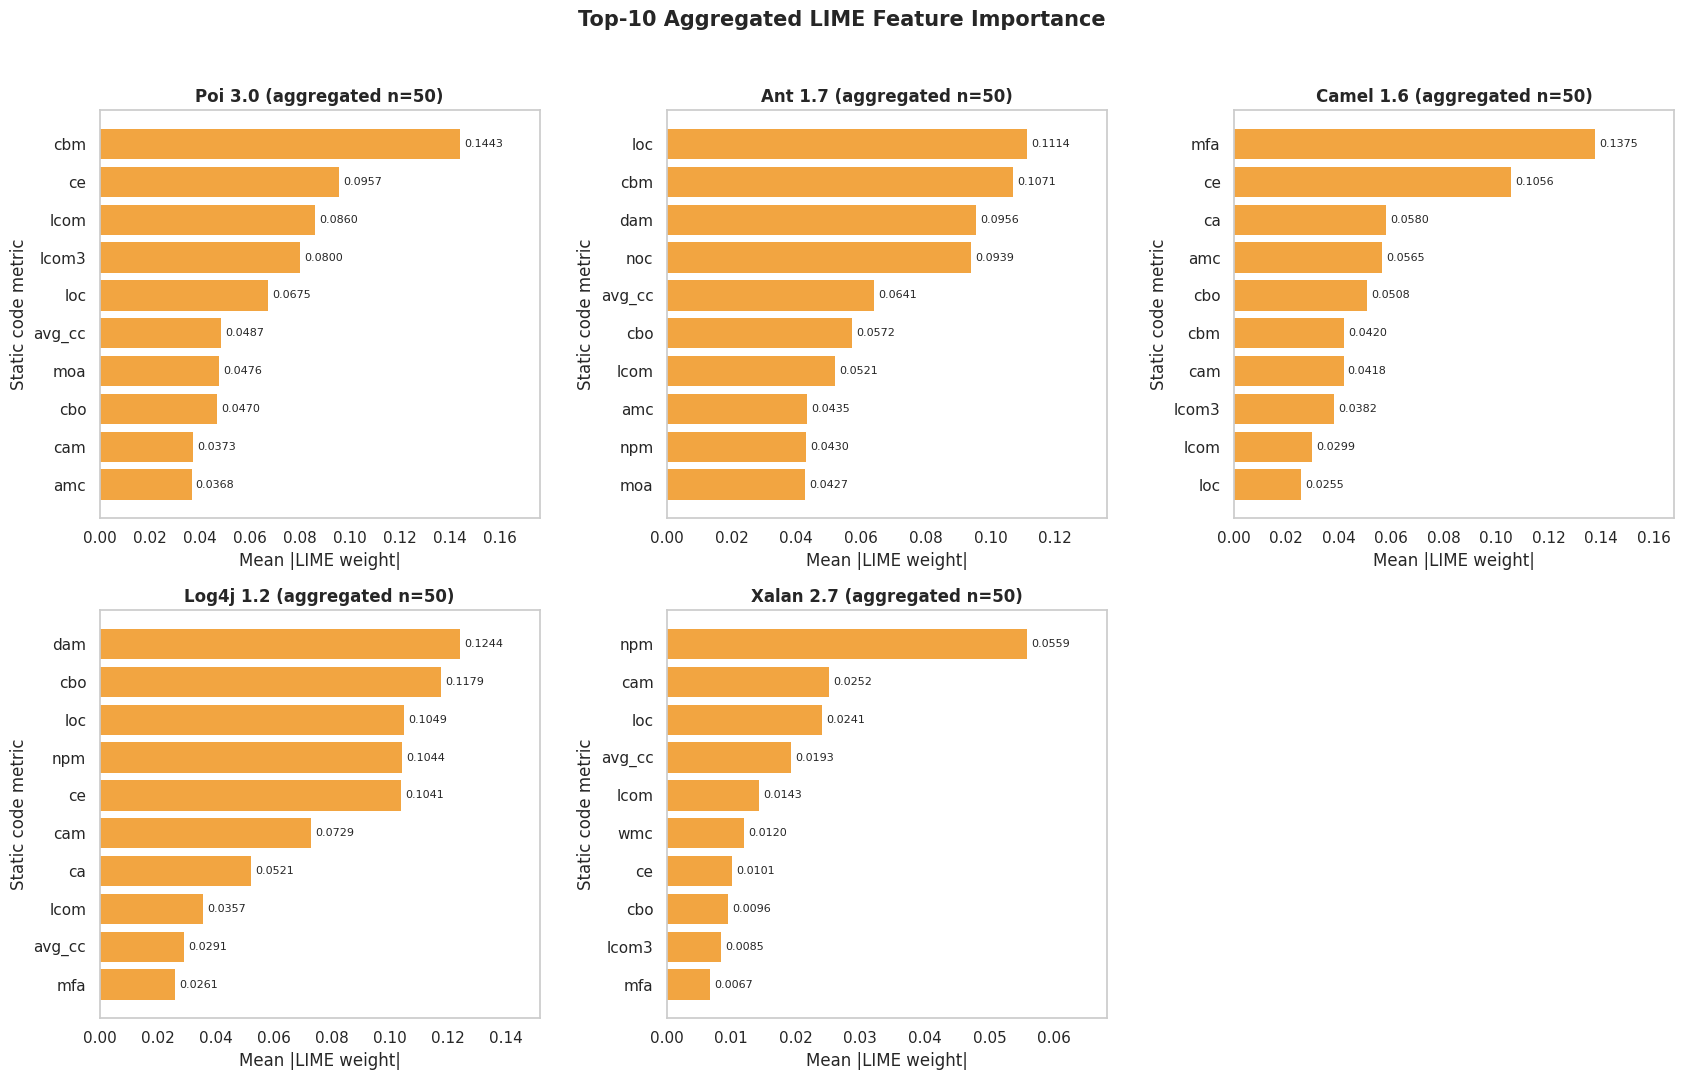

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))

axes = axes.ravel()

for ax, dataset_name in zip(
    axes,
    DATASET_ORDER,
):
    subset = (
        table_4_9[
            table_4_9["Dataset"]
            == dataset_name
        ]
        .nsmallest(10, "Rank")
        .sort_values(
            "Mean absolute LIME weight"
        )
    )

    bars = ax.barh(
        subset["Feature"],
        subset["Mean absolute LIME weight"],
        color="#F2A541",
        edgecolor="none",
    )

    # Add the importance value beside each bar
    ax.bar_label(
        bars,
        labels=[
            f"{value:.4f}"
            for value in subset[
                "Mean absolute LIME weight"
            ]
        ],
        label_type="edge",
        padding=3,
        fontsize=8,
    )

    # Add space so the labels are not cut off
    maximum = subset[
        "Mean absolute LIME weight"
    ].max()

    ax.set_xlim(
        0,
        maximum * 1.22,
    )

    ax.set_title(
        f"{dataset_name} (aggregated n=50)",
        fontweight="bold",
    )
    ax.grid(False)

    ax.set_xlabel("Mean |LIME weight|")
    ax.set_ylabel("Static code metric")

# Remove unused sixth subplot
axes[-1].axis("off")

fig.suptitle(
    "Top-10 Aggregated LIME Feature Importance",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_8_Top10_Aggregated_LIME_Importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 9.5 Top-five SHAP–LIME feature comparison


In [63]:
side_rows = []
full_rank_rows = []
for dataset_name in DATASET_ORDER:
    shap_rank = rq2_subset_shap_ranks[dataset_name]
    lime_rank = rq2_lime_ranks[dataset_name]
    shap_order = shap_rank.sort_values().index.tolist()
    lime_order = lime_rank.sort_values().index.tolist()
    for rank_position in range(1, 6):
        shap_feature = shap_order[rank_position - 1]
        lime_feature = lime_order[rank_position - 1]
        side_rows.append({
            "Dataset": dataset_name,
            "Rank": rank_position,
            "SHAP": shap_feature,
            "LIME": lime_feature,
            "Match": "✓" if shap_feature == lime_feature else "✗",
        })
    for feature in final_feature_cols:
        full_rank_rows.append({
            "Dataset": dataset_name,
            "Feature": feature,
            "SHAP rank": int(shap_rank[feature]),
            "LIME rank": int(lime_rank[feature]),
        })

table_4_11 = pd.DataFrame(side_rows)
save_table(table_4_11, "Table_4_11_Top5_SHAP_LIME.csv")
save_table(pd.DataFrame(full_rank_rows), "Appendix_RQ2_Full_SHAP_LIME_Rankings.csv", folder=APPENDIX_DIR)
display(table_4_11)

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_11_Top5_SHAP_LIME.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ2_Full_SHAP_LIME_Rankings.csv


,Dataset,Rank,SHAP,LIME,Match
0,Poi 3.0,1,cbm,cbm,✓
1,Poi 3.0,2,ce,ce,✓
2,Poi 3.0,3,lcom3,lcom,✗
3,Poi 3.0,4,loc,lcom3,✗
4,Poi 3.0,5,amc,loc,✗
5,Ant 1.7,1,loc,loc,✓
6,Ant 1.7,2,moa,cbm,✗
7,Ant 1.7,3,avg_cc,dam,✗
8,Ant 1.7,4,lcom,noc,✗
9,Ant 1.7,5,cbo,avg_cc,✗


### 9.6 Aggregated LIME importance by prediction outcome


In [64]:
outcome_labels = {(1, 1): "True positive", (0, 0): "True negative", (0, 1): "False positive", (1, 0): "False negative"}
outcome_rows = []

for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    positions = fixed_positions[dataset_name]
    y_true = split["y_test"].iloc[positions].to_numpy()
    y_pred = (prediction_store[(dataset_name, "SMOTE")][positions] >= 0.5).astype(int)
    weights = rq2_lime_weights[dataset_name]
    for pair, label in outcome_labels.items():
        mask = (y_true == pair[0]) & (y_pred == pair[1])
        if mask.any():
            mean_abs = pd.Series(np.abs(weights[mask]).mean(axis=0), index=final_feature_cols)
            top = mean_abs.sort_values(ascending=False).index[:3].tolist()
            n_instances = int(mask.sum())
        else:
            top = ["Not observed"] * 3
            n_instances = 0
        outcome_rows.append({
            "Dataset": dataset_name,
            "Outcome": label,
            "N modules": n_instances,
            "Top feature": top[0],
            "2nd": top[1],
            "3rd": top[2],
        })

table_4_12 = pd.DataFrame(outcome_rows)
save_table(table_4_12, "Table_4_12_LIME_by_Prediction_Outcome.csv")
display(table_4_12)

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_12_LIME_by_Prediction_Outcome.csv


,Dataset,Outcome,N modules,Top feature,2nd,3rd
0,Poi 3.0,True positive,27,cbm,ce,lcom
1,Poi 3.0,True negative,14,cbm,ce,loc
2,Poi 3.0,False positive,3,cbm,lcom,ce
3,Poi 3.0,False negative,6,cbm,ce,loc
4,Ant 1.7,True positive,6,loc,cbm,dam
5,Ant 1.7,True negative,32,cbm,dam,noc
6,Ant 1.7,False positive,7,loc,cbm,avg_cc
7,Ant 1.7,False negative,5,loc,dam,cbm
8,Camel 1.6,True positive,1,cbo,mfa,ce
9,Camel 1.6,True negative,38,mfa,ce,ca


### 9.7 Local SHAP and LIME explanations


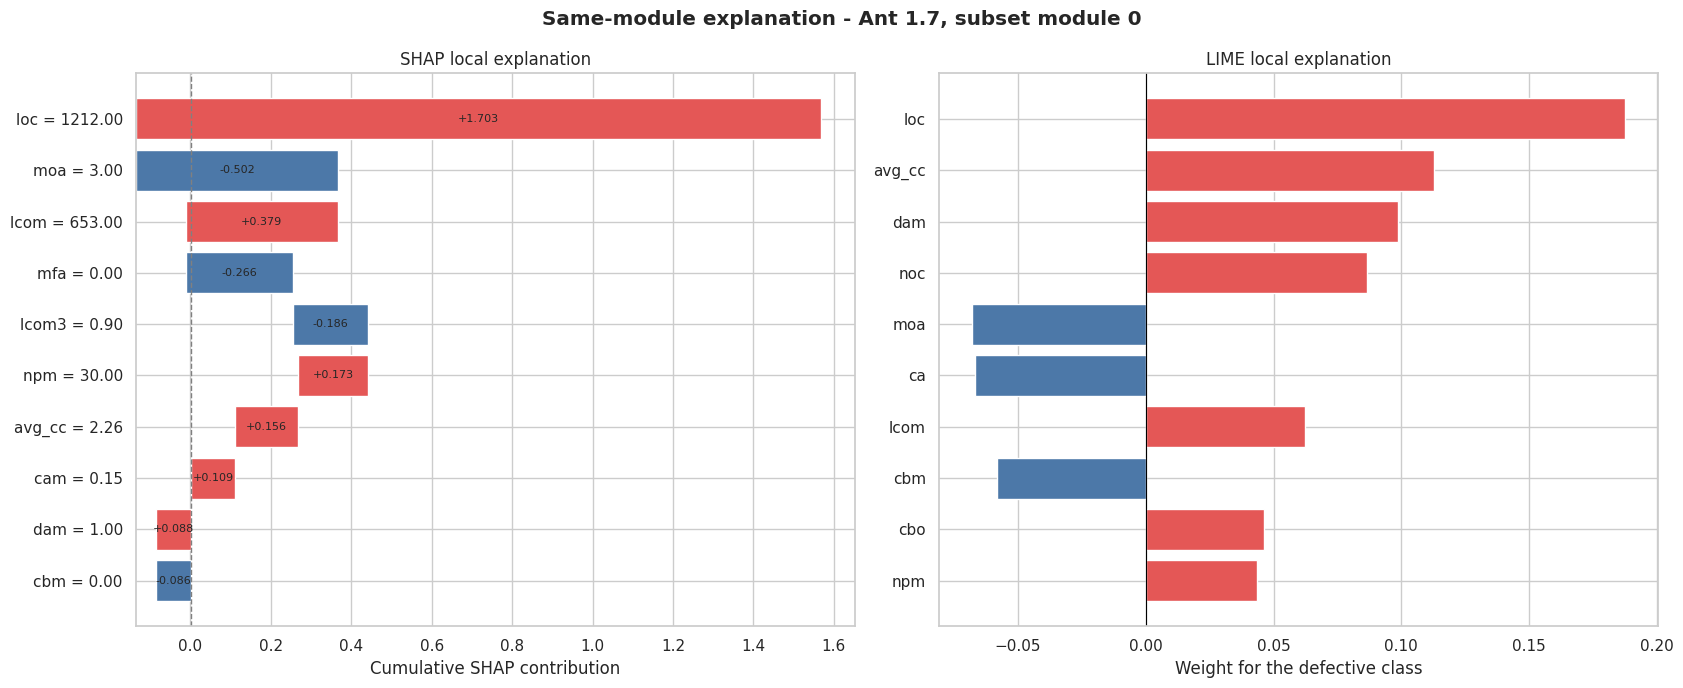

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ2_Selected_Local_LIME_Explanation.csv


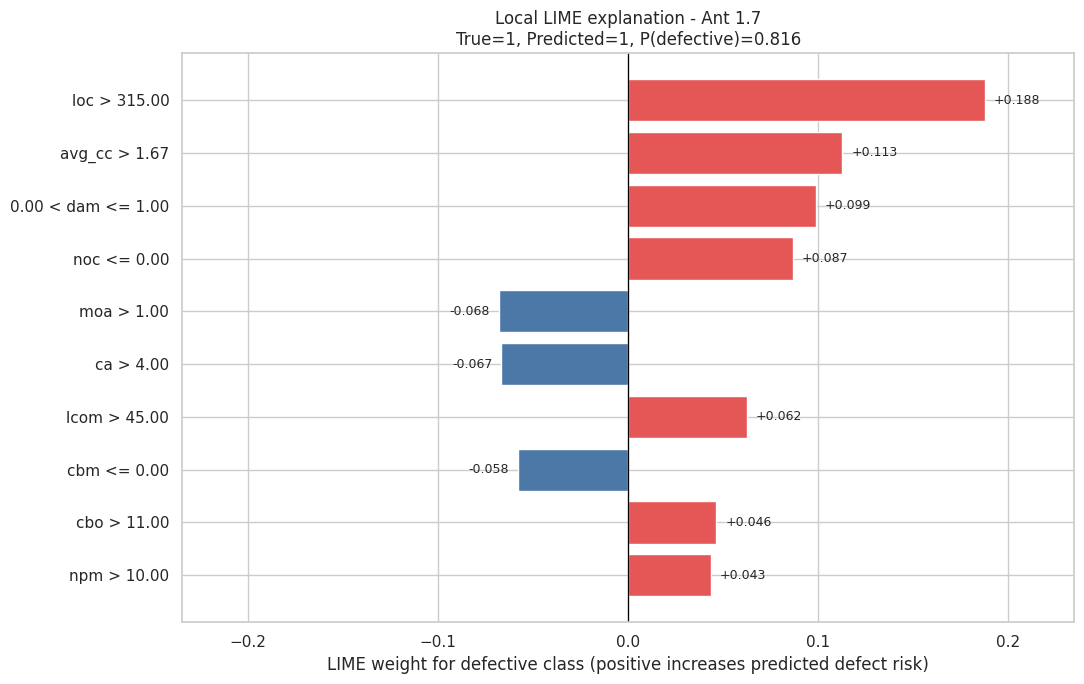

,LIME condition,LIME weight,Absolute weight,Dataset,Subset position,Test position,True class,Predicted class,Defective probability
0,loc > 315.00,0.1876,0.1876,Ant 1.7,0,14,1,1,0.8158
1,avg_cc > 1.67,0.1127,0.1127,Ant 1.7,0,14,1,1,0.8158
2,0.00 < dam <= 1.00,0.0987,0.0987,Ant 1.7,0,14,1,1,0.8158
3,noc <= 0.00,0.0867,0.0867,Ant 1.7,0,14,1,1,0.8158
4,moa > 1.00,-0.0681,0.0681,Ant 1.7,0,14,1,1,0.8158
5,ca > 4.00,-0.0667,0.0667,Ant 1.7,0,14,1,1,0.8158
6,lcom > 45.00,0.0622,0.0622,Ant 1.7,0,14,1,1,0.8158
7,cbm <= 0.00,-0.0582,0.0582,Ant 1.7,0,14,1,1,0.8158
8,cbo > 11.00,0.0464,0.0464,Ant 1.7,0,14,1,1,0.8158
9,npm > 10.00,0.0435,0.0435,Ant 1.7,0,14,1,1,0.8158


In [65]:
def draw_shap_waterfall(ax, base_value, contributions, feature_values, max_display=10):
    series = pd.Series(contributions, index=final_feature_cols)
    chosen = list(reversed(series.abs().nlargest(max_display).index.tolist()))
    current = float(base_value)
    for y, feature in enumerate(chosen):
        contribution = float(series[feature])
        next_value = current + contribution
        left = min(current, next_value)
        ax.barh(
            y,
            abs(contribution),
            left=left,
            color="#E45756" if contribution > 0 else "#4C78A8",
        )
        ax.text(
            left + abs(contribution) / 2,
            y,
            f"{contribution:+.3f}",
            ha="center",
            va="center",
            fontsize=8,
        )
        current = next_value
    labels = [f"{f} = {feature_values[f]:.2f}" for f in chosen]
    ax.set_yticks(range(len(chosen)), labels)
    ax.axvline(float(base_value), ls="--", lw=1, color="grey")
    ax.set_xlabel("Cumulative SHAP contribution")
    ax.set_title("SHAP local explanation")


dataset_name = REPRESENTATIVE_DATASET
split = splits[dataset_name]
positions = fixed_positions[dataset_name]
y_true = split["y_test"].iloc[positions].to_numpy()
y_pred = (
    prediction_store[(dataset_name, "SMOTE")][positions] >= 0.5
).astype(int)
tp_candidates = np.where((y_true == 1) & (y_pred == 1))[0]
subset_position = int(tp_candidates[0]) if len(tp_candidates) else 0
feature_values = split["X_test"].iloc[positions[subset_position]][final_feature_cols]
shap_contrib = rq2_subset_shap_values[dataset_name][subset_position]
base_value = rq2_subset_shap_bases[dataset_name][subset_position]
lime_series = pd.Series(
    rq2_lime_weights[dataset_name][subset_position],
    index=final_feature_cols,
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
draw_shap_waterfall(
    axes[0], base_value, shap_contrib, feature_values
)
lime_top = lime_series.reindex(
    lime_series.abs().sort_values().tail(10).index
)
axes[1].barh(
    lime_top.index,
    lime_top.values,
    color=np.where(lime_top.values >= 0, "#E45756", "#4C78A8"),
)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set(
    title="LIME local explanation",
    xlabel="Weight for the defective class",
)
fig.suptitle(
    f"Same-module explanation - {dataset_name}, "
    f"subset module {subset_position}",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "Figure_4_9_SHAP_LIME_Same_Module.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# standalone native LIME explanation for the same module.
# Replaying the preceding instances reproduces the explainer's RNG state used
# when rq2_lime_weights was generated, so the displayed explanation matches the
# corresponding row in the fixed 50-module analysis.
def reproduce_lime_explanation(
    fitted_pipeline,
    X_train,
    X_explain,
    position,
    seed,
):
    training_array = X_train[final_feature_cols].to_numpy(dtype=float)
    explainer = LimeTabularExplainer(
        training_data=training_array,
        feature_names=final_feature_cols,
        class_names=["Non-defective", "Defective"],
        mode="classification",
        discretize_continuous=True,
        random_state=seed,
    )

    def predict_array(array):
        frame = pd.DataFrame(array, columns=final_feature_cols)
        return fitted_pipeline.predict_proba(frame)

    explanation = None
    explain_array = X_explain[final_feature_cols].to_numpy(dtype=float)
    for array in explain_array[: position + 1]:
        explanation = explainer.explain_instance(
            array,
            predict_array,
            labels=(1,),
            num_features=len(final_feature_cols),
            num_samples=N_LIME_SAMPLES,
        )
    return explanation


X_fixed = split["X_test"].iloc[positions][final_feature_cols]
local_lime_explanation = reproduce_lime_explanation(
    fitted_models[(dataset_name, "SMOTE")],
    split["X_train"],
    X_fixed,
    subset_position,
    XAI_SEED,
)
lime_rule_table = pd.DataFrame(
    local_lime_explanation.as_list(label=1),
    columns=["LIME condition", "LIME weight"],
)
lime_rule_table["Absolute weight"] = lime_rule_table["LIME weight"].abs()
lime_rule_table["Dataset"] = dataset_name
lime_rule_table["Subset position"] = subset_position
lime_rule_table["Test position"] = int(positions[subset_position])
lime_rule_table["True class"] = int(y_true[subset_position])
lime_rule_table["Predicted class"] = int(y_pred[subset_position])
lime_rule_table["Defective probability"] = float(
    prediction_store[(dataset_name, "SMOTE")][positions[subset_position]]
)
save_table(
    lime_rule_table,
    "Appendix_RQ2_Selected_Local_LIME_Explanation.csv",
    folder=APPENDIX_DIR,
)

lime_top_rules = (
    lime_rule_table.nlargest(10, "Absolute weight")
    .sort_values("Absolute weight")
)
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    lime_top_rules["LIME condition"],
    lime_top_rules["LIME weight"],
    color=np.where(
        lime_top_rules["LIME weight"] >= 0,
        "#E45756",
        "#4C78A8",
    ),
)
ax.axvline(0, color="black", linewidth=0.9)
max_abs_weight = max(lime_top_rules["Absolute weight"].max(), 1e-6)
for bar, weight in zip(bars, lime_top_rules["LIME weight"]):
    ax.text(
        weight + (0.025 * max_abs_weight if weight >= 0 else -0.025 * max_abs_weight),
        bar.get_y() + bar.get_height() / 2,
        f"{weight:+.3f}",
        ha="left" if weight >= 0 else "right",
        va="center",
        fontsize=9,
    )
ax.set_xlim(-1.25 * max_abs_weight, 1.25 * max_abs_weight)
ax.set_xlabel(
    "LIME weight for defective class "
    "(positive increases predicted defect risk)"
)
local_probability = lime_rule_table["Defective probability"].iloc[0]
ax.set_title(
    f"Local LIME explanation - {dataset_name}\n"
    f"True={int(y_true[subset_position])}, "
    f"Predicted={int(y_pred[subset_position])}, "
    f"P(defective)={local_probability:.3f}"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "Figure_4_10_Local_LIME_Explanation.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
display(
    lime_rule_table.sort_values("Absolute weight", ascending=False)
    .head(10)
    .round(4)
)

Aggregated LIME importance should not replace the full-test SHAP importance used in RQ2. Table 4.9 and Figure 4.8 present the aggregated LIME importance over the fixed 50-module subset. Table 4.10 quantifies complete-rank and top-k agreement, while Table 4.11 shows the two top-five lists side by side. Kendall's tau evaluates the complete ranking, whereas Jaccard similarity evaluates membership of the leading feature set.

The executed results show the strongest rank agreement for Log4j (tau=0.767) and Poi (tau=0.750), while Ant has the weakest agreement (tau=0.400; top-five Jaccard=0.250). Log4j has a top-five Jaccard of 1.000 even though Table 4.11 shows no same-position matches: both methods selected exactly the same five features but ordered them differently. This demonstrates why both set overlap and ranking agreement are necessary.

Table 4.12 is not the complete LIME output; it summarises the leading aggregated LIME features by prediction outcome. Figure 4.9 compares SHAP and LIME for the same test module, while Figure 4.10 presents the corresponding native local LIME explanation.


## 10. Explanation stability across 20 seeds — RQ3

### 10.1 Repeated-run experimental setup


In [66]:
STABILITY_CONDITION = "SMOTE"

GLOBAL_CHECKPOINT = CHECKPOINT_DIR / "rq3_smote_global_rankings.csv"
LOCAL_CHECKPOINT = CHECKPOINT_DIR / "rq3_smote_lime_instance_rankings.csv"
PREDICTION_CHECKPOINT = CHECKPOINT_DIR / "rq3_smote_seed_predictions.csv"

LEGACY_GLOBAL = LEGACY_CHECKPOINT_DIR / "rq4_smote_global_rankings.csv"
LEGACY_LOCAL = LEGACY_CHECKPOINT_DIR / "rq4_smote_lime_instance_rankings.csv"
LEGACY_PREDICTIONS = LEGACY_CHECKPOINT_DIR / "rq4_smote_seed_predictions.csv"
OLDER_LEGACY_GLOBAL = LEGACY_CHECKPOINT_DIR / "rq4_global_rankings.csv"
OLDER_LEGACY_LOCAL = LEGACY_CHECKPOINT_DIR / "rq4_lime_instance_rankings.csv"
OLDER_LEGACY_PREDICTIONS = LEGACY_CHECKPOINT_DIR / "rq4_seed_predictions.csv"


def load_smote_checkpoint(*candidate_paths):
    source = next((path for path in candidate_paths if path.exists()), None)
    if source is None:
        return pd.DataFrame()
    frame = pd.read_csv(source)
    if "Condition" in frame.columns:
        frame = frame[frame["Condition"] == STABILITY_CONDITION].copy()
    return frame.reset_index(drop=True)


stability_global = load_smote_checkpoint(
    GLOBAL_CHECKPOINT, LEGACY_GLOBAL, OLDER_LEGACY_GLOBAL
)
stability_local = load_smote_checkpoint(
    LOCAL_CHECKPOINT, LEGACY_LOCAL, OLDER_LEGACY_LOCAL
)
stability_predictions = load_smote_checkpoint(
    PREDICTION_CHECKPOINT, LEGACY_PREDICTIONS, OLDER_LEGACY_PREDICTIONS
)

# Save the filtered SMOTE checkpoints immediately so subsequent sessions do not
# need the legacy Original-versus-SMOTE files.
if not stability_global.empty:
    stability_global.to_csv(GLOBAL_CHECKPOINT, index=False)
if not stability_local.empty:
    stability_local.to_csv(LOCAL_CHECKPOINT, index=False)
if not stability_predictions.empty:
    stability_predictions.to_csv(PREDICTION_CHECKPOINT, index=False)


def complete_keys():
    if (
        stability_global.empty
        or stability_local.empty
        or stability_predictions.empty
    ):
        return set()
    global_counts = stability_global.groupby(
        ["Dataset", "Condition", "Seed"]
    )["Method"].nunique()
    local_counts = stability_local.groupby(
        ["Dataset", "Condition", "Seed"]
    ).size()
    prediction_counts = stability_predictions.groupby(
        ["Dataset", "Condition", "Seed"]
    ).size()
    return {
        key
        for key, count in global_counts.items()
        if count == 2
        and local_counts.get(key, 0) == N_EXPLAIN
        and prediction_counts.get(key, 0) == len(splits[key[0]]["y_test"])
    }


completed_stability = complete_keys()
print(
    f"Complete SMOTE runs already available: "
    f"{len(completed_stability)} / {len(DATASET_ORDER) * len(STABILITY_SEEDS)}"
)

Complete SMOTE runs already available: 100 / 100


In [67]:
for dataset_name in DATASET_ORDER:
    split = splits[dataset_name]
    X_fixed = split["X_test"].iloc[fixed_positions[dataset_name]]
    condition = STABILITY_CONDITION
    cv_row = cv_results.query(
        "Dataset == @dataset_name and Condition == @condition "
        "and Model == @CHAMPION_MODEL"
    ).iloc[0]
    best_params = json.loads(cv_row["Best Params"])

    for seed in STABILITY_SEEDS:
        key = (dataset_name, condition, seed)
        if key in completed_stability:
            print("Already complete:", key)
            continue

        print("\nRQ3 SMOTE run:", key)
        for frame_name in [
            "stability_global", "stability_local", "stability_predictions"
        ]:
            frame = globals()[frame_name]
            if frame.empty:
                continue
            mask = (
                (frame["Dataset"] == dataset_name)
                & (frame["Condition"] == condition)
                & (frame["Seed"] == seed)
            )
            globals()[frame_name] = frame.loc[~mask].copy()

        model = build_pipeline(CHAMPION_MODEL, condition, seed)
        model.set_params(**best_params)
        model.set_params(smote__random_state=seed)
        if "random_state" in model.named_steps["model"].get_params():
            model.set_params(model__random_state=seed)

        model.fit(split["X_train"], split["y_train"])
        test_probability = model.predict_proba(split["X_test"])[:, 1]
        test_auc = roc_auc_score(split["y_test"], test_probability)

        shap_started = time.perf_counter()
        shap_values, _, _ = positive_class_shap(
            model, split["X_train"], X_fixed
        )
        shap_seconds = time.perf_counter() - shap_started
        shap_rank = importance_ranks(
            pd.Series(
                np.abs(shap_values).mean(axis=0),
                index=final_feature_cols,
            )
        )

        lime_started = time.perf_counter()
        lime_weights = lime_weights_for_instances(
            model,
            split["X_train"],
            X_fixed,
            seed=seed,
        )
        lime_seconds = time.perf_counter() - lime_started
        lime_rank = importance_ranks(
            pd.Series(
                np.abs(lime_weights).mean(axis=0),
                index=final_feature_cols,
            )
        )

        global_rows = []
        for method, ranks, seconds in [
            ("SHAP", shap_rank, shap_seconds),
            ("LIME", lime_rank, lime_seconds),
        ]:
            row = {
                "Dataset": dataset_name,
                "Condition": condition,
                "Seed": seed,
                "Method": method,
                "ROC-AUC": test_auc,
                "Explanation seconds": seconds,
            }
            row.update({
                f"rank__{f}": int(ranks[f]) for f in final_feature_cols
            })
            global_rows.append(row)

        local_ranks = pd.DataFrame(
            np.abs(lime_weights), columns=final_feature_cols
        ).rank(axis=1, ascending=False, method="first").astype(int)
        local_rows = []
        for subset_position, rank_row in local_ranks.iterrows():
            row = {
                "Dataset": dataset_name,
                "Condition": condition,
                "Seed": seed,
                "Subset position": int(subset_position),
            }
            row.update({
                f"rank__{f}": int(rank_row[f]) for f in final_feature_cols
            })
            local_rows.append(row)

        prediction_rows = pd.DataFrame({
            "Dataset": dataset_name,
            "Condition": condition,
            "Seed": seed,
            "Test position": np.arange(len(split["y_test"])),
            "True class": split["y_test"].to_numpy(),
            "Probability": test_probability,
        })

        stability_global = pd.concat(
            [stability_global, pd.DataFrame(global_rows)], ignore_index=True
        )
        stability_local = pd.concat(
            [stability_local, pd.DataFrame(local_rows)], ignore_index=True
        )
        stability_predictions = pd.concat(
            [stability_predictions, prediction_rows], ignore_index=True
        )
        stability_global.to_csv(GLOBAL_CHECKPOINT, index=False)
        stability_local.to_csv(LOCAL_CHECKPOINT, index=False)
        stability_predictions.to_csv(PREDICTION_CHECKPOINT, index=False)
        completed_stability.add(key)
        print(
            f"AUC={test_auc:.3f}; SHAP={shap_seconds:.1f}s; "
            f"LIME={lime_seconds:.1f}s; checkpoint saved."
        )

print(
    "SMOTE runs complete:",
    len(completed_stability),
    "/",
    len(DATASET_ORDER) * len(STABILITY_SEEDS),
)

Already complete: ('Poi 3.0', 'SMOTE', 0)
Already complete: ('Poi 3.0', 'SMOTE', 1)
Already complete: ('Poi 3.0', 'SMOTE', 2)
Already complete: ('Poi 3.0', 'SMOTE', 3)
Already complete: ('Poi 3.0', 'SMOTE', 4)
Already complete: ('Poi 3.0', 'SMOTE', 5)
Already complete: ('Poi 3.0', 'SMOTE', 6)
Already complete: ('Poi 3.0', 'SMOTE', 7)
Already complete: ('Poi 3.0', 'SMOTE', 8)
Already complete: ('Poi 3.0', 'SMOTE', 9)
Already complete: ('Poi 3.0', 'SMOTE', 10)
Already complete: ('Poi 3.0', 'SMOTE', 11)
Already complete: ('Poi 3.0', 'SMOTE', 12)
Already complete: ('Poi 3.0', 'SMOTE', 13)
Already complete: ('Poi 3.0', 'SMOTE', 14)
Already complete: ('Poi 3.0', 'SMOTE', 15)
Already complete: ('Poi 3.0', 'SMOTE', 16)
Already complete: ('Poi 3.0', 'SMOTE', 17)
Already complete: ('Poi 3.0', 'SMOTE', 18)
Already complete: ('Poi 3.0', 'SMOTE', 19)
Already complete: ('Ant 1.7', 'SMOTE', 0)
Already complete: ('Ant 1.7', 'SMOTE', 1)
Already complete: ('Ant 1.7', 'SMOTE', 2)
Already complete: ('Ant 

### 10.2 Model performance and seed-sensitivity checks


In [68]:
auc_by_seed = stability_global.drop_duplicates(
    ["Dataset", "Condition", "Seed"]
)
table_4_13 = (
    auc_by_seed.groupby("Dataset")["ROC-AUC"]
    .agg(**{
        "ROC-AUC min": "min",
        "Median": "median",
        "ROC-AUC max": "max",
    })
    .reset_index()
)
table_4_13["Range"] = table_4_13["ROC-AUC max"] - table_4_13["ROC-AUC min"]
save_table(table_4_13, "Table_4_13_SMOTE_Model_Performance_Stability.csv")

seed_check_rows = []
for dataset_name in DATASET_ORDER:
    part = stability_predictions[
        stability_predictions["Dataset"] == dataset_name
    ]
    probability_matrix = part.pivot(
        index="Test position", columns="Seed", values="Probability"
    ).sort_index(axis=1)
    reference = probability_matrix.iloc[:, 0]
    max_difference = probability_matrix.subtract(reference, axis=0).abs().to_numpy().max()
    seed_check_rows.append({
        "Dataset": dataset_name,
        "Reference seed": int(probability_matrix.columns[0]),
        "Seeds compared": probability_matrix.shape[1],
        "Maximum absolute probability difference": max_difference,
        "Empirical result": "Seed-sensitive" if max_difference > 1e-12 else "Deterministic",
    })
table_4_14 = pd.DataFrame(seed_check_rows)
save_table(
    table_4_14,
    "Table_4_14_SMOTE_Seed_Sensitivity_Check.csv",
)
display(table_4_13.round(3))
display(table_4_14)

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_13_SMOTE_Model_Performance_Stability.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_14_SMOTE_Seed_Sensitivity_Check.csv


,Dataset,ROC-AUC min,Median,ROC-AUC max,Range
0,Ant 1.7,0.793,0.810,0.834,0.042
1,Camel 1.6,0.667,0.679,0.703,0.036
2,Log4j 1.2,0.863,0.893,0.926,0.063
3,Poi 3.0,0.879,0.889,0.895,0.017
4,Xalan 2.7,0.904,0.922,0.941,0.037


,Dataset,Reference seed,Seeds compared,Maximum absolute probability difference,Empirical result
0,Poi 3.0,0,20,0.393372,Seed-sensitive
1,Ant 1.7,0,20,0.459753,Seed-sensitive
2,Camel 1.6,0,20,0.444332,Seed-sensitive
3,Log4j 1.2,0,20,0.375184,Seed-sensitive
4,Xalan 2.7,0,20,0.045452,Seed-sensitive


### 10.3 Overall SHAP and LIME stability under SMOTE


In [69]:
rank_columns = [f"rank__{f}" for f in final_feature_cols]


def stability_summary(method):
    rows = []
    for dataset_name in DATASET_ORDER:
        part = stability_global.query(
            "Dataset == @dataset_name and Method == @method"
        ).sort_values("Seed")
        ranks = part[rank_columns].copy()
        ranks.columns = final_feature_cols
        all_w = kendalls_w(ranks.to_numpy())
        mean_rank = ranks.mean(axis=0).sort_values()
        top_features = mean_rank.index[:5].tolist()
        mid_features = mean_rank.index[5:11].tolist()
        top_w = subset_w(ranks, top_features)
        mid_w = subset_w(ranks, mid_features)
        rows.append({
            "Dataset": dataset_name,
            "W (all 16)": all_w[0],
            "chi-square": all_w[1],
            "df": all_w[2],
            "p": all_w[3],
            "W (top 5)": top_w[0],
            "W (mid 6)": mid_w[0],
        })
    out = pd.DataFrame(rows)
    mean_row = {
        "Dataset": "Mean",
        "W (all 16)": out["W (all 16)"].mean(),
        "chi-square": np.nan,
        "df": np.nan,
        "p": np.nan,
        "W (top 5)": out["W (top 5)"].mean(),
        "W (mid 6)": out["W (mid 6)"].mean(),
    }
    return pd.concat([out, pd.DataFrame([mean_row])], ignore_index=True)


table_4_15 = stability_summary("SHAP")
table_4_16 = stability_summary("LIME")
save_table(table_4_15, "Table_4_15_SHAP_Stability_SMOTE.csv")
save_table(table_4_16, "Table_4_16_LIME_Stability_SMOTE.csv")

stability_lookup = {}
for method, table in [("SHAP", table_4_15), ("LIME", table_4_16)]:
    for _, row in table[table["Dataset"] != "Mean"].iterrows():
        stability_lookup[(row["Dataset"], method)] = row["W (all 16)"]

overlap_rows = []
for (dataset_name, method), part in stability_global.groupby(
    ["Dataset", "Method"]
):
    ranks = part.sort_values("Seed")[rank_columns].copy()
    ranks.columns = final_feature_cols
    jaccards = []
    agreements = []
    for i, j in combinations(range(len(ranks)), 2):
        jaccards.append(top_k_jaccard(ranks.iloc[i], ranks.iloc[j], 5))
        agreements.append(
            top_k_feature_agreement(ranks.iloc[i], ranks.iloc[j], 5)
        )
    overlap_rows.append({
        "Dataset": dataset_name,
        "Method": method,
        "Mean pairwise top-5 Jaccard": np.mean(jaccards),
        "Mean pairwise FA@5": np.mean(agreements),
    })
save_table(
    pd.DataFrame(overlap_rows),
    "Appendix_RQ3_SMOTE_Top5_Overlap.csv",
    folder=APPENDIX_DIR,
)
display(table_4_15.round(3))
display(table_4_16.round(3))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_15_SHAP_Stability_SMOTE.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_16_LIME_Stability_SMOTE.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_SMOTE_Top5_Overlap.csv


,Dataset,W (all 16),chi-square,df,p,W (top 5),W (mid 6)
0,Poi 3.0,0.967,290.043,15.0,0.0,0.898,0.736
1,Ant 1.7,0.862,258.732,15.0,0.0,0.554,0.493
2,Camel 1.6,0.909,272.603,15.0,0.0,0.800,0.673
3,Log4j 1.2,0.963,288.953,15.0,0.0,0.884,0.677
4,Xalan 2.7,0.986,295.774,15.0,0.0,0.942,0.926
5,Mean,0.937,NaN,NaN,NaN,0.816,0.701


,Dataset,W (all 16),chi-square,df,p,W (top 5),W (mid 6)
0,Poi 3.0,0.924,277.249,15.0,0.0,0.704,0.356
1,Ant 1.7,0.880,263.907,15.0,0.0,0.716,0.486
2,Camel 1.6,0.772,231.662,15.0,0.0,0.722,0.411
3,Log4j 1.2,0.942,282.657,15.0,0.0,0.594,0.557
4,Xalan 2.7,0.947,283.976,15.0,0.0,0.930,0.627
5,Mean,0.893,NaN,NaN,NaN,0.733,0.487


Under SMOTE, SHAP produced a higher mean all-feature Kendall's W (0.937) than aggregated LIME (0.893), indicating greater overall ranking repeatability in this experiment. The difference is not universal: LIME is slightly more stable for Ant (0.880 versus SHAP's 0.862). Xalan has the highest SHAP stability (W=0.986), while Ant has the lowest SHAP stability (W=0.862). For LIME, Xalan is also the most stable (W=0.947), whereas Camel is the least stable (W=0.772).

The top-five rankings are more stable than the middle six on average: SHAP records 0.816 versus 0.701, and LIME records 0.733 versus 0.487. The especially low middle-rank LIME agreement indicates that most variation occurs among moderately influential features rather than the dominant predictors. This supports reporting the leading features while avoiding strong interpretation of small changes in middle-ranked features.

The model-performance ranges remain limited across seeds (0.017-0.063 ROC-AUC). Log4j has the widest range (0.063), whereas Poi has the narrowest (0.017). Explanation differences should therefore be interpreted alongside Table 4.13, particularly for Log4j.

### 10.4 Most- and least-stable SHAP cases


Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_17_Selected_SHAP_Stability_Cases.csv


,Selection,Dataset,Condition,Kendall's W,Minority %
0,Most stable SHAP,Xalan 2.7,SMOTE,0.986,1.210
1,Least stable SHAP,Ant 1.7,SMOTE,0.862,22.282


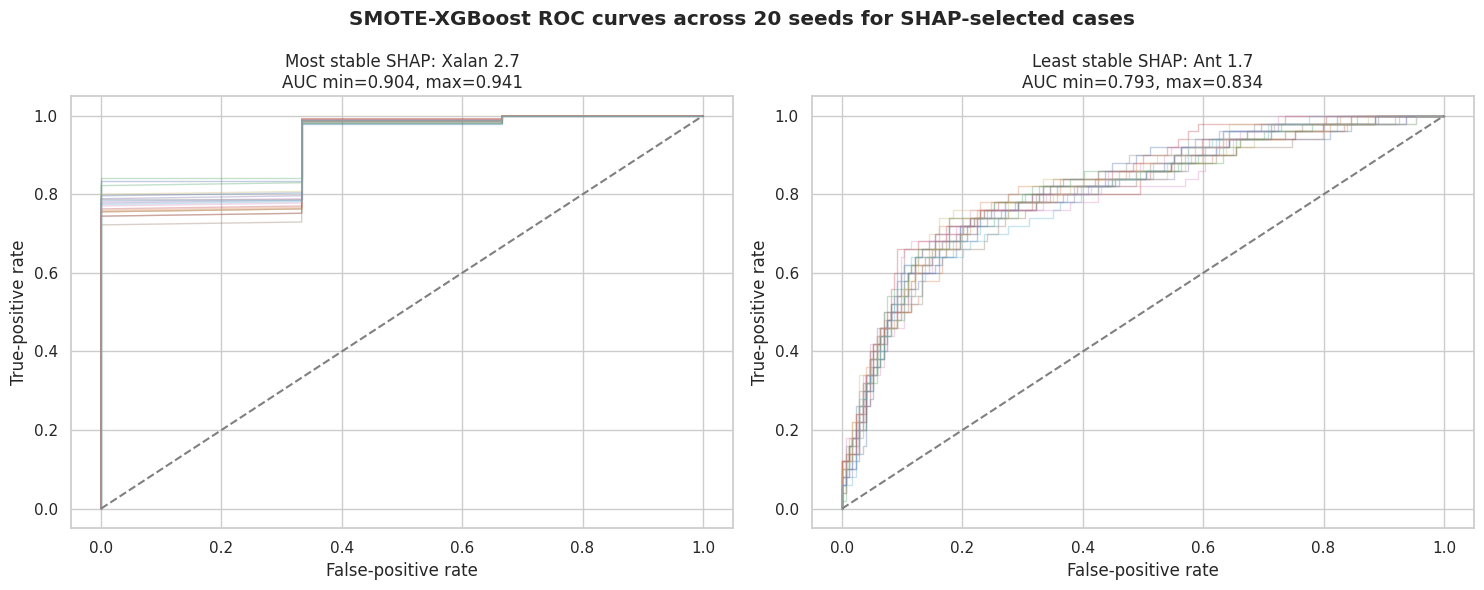

In [70]:
shap_cases = pd.DataFrame([
    {
        "Dataset": dataset_name,
        "Condition": STABILITY_CONDITION,
        "Kendall's W": stability_lookup[(dataset_name, "SHAP")],
        "Minority %": minority_lookup[dataset_name],
    }
    for dataset_name in DATASET_ORDER
])
most_shap = shap_cases.loc[shap_cases["Kendall's W"].idxmax()].to_dict()
least_shap = shap_cases.loc[shap_cases["Kendall's W"].idxmin()].to_dict()
table_4_17 = pd.DataFrame([
    {"Selection": "Most stable SHAP", **most_shap},
    {"Selection": "Least stable SHAP", **least_shap},
])
save_table(table_4_17, "Table_4_17_Selected_SHAP_Stability_Cases.csv")
display(table_4_17.round(3))

# Figure 4.11 — ROC curves across 20 seeds for both selected cases
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, label, case in zip(
    axes, ["Most stable SHAP", "Least stable SHAP"], [most_shap, least_shap]
):
    dataset_name = case["Dataset"]
    pred_part = stability_predictions[
        stability_predictions["Dataset"] == dataset_name
    ]
    auc_values = []
    for seed, part in pred_part.groupby("Seed"):
        part = part.sort_values("Test position")
        fpr, tpr, _ = roc_curve(part["True class"], part["Probability"])
        auc = roc_auc_score(part["True class"], part["Probability"])
        auc_values.append(auc)
        ax.plot(fpr, tpr, alpha=0.35, lw=1)
    ax.plot([0, 1], [0, 1], "--", color="grey")
    ax.set_title(
        f"{label}: {dataset_name}\n"
        f"AUC min={min(auc_values):.3f}, max={max(auc_values):.3f}"
    )
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
fig.suptitle(
    "SMOTE-XGBoost ROC curves across 20 seeds for SHAP-selected cases",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "Figure_4_11_ROC_20_Seeds_SHAP_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

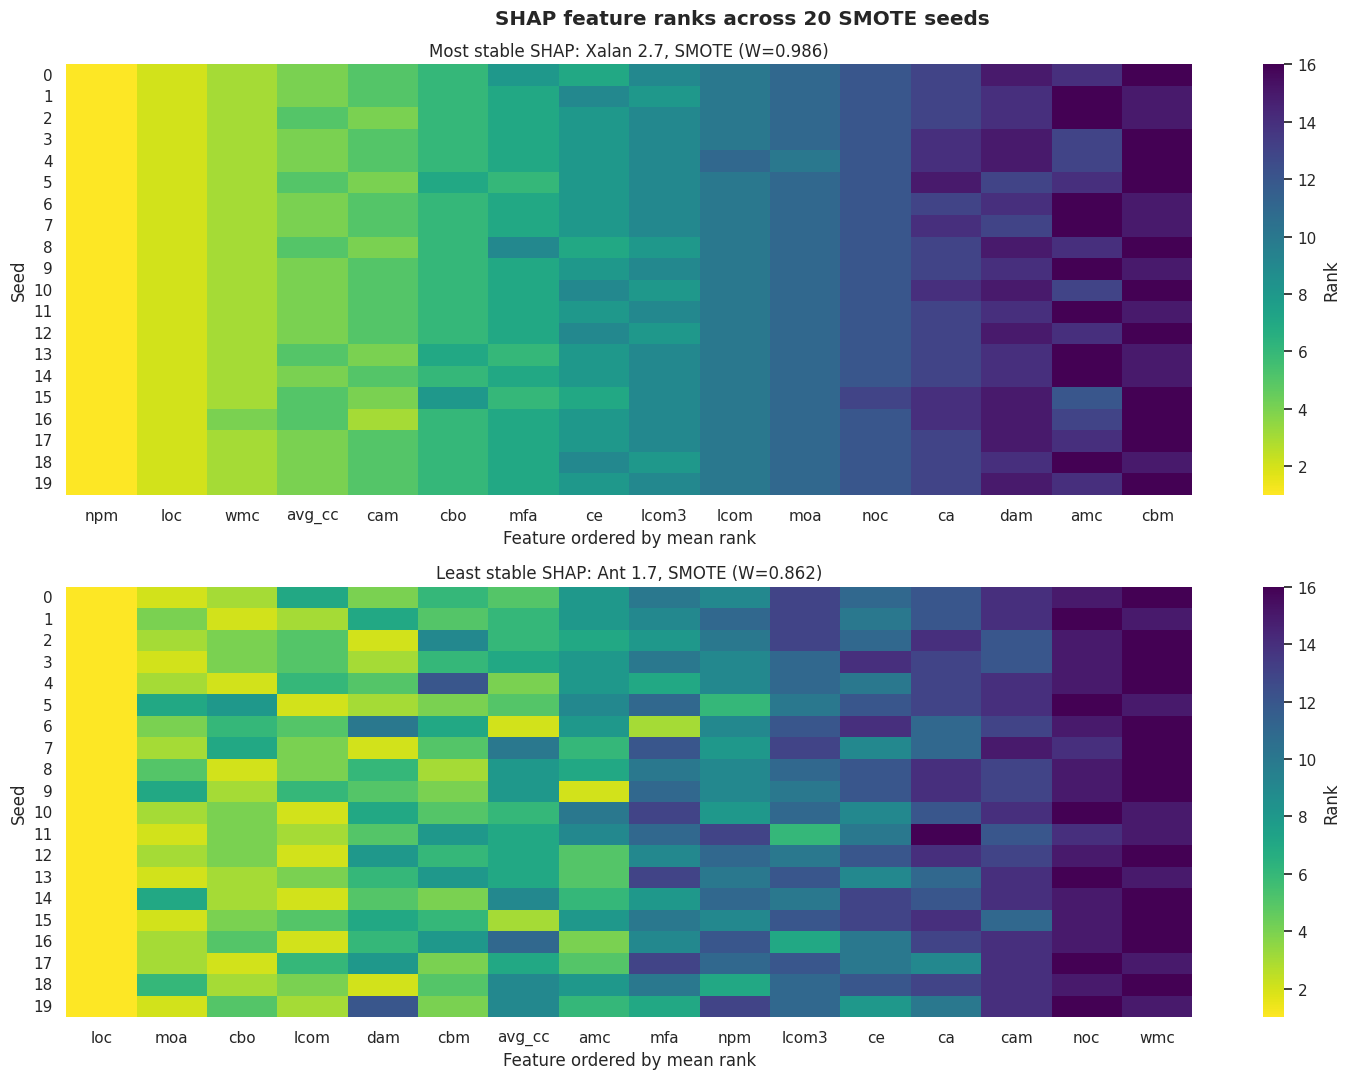

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_18_Most_Stable_SHAP_Top5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_19_Most_Stable_SHAP_Bottom5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_20_Least_Stable_SHAP_Top5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_21_Least_Stable_SHAP_Bottom5_Rank_Frequencies.csv


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Most stable SHAP,Xalan 2.7,Five highest-importance features,npm,1,20
1,Most stable SHAP,Xalan 2.7,Five highest-importance features,loc,2,20
2,Most stable SHAP,Xalan 2.7,Five highest-importance features,wmc,3,19
3,Most stable SHAP,Xalan 2.7,Five highest-importance features,wmc,4,1
4,Most stable SHAP,Xalan 2.7,Five highest-importance features,avg_cc,4,14
5,Most stable SHAP,Xalan 2.7,Five highest-importance features,avg_cc,5,6
6,Most stable SHAP,Xalan 2.7,Five highest-importance features,cam,3,1
7,Most stable SHAP,Xalan 2.7,Five highest-importance features,cam,4,5
8,Most stable SHAP,Xalan 2.7,Five highest-importance features,cam,5,14


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Most stable SHAP,Xalan 2.7,Five lowest-importance features,noc,12,19
1,Most stable SHAP,Xalan 2.7,Five lowest-importance features,noc,13,1
2,Most stable SHAP,Xalan 2.7,Five lowest-importance features,ca,13,13
3,Most stable SHAP,Xalan 2.7,Five lowest-importance features,ca,14,6
4,Most stable SHAP,Xalan 2.7,Five lowest-importance features,ca,15,1
5,Most stable SHAP,Xalan 2.7,Five lowest-importance features,dam,13,2
6,Most stable SHAP,Xalan 2.7,Five lowest-importance features,dam,14,8
7,Most stable SHAP,Xalan 2.7,Five lowest-importance features,dam,15,10
8,Most stable SHAP,Xalan 2.7,Five lowest-importance features,amc,12,1
9,Most stable SHAP,Xalan 2.7,Five lowest-importance features,amc,13,4


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Least stable SHAP,Ant 1.7,Five highest-importance features,loc,1,20
1,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,2,6
2,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,3,7
3,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,4,2
4,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,5,1
5,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,6,1
6,Least stable SHAP,Ant 1.7,Five highest-importance features,moa,7,3
7,Least stable SHAP,Ant 1.7,Five highest-importance features,cbo,2,4
8,Least stable SHAP,Ant 1.7,Five highest-importance features,cbo,3,5
9,Least stable SHAP,Ant 1.7,Five highest-importance features,cbo,4,6


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,8,1
1,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,9,3
2,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,10,5
3,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,11,2
4,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,12,5
5,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,13,2
6,Least stable SHAP,Ant 1.7,Five lowest-importance features,ce,14,2
7,Least stable SHAP,Ant 1.7,Five lowest-importance features,ca,9,1
8,Least stable SHAP,Ant 1.7,Five lowest-importance features,ca,10,1
9,Least stable SHAP,Ant 1.7,Five lowest-importance features,ca,11,3


In [71]:
def case_rank_frame(case, method="SHAP"):
    case_dataset = case["Dataset"]
    part = stability_global.query(
        "Dataset == @case_dataset and Method == @method"
    ).sort_values("Seed")
    ranks = part[rank_columns].copy()
    ranks.columns = final_feature_cols
    ranks.index = part["Seed"].astype(int)
    return ranks


# Figure 4.12 — SHAP rank heatmaps for both cases
fig, axes = plt.subplots(2, 1, figsize=(15, 11))
for ax, label, case in zip(
    axes, ["Most stable SHAP", "Least stable SHAP"], [most_shap, least_shap]
):
    ranks = case_rank_frame(case)
    case_w = case["Kendall's W"]
    order = ranks.mean().sort_values().index
    sns.heatmap(
        ranks[order],
        cmap="viridis_r",
        vmin=1,
        vmax=len(final_feature_cols),
        ax=ax,
        cbar_kws={"label": "Rank"},
    )
    ax.set_title(
        f"{label}: {case['Dataset']}, SMOTE (W={case_w:.3f})"
    )
    ax.set_xlabel("Feature ordered by mean rank")
    ax.set_ylabel("Seed")
fig.suptitle(
    "SHAP feature ranks across 20 SMOTE seeds",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "Figure_4_12_SHAP_Rank_Heatmaps_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


def rank_frequency_table(ranks, features, selection, dataset_name, group):
    rows = []
    for feature in features:
        counts = ranks[feature].value_counts().sort_index()
        for rank_value, frequency in counts.items():
            rows.append({
                "Selection": selection,
                "Dataset": dataset_name,
                "Feature group": group,
                "Feature": feature,
                "Rank": int(rank_value),
                "Frequency (of 20)": int(frequency),
            })
    return pd.DataFrame(rows)


shap_rank_tables = {}
for selection, case in [("Most stable SHAP", most_shap), ("Least stable SHAP", least_shap)]:
    ranks = case_rank_frame(case)
    mean_rank = ranks.mean().sort_values()
    shap_rank_tables[(selection, "Top 5")] = rank_frequency_table(
        ranks,
        mean_rank.index[:5],
        selection,
        case["Dataset"],
        "Five highest-importance features",
    )
    shap_rank_tables[(selection, "Bottom 5")] = rank_frequency_table(
        ranks,
        mean_rank.index[-5:],
        selection,
        case["Dataset"],
        "Five lowest-importance features",
    )

table_4_18 = shap_rank_tables[("Most stable SHAP", "Top 5")]
table_4_19 = shap_rank_tables[("Most stable SHAP", "Bottom 5")]
table_4_20 = shap_rank_tables[("Least stable SHAP", "Top 5")]
table_4_21 = shap_rank_tables[("Least stable SHAP", "Bottom 5")]

save_table(table_4_18, "Table_4_18_Most_Stable_SHAP_Top5_Rank_Frequencies.csv")
save_table(table_4_19, "Table_4_19_Most_Stable_SHAP_Bottom5_Rank_Frequencies.csv")
save_table(table_4_20, "Table_4_20_Least_Stable_SHAP_Top5_Rank_Frequencies.csv")
save_table(table_4_21, "Table_4_21_Least_Stable_SHAP_Bottom5_Rank_Frequencies.csv")
display(table_4_18)
display(table_4_19)
display(table_4_20)
display(table_4_21)

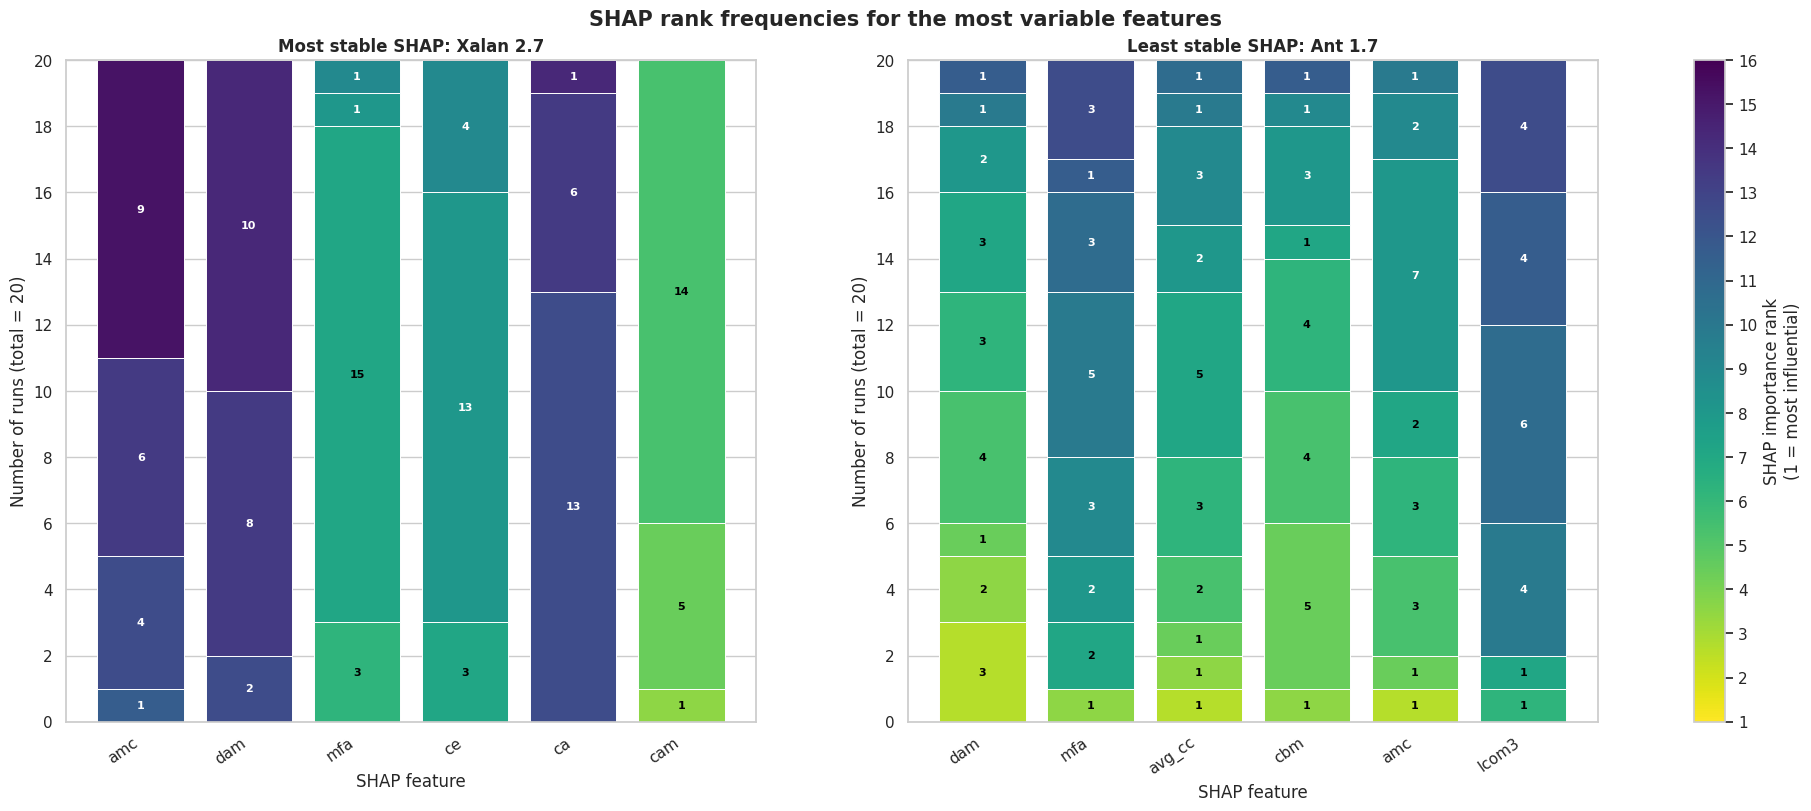

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_SHAP_Rank_Variability_Selected_Cases.csv


PosixPath('/content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_SHAP_Rank_Variability_Selected_Cases.csv')

In [72]:
# Figure 4.13 — vertical rank-frequency distribution for the six most
# variable SHAP features in the most- and least-stable cases.

fig = plt.figure(figsize=(18, 8), constrained_layout=True)

# Two plotting areas plus one separate area for the colour scale
grid = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.045],
    wspace=0.16,
)

axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
]

colour_bar_axes = fig.add_subplot(grid[0, 2])

variability_rows = []

rank_colours = plt.get_cmap("viridis_r")(
    np.linspace(0.05, 0.95, len(final_feature_cols))
)

for ax, selection, case in zip(
    axes,
    ["Most stable SHAP", "Least stable SHAP"],
    [most_shap, least_shap],
):
    ranks = case_rank_frame(case)

    # Identify the six features with the greatest rank variation
    variability = ranks.agg(["mean", "std", "min", "max"]).T
    variability["range"] = (
        variability["max"] - variability["min"]
    )

    variability = variability.sort_values(
        ["std", "range"],
        ascending=False,
    )

    variable_features = variability.index[:6].tolist()

    # Count how frequently each feature received each rank
    frequency = pd.DataFrame(
        {
            feature: ranks[feature].value_counts()
            for feature in variable_features
        }
    ).T.reindex(
        columns=range(1, len(final_feature_cols) + 1),
        fill_value=0,
    )

    frequency = frequency.fillna(0).astype(int)

    x_position = np.arange(len(variable_features))
    bottom = np.zeros(len(variable_features), dtype=int)

    # Create the vertically stacked bars
    for rank_value in range(
        1,
        len(final_feature_cols) + 1,
    ):
        counts = frequency[rank_value].to_numpy()

        bars = ax.bar(
            x_position,
            counts,
            bottom=bottom,
            color=rank_colours[rank_value - 1],
            edgecolor="white",
            linewidth=0.7,
        )

        # Display the frequency inside each segment
        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(int(count)),
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color=(
                        "white"
                        if rank_value >= 8
                        else "black"
                    ),
                )

        bottom += counts

    ax.set_xticks(
        x_position,
        variable_features,
        rotation=35,
        ha="right",
    )

    ax.set_title(
        f"{selection}: {case['Dataset']}",
        fontweight="bold",
    )

    ax.set_xlabel("SHAP feature")
    ax.set_ylabel(
        f"Number of runs (total = {len(ranks)})"
    )

    ax.set_ylim(0, len(ranks))
    ax.yaxis.set_major_locator(
        plt.MaxNLocator(integer=True)
    )

    # Store feature variability statistics
    for feature in final_feature_cols:
        variability_rows.append({
            "Selection": selection,
            "Dataset": case["Dataset"],
            "Feature": feature,
            "Mean rank": ranks[feature].mean(),
            "Rank SD": ranks[feature].std(),
            "Min rank": ranks[feature].min(),
            "Max rank": ranks[feature].max(),
            "Distinct ranks": ranks[feature].nunique(),
        })

# Separate colour scale: it does not overlap either subplot
rank_mapper = plt.cm.ScalarMappable(
    cmap=plt.get_cmap("viridis_r"),
    norm=plt.Normalize(
        vmin=1,
        vmax=len(final_feature_cols),
    ),
)

rank_mapper.set_array([])

colour_bar = fig.colorbar(
    rank_mapper,
    cax=colour_bar_axes,
)

colour_bar.set_label(
    "SHAP importance rank\n"
    "(1 = most influential)"
)

colour_bar.set_ticks(
    range(1, len(final_feature_cols) + 1)
)

fig.suptitle(
    "SHAP rank frequencies for the most variable features",
    fontsize=15,
    fontweight="bold",
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_13_SHAP_Rank_Frequency_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

save_table(
    pd.DataFrame(variability_rows),
    "Appendix_RQ3_SHAP_Rank_Variability_Selected_Cases.csv",
    folder=APPENDIX_DIR,
)

### 10.5 Most- and least-stable LIME cases


In [73]:
lime_cases = pd.DataFrame([
    {
        "Dataset": dataset_name,
        "Condition": STABILITY_CONDITION,
        "Kendall's W": stability_lookup[(dataset_name, "LIME")],
        "Minority %": minority_lookup[dataset_name],
    }
    for dataset_name in DATASET_ORDER
])

most_lime = lime_cases.loc[
    lime_cases["Kendall's W"].idxmax()
].to_dict()

least_lime = lime_cases.loc[
    lime_cases["Kendall's W"].idxmin()
].to_dict()

table_4_22 = pd.DataFrame([
    {
        "Selection": "Most stable LIME",
        **most_lime,
    },
    {
        "Selection": "Least stable LIME",
        **least_lime,
    },
])

save_table(
    table_4_22,
    "Table_4_22_Selected_LIME_Stability_Cases.csv",
)

display(table_4_22.round(3))

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_22_Selected_LIME_Stability_Cases.csv


,Selection,Dataset,Condition,Kendall's W,Minority %
0,Most stable LIME,Xalan 2.7,SMOTE,0.947,1.210
1,Least stable LIME,Camel 1.6,SMOTE,0.772,19.482


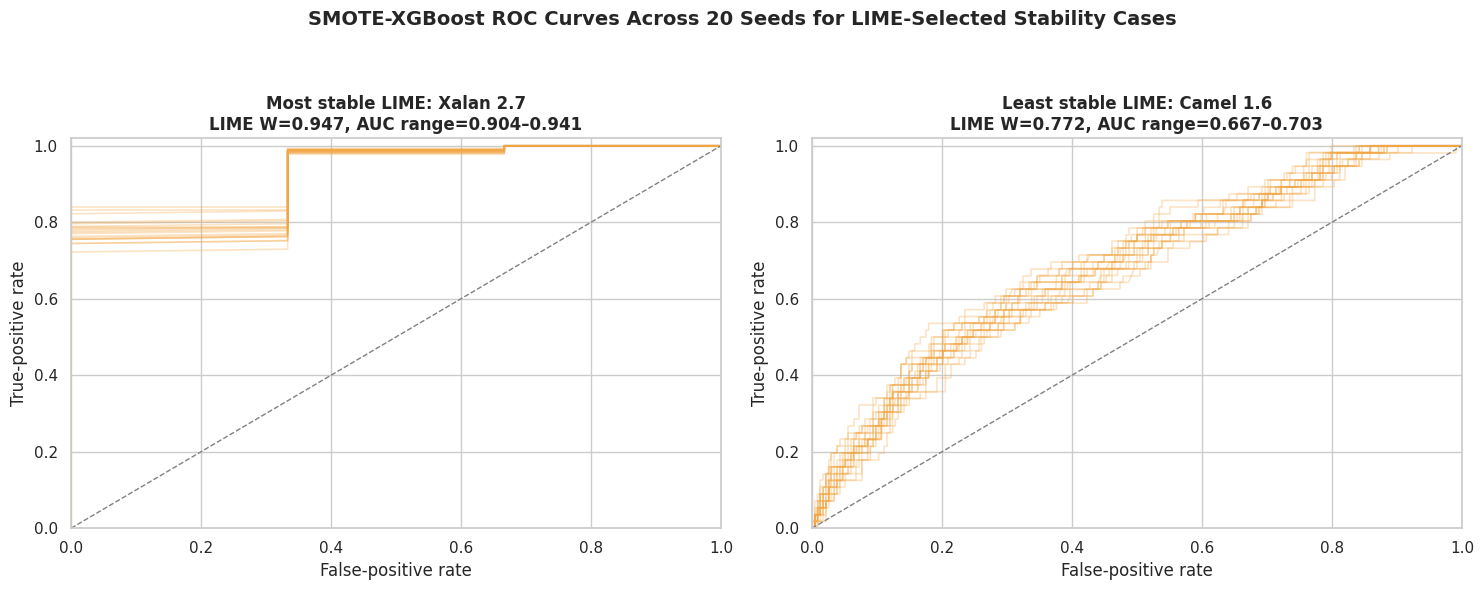

In [74]:
# ROC curves across 20 seeds for the models corresponding
# to the most- and least-stable LIME cases

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

for ax, label, case in zip(
    axes,
    [
        "Most stable LIME",
        "Least stable LIME",
    ],
    [
        most_lime,
        least_lime,
    ],
):
    dataset_name = case["Dataset"]
    case_w = case["Kendall's W"]

    pred_part = stability_predictions[
        (
            stability_predictions["Dataset"]
            == dataset_name
        )
        & (
            stability_predictions["Condition"]
            == STABILITY_CONDITION
        )
    ]

    auc_values = []

    for seed, seed_predictions in pred_part.groupby(
        "Seed"
    ):
        seed_predictions = (
            seed_predictions
            .sort_values("Test position")
        )

        fpr, tpr, _ = roc_curve(
            seed_predictions["True class"],
            seed_predictions["Probability"],
        )

        auc = roc_auc_score(
            seed_predictions["True class"],
            seed_predictions["Probability"],
        )

        auc_values.append(auc)

        ax.plot(
            fpr,
            tpr,
            color="#F2A541",
            alpha=0.30,
            linewidth=1.2,
        )

    # Random-classifier reference
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="grey",
        linewidth=1,
    )

    ax.set_title(
        f"{label}: {dataset_name}\n"
        f"LIME W={case_w:.3f}, "
        f"AUC range={min(auc_values):.3f}–"
        f"{max(auc_values):.3f}",
        fontweight="bold",
    )

    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

fig.suptitle(
    "SMOTE-XGBoost ROC Curves Across 20 Seeds "
    "for LIME-Selected Stability Cases",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(
    rect=[0, 0, 1, 0.93]
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_14_ROC_20_Seeds_LIME_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

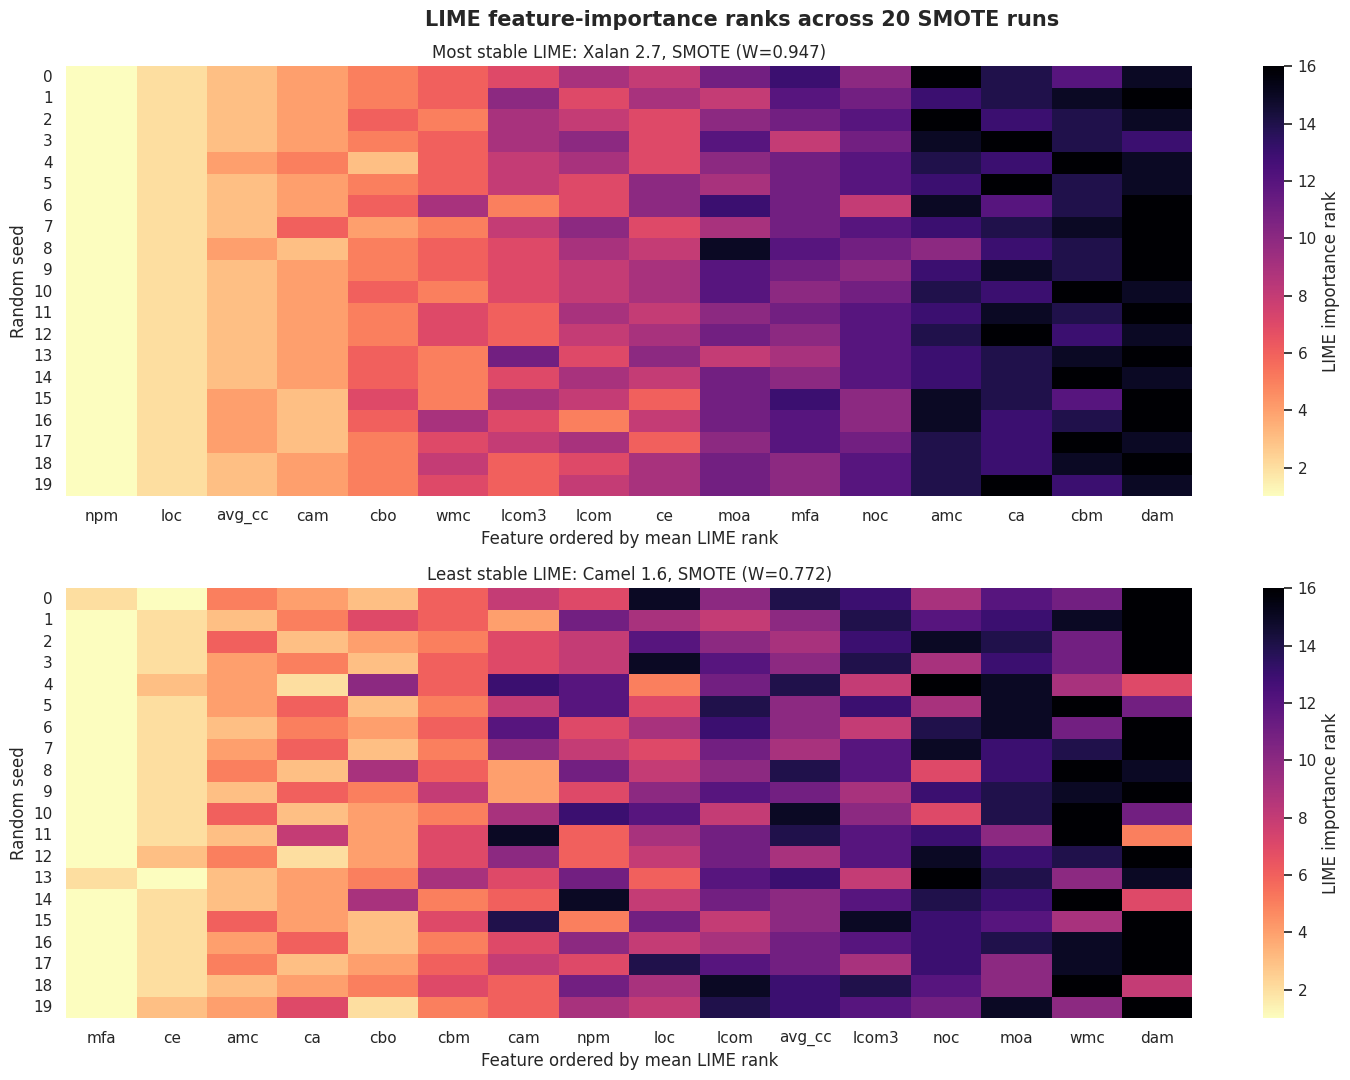

In [75]:
# Figure 4.15 — LIME rank heatmaps for the most- and
# least-stable LIME datasets

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 11),
)

for ax, selection, case in zip(
    axes,
    ["Most stable LIME", "Least stable LIME"],
    [most_lime, least_lime],
):
    ranks = case_rank_frame(
        case,
        method="LIME",
    )
    case_w = case["Kendall's W"]

    # Order features by their mean LIME rank
    feature_order = (
        ranks.mean()
        .sort_values()
        .index
    )

    sns.heatmap(
        ranks[feature_order],
        cmap="magma_r",
        vmin=1,
        vmax=len(final_feature_cols),
        ax=ax,
        cbar_kws={
            "label": "LIME importance rank"
        },
    )

    ax.set_title(
        f"{selection}: {case['Dataset']}, "
        f"SMOTE (W={case_w:.3f})"
    )

    ax.set_xlabel(
        "Feature ordered by mean LIME rank"
    )
    ax.set_ylabel("Random seed")

fig.suptitle(
    "LIME feature-importance ranks across 20 SMOTE runs",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "Figure_4_15_LIME_Rank_Heatmaps_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [76]:
# Tables 4.23–4.26 — rank frequencies for the top and
# bottom LIME features in both selected cases

lime_rank_tables = {}

for selection, case in [
    ("Most stable LIME", most_lime),
    ("Least stable LIME", least_lime),
]:
    ranks = case_rank_frame(
        case,
        method="LIME",
    )

    mean_rank = ranks.mean().sort_values()

    top_features = mean_rank.index[:5].tolist()
    bottom_features = mean_rank.index[-5:].tolist()

    lime_rank_tables[(selection, "Top 5")] = (
        rank_frequency_table(
            ranks,
            top_features,
            selection,
            case["Dataset"],
            "Five highest-importance LIME features",
        )
    )

    lime_rank_tables[(selection, "Bottom 5")] = (
        rank_frequency_table(
            ranks,
            bottom_features,
            selection,
            case["Dataset"],
            "Five lowest-importance LIME features",
        )
    )

table_4_23 = lime_rank_tables[
    ("Most stable LIME", "Top 5")
]

table_4_24 = lime_rank_tables[
    ("Most stable LIME", "Bottom 5")
]

table_4_25 = lime_rank_tables[
    ("Least stable LIME", "Top 5")
]

table_4_26 = lime_rank_tables[
    ("Least stable LIME", "Bottom 5")
]

save_table(
    table_4_23,
    "Table_4_23_Most_Stable_LIME_Top5_Rank_Frequencies.csv",
)

save_table(
    table_4_24,
    "Table_4_24_Most_Stable_LIME_Bottom5_Rank_Frequencies.csv",
)

save_table(
    table_4_25,
    "Table_4_25_Least_Stable_LIME_Top5_Rank_Frequencies.csv",
)

save_table(
    table_4_26,
    "Table_4_26_Least_Stable_LIME_Bottom5_Rank_Frequencies.csv",
)

display(table_4_23)
display(table_4_24)
display(table_4_25)
display(table_4_26)

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_23_Most_Stable_LIME_Top5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_24_Most_Stable_LIME_Bottom5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_25_Least_Stable_LIME_Top5_Rank_Frequencies.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_26_Least_Stable_LIME_Bottom5_Rank_Frequencies.csv


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,npm,1,20
1,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,loc,2,20
2,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,avg_cc,3,15
3,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,avg_cc,4,5
4,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cam,3,4
5,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cam,4,14
6,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cam,5,1
7,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cam,6,1
8,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cbo,3,1
9,Most stable LIME,Xalan 2.7,Five highest-importance LIME features,cbo,4,1


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,noc,8,1
1,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,noc,10,4
2,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,noc,11,5
3,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,noc,12,10
4,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,amc,10,1
5,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,amc,13,7
6,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,amc,14,6
7,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,amc,15,4
8,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,amc,16,2
9,Most stable LIME,Xalan 2.7,Five lowest-importance LIME features,ca,12,1


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Least stable LIME,Camel 1.6,Five highest-importance LIME features,mfa,1,18
1,Least stable LIME,Camel 1.6,Five highest-importance LIME features,mfa,2,2
2,Least stable LIME,Camel 1.6,Five highest-importance LIME features,ce,1,2
3,Least stable LIME,Camel 1.6,Five highest-importance LIME features,ce,2,15
4,Least stable LIME,Camel 1.6,Five highest-importance LIME features,ce,3,3
5,Least stable LIME,Camel 1.6,Five highest-importance LIME features,amc,3,7
6,Least stable LIME,Camel 1.6,Five highest-importance LIME features,amc,4,6
7,Least stable LIME,Camel 1.6,Five highest-importance LIME features,amc,5,4
8,Least stable LIME,Camel 1.6,Five highest-importance LIME features,amc,6,3
9,Least stable LIME,Camel 1.6,Five highest-importance LIME features,ca,2,2


,Selection,Dataset,Feature group,Feature,Rank,Frequency (of 20)
0,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,8,3
1,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,9,2
2,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,10,1
3,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,12,7
4,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,13,3
5,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,14,3
6,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,lcom3,15,1
7,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,noc,7,2
8,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,noc,9,3
9,Least stable LIME,Camel 1.6,Five lowest-importance LIME features,noc,11,1


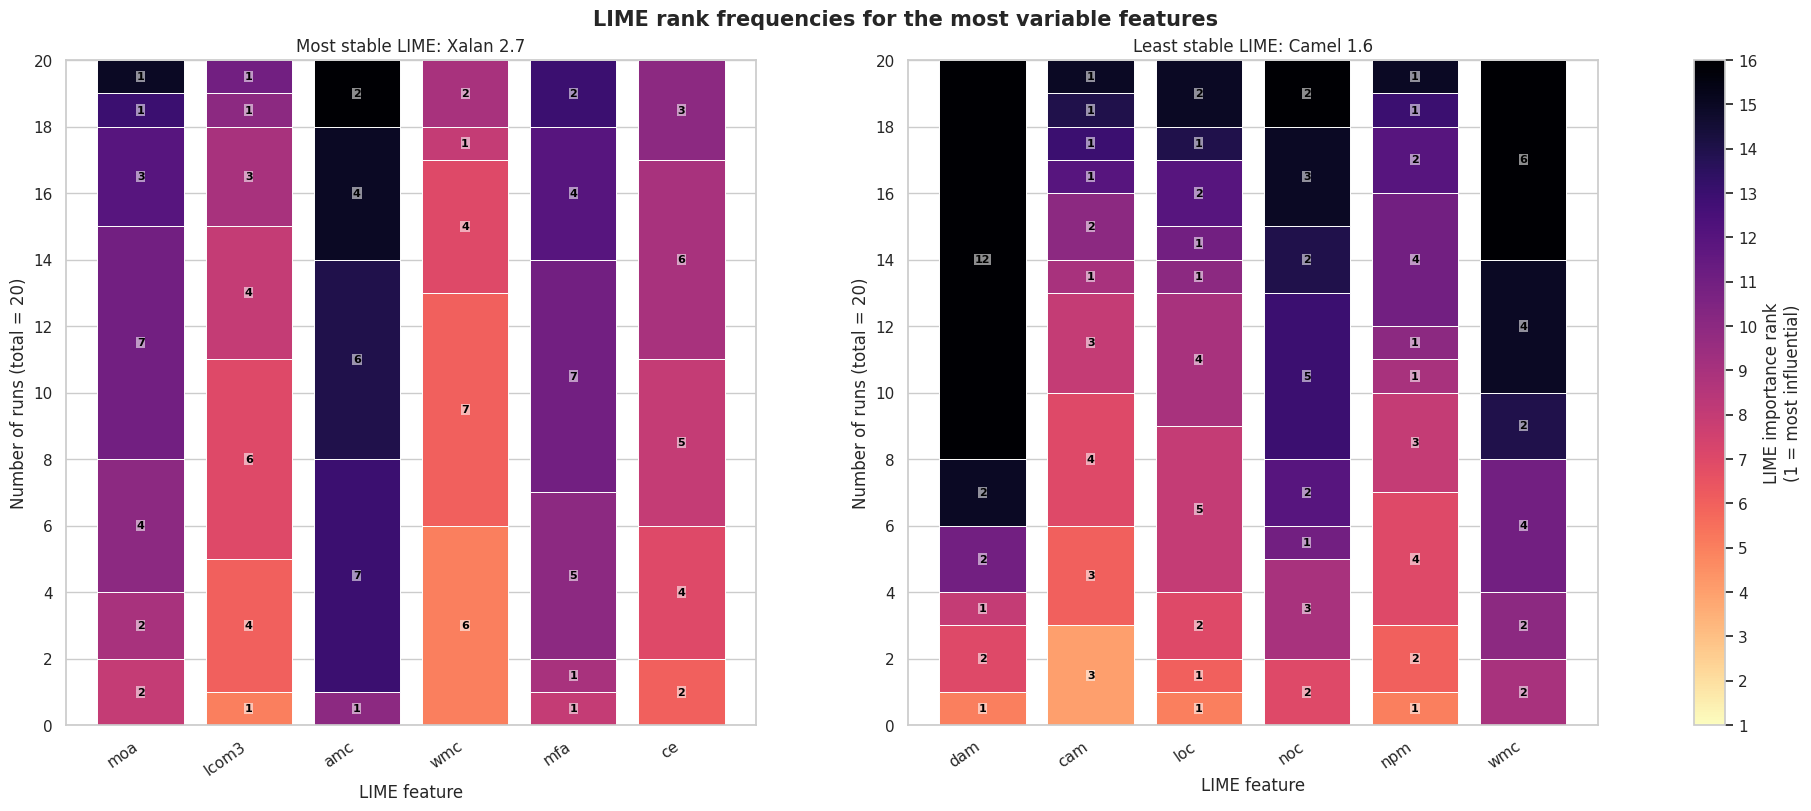

Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_LIME_Rank_Variability_Selected_Cases.csv


PosixPath('/content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_LIME_Rank_Variability_Selected_Cases.csv')

In [77]:
# Figure 4.16 — vertical rank-frequency distribution for
# the six most variable LIME features in each selected case

fig = plt.figure(
    figsize=(18, 8),
    constrained_layout=True,
)

# Dedicated third column prevents the colour scale from
# overlapping either subplot
grid = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.045],
    wspace=0.16,
)

axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
]

colour_bar_axes = fig.add_subplot(grid[0, 2])

lime_variability_rows = []

rank_cmap = plt.get_cmap("magma_r")
rank_norm = plt.Normalize(
    vmin=1,
    vmax=len(final_feature_cols),
)

for ax, selection, case in zip(
    axes,
    ["Most stable LIME", "Least stable LIME"],
    [most_lime, least_lime],
):
    ranks = case_rank_frame(
        case,
        method="LIME",
    )

    variability = ranks.agg(
        ["mean", "std", "min", "max"]
    ).T

    variability["range"] = (
        variability["max"]
        - variability["min"]
    )

    variability = variability.sort_values(
        ["std", "range"],
        ascending=False,
    )

    variable_features = (
        variability.index[:6].tolist()
    )

    frequency = pd.DataFrame({
        feature: ranks[feature].value_counts()
        for feature in variable_features
    }).T.reindex(
        columns=range(
            1,
            len(final_feature_cols) + 1,
        ),
        fill_value=0,
    )

    frequency = frequency.fillna(0).astype(int)

    x_position = np.arange(
        len(variable_features)
    )

    bottom = np.zeros(
        len(variable_features),
        dtype=int,
    )

    for rank_value in range(
        1,
        len(final_feature_cols) + 1,
    ):
        counts = frequency[
            rank_value
        ].to_numpy()

        bars = ax.bar(
            x_position,
            counts,
            bottom=bottom,
            color=rank_cmap(
                rank_norm(rank_value)
            ),
            edgecolor="white",
            linewidth=0.7,
        )

        for bar, count in zip(bars, counts):
            if count > 0:
                ax.text(
                    bar.get_x()
                    + bar.get_width() / 2,
                    bar.get_y()
                    + bar.get_height() / 2,
                    str(int(count)),
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black",
                    bbox={
                        "facecolor": "white",
                        "alpha": 0.55,
                        "edgecolor": "none",
                        "pad": 0.5,
                    },
                )

        bottom += counts

    ax.set_xticks(
        x_position,
        variable_features,
        rotation=35,
        ha="right",
    )

    ax.set_title(
        f"{selection}: {case['Dataset']}"
    )

    ax.set_xlabel("LIME feature")

    ax.set_ylabel(
        f"Number of runs "
        f"(total = {len(ranks)})"
    )

    ax.set_ylim(0, len(ranks))

    ax.yaxis.set_major_locator(
        plt.MaxNLocator(integer=True)
    )

    for feature in final_feature_cols:
        lime_variability_rows.append({
            "Selection": selection,
            "Dataset": case["Dataset"],
            "Feature": feature,
            "Mean rank": ranks[feature].mean(),
            "Rank SD": ranks[feature].std(),
            "Min rank": ranks[feature].min(),
            "Max rank": ranks[feature].max(),
            "Distinct ranks": (
                ranks[feature].nunique()
            ),
        })

rank_mapper = plt.cm.ScalarMappable(
    cmap=rank_cmap,
    norm=rank_norm,
)

rank_mapper.set_array([])

colour_bar = fig.colorbar(
    rank_mapper,
    cax=colour_bar_axes,
)

colour_bar.set_label(
    "LIME importance rank\n"
    "(1 = most influential)"
)

colour_bar.set_ticks(
    range(1, len(final_feature_cols) + 1)
)

fig.suptitle(
    "LIME rank frequencies for the most variable features",
    fontsize=15,
    fontweight="bold",
)

fig.savefig(
    FIGURE_DIR
    / "Figure_4_16_LIME_Rank_Frequency_Selected_Cases.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

save_table(
    pd.DataFrame(lime_variability_rows),
    "Appendix_RQ3_LIME_Rank_Variability_Selected_Cases.csv",
    folder=APPENDIX_DIR,
)

### 10.6 Per-instance LIME stability


#### 10.6.1 Per-instance stability summary


In [78]:
instance_w_rows = []
instance_w_detail_rows = []
for selection, case in [("Most stable LIME", most_lime), ("Least stable LIME", least_lime)]:
    dataset_name = case["Dataset"]
    part = stability_local[stability_local["Dataset"] == dataset_name]
    w_values = []
    for subset_position, instance_part in part.groupby("Subset position"):
        instance_part = instance_part.sort_values("Seed")
        w_value = kendalls_w(instance_part[rank_columns].to_numpy())[0]
        w_values.append(w_value)
        instance_w_detail_rows.append({
            "Selection": selection, "Dataset": dataset_name,
            "Subset position": int(subset_position), "Kendall's W": w_value,
        })
    values = pd.Series(w_values)
    instance_w_rows.append({
        "Selection": selection, "Dataset": dataset_name,
        "Median W": values.median(),
        "IQR": values.quantile(0.75) - values.quantile(0.25),
        "Min": values.min(), "Max": values.max(),
        "Instances with W < 0.5": f"{int((values < 0.5).sum())} / {len(values)}",
    })

table_4_27 = pd.DataFrame(instance_w_rows)
rq3_lime_instance_stability_detail = pd.DataFrame(instance_w_detail_rows)
save_table(table_4_27, "Table_4_27_Per_Instance_LIME_Stability.csv")
save_table(
    rq3_lime_instance_stability_detail,
    "Appendix_RQ3_Per_Instance_LIME_W_Selected_Cases.csv",
    folder=APPENDIX_DIR,
)
display(table_4_27.round(3))


Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/tables/Table_4_27_Per_Instance_LIME_Stability.csv
Saved: /content/drive/MyDrive/Software_Defect_Prediction/rq1_rq3_results/appendix/Appendix_RQ3_Per_Instance_LIME_W_Selected_Cases.csv


,Selection,Dataset,Median W,IQR,Min,Max,Instances with W < 0.5
0,Most stable LIME,Xalan 2.7,0.638,0.094,0.450,0.822,1 / 50
1,Least stable LIME,Camel 1.6,0.615,0.063,0.453,0.712,3 / 50


#### 10.6.2 Distribution of per-instance stability


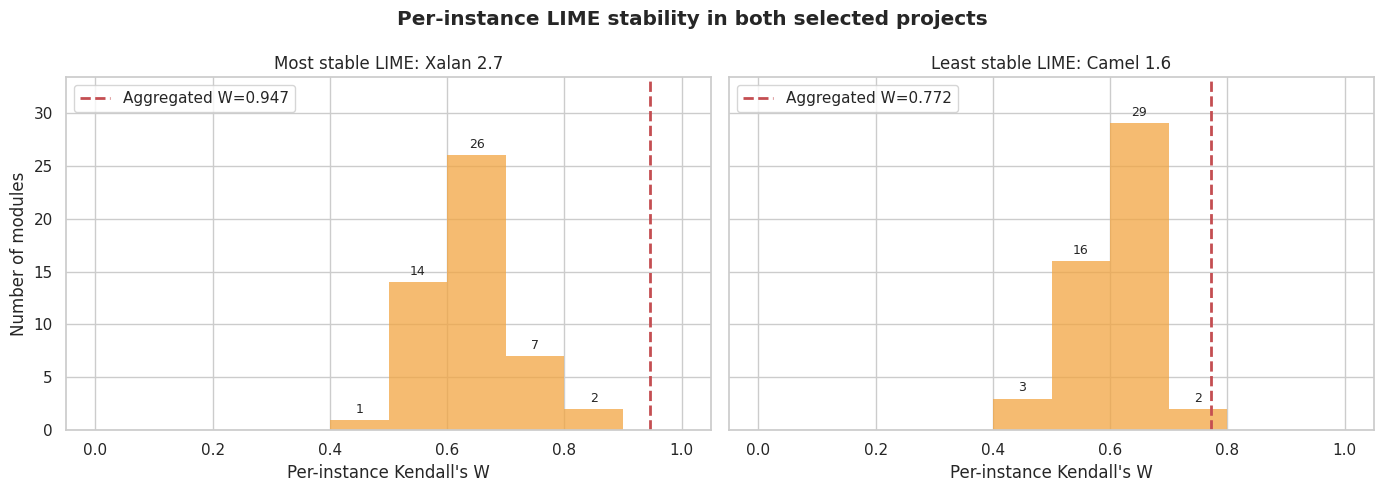

In [79]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, selection, case in zip(axes, ["Most stable LIME", "Least stable LIME"], [most_lime, least_lime]):
    dataset_name = case["Dataset"]
    values = rq3_lime_instance_stability_detail.query(
        "Selection == @selection and Dataset == @dataset_name"
    )["Kendall's W"]

    sns.histplot(values, bins=np.linspace(0, 1, 11), color="#F2A541",
                 edgecolor="none", ax=ax)

    for container in ax.containers:
        labels = [
            f"{int(bar.get_height())}" if bar.get_height() > 0 else ""
            for bar in container
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

    aggregate_w = stability_lookup[(dataset_name, "LIME")]
    ax.axvline(aggregate_w, color="#C44E52", linestyle="--", linewidth=2,
               label=f"Aggregated W={aggregate_w:.3f}")
    ax.set_title(f"{selection}: {dataset_name}")
    ax.set_xlabel("Per-instance Kendall's W")
    ax.margins(y=0.15)
    ax.legend()

axes[0].set_ylabel("Number of modules")
fig.suptitle("Per-instance LIME stability in both selected projects",
             fontweight="bold")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "Figure_4_17_Per_Instance_LIME_W_Selected_Cases.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

Table 4.27 and Figure 4.17 present the distribution of per-instance Kendall’s W values across the 50 selected test modules for the most- and least-stable LIME projects. Each value measures the agreement of one module's LIME feature rankings across 20 repeated SMOTE-XGBoost runs; higher values indicate more repeatable local explanations.

For Xalan 2.7, 26 of the 50 modules have W values between 0.6 and 0.7, while nine exceed 0.7 and only one falls below 0.5. Camel 1.6 has 29 modules between 0.6 and 0.7, 16 between 0.5 and 0.6, two above 0.7 and three below 0.5. Xalan therefore produces more highly stable local explanations and fewer weakly stable cases, although the difference between the median values is modest.

The dashed lines show aggregated LIME stability for Xalan (W=0.947) and Camel (W=0.772). These values are not averages of the per-instance coefficients: aggregated Kendall's W measures the consistency of the overall feature ranking across runs, whereas per-instance Kendall's W measures the repeatability of an individual module's explanation. The two analyses are therefore complementary.


## 12. Discussion

### 12.1 Predictive performance and class imbalance — RQ1

The first research question examined the effectiveness of six machine learning algorithms under the Original and SMOTE training conditions. XGBoost achieved the highest overall cross-validated ROC-AUC and was therefore selected as the champion model. Its mean cross-validated ROC-AUC was 0.845 under the Original condition and 0.836 under SMOTE. Although Random Forest achieved a slightly higher mean SMOTE F1-score than XGBoost, ROC-AUC was defined as the primary model-selection metric because it evaluates discrimination across all possible classification thresholds.

The held-out results show that SMOTE did not improve every metric or dataset uniformly. ROC-AUC increased slightly for Poi, Camel, Log4j and Xalan but decreased for Ant. More substantial improvements were observed in threshold-dependent measures for Ant and Camel, where SMOTE increased recall and consequently improved F1-score. This suggests that SMOTE primarily changed the model’s classification behaviour by increasing its sensitivity to defective modules rather than consistently improving its overall ability to distinguish between the two classes.

Accuracy and F1-score must be interpreted carefully for Log4j and Xalan because defective modules constitute the majority class in these datasets. Since the defective class was treated as the positive class, a model could obtain high accuracy and F1-score by correctly predicting the dominant defective class while performing poorly on the small number of non-defective modules. This limitation is particularly important for Xalan, whose test set contains only approximately three non-defective modules. Therefore, the results support evaluating defect predictors using multiple metrics instead of relying on accuracy alone.

Overall, RQ1 demonstrates that XGBoost provides the strongest discrimination across the five projects, while the effect of SMOTE is dataset-dependent. SMOTE may improve minority-class recognition, but it should not be assumed to produce a universal performance improvement.

### 12.2 Influential metrics and explanation consistency — RQ2

Full-test SHAP analysis was used as the primary source of global feature importance because SHAP provides contributions for every module in the test set. The results show that the influential static code metrics differ across projects. Cross-project agreement was weak, with Kendall’s \(W=0.294\), a mean pairwise Kendall’s \(\tau=0.070\), and a mean top-five Jaccard similarity of 0.183. The Kendall’s W result was not statistically significant (\(p=0.106\)), indicating insufficient evidence that the five projects share a common feature ordering.

This finding suggests that the relationships between static code metrics and defect predictions are project-specific. Differences in project size, architecture, development practices, defect distribution and interactions among metrics may cause XGBoost to rely on different predictors for each dataset. Consequently, a metric identified as influential in one project should not automatically be treated as equally important in another. Project-level explanations are therefore more appropriate than a single universal ranking of software metrics.

The comparison between SHAP and aggregated LIME also showed that explanation methods do not always produce identical conclusions. Log4j achieved the strongest agreement, with Kendall’s \(\tau=0.767\) and complete top-five overlap. Poi and Xalan also demonstrated relatively strong agreement, while Camel showed moderate agreement. Ant recorded the weakest agreement, with \(\tau=0.400\) and a top-five Jaccard similarity of 0.250. This means that SHAP and LIME shared only two of their five leading features for Ant.

These differences do not necessarily indicate that either method is incorrect. SHAP estimates feature contributions according to a Shapley-value framework, whereas LIME constructs a locally weighted surrogate model using perturbed observations. The methods therefore approximate model behaviour differently. Agreement between them strengthens confidence that the highlighted features are not dependent on a single explanation technique, while disagreement indicates that the explanation should be interpreted more cautiously.

The fixed 50-module subset was used to ensure that SHAP and LIME were compared using the same observations. Its representativeness was supported by strong agreement between the full-test and subset-based SHAP rankings, with Kendall’s \(\tau\) ranging from 0.817 to 1.000. Nevertheless, aggregated LIME importance remains a constructed summary of local explanations and should not be interpreted as equivalent to full-test global SHAP importance. The full-test SHAP ranking remains the principal answer for influential metrics, while aggregated LIME is used for controlled cross-method comparison.

### 12.3 Explanation stability across repeated runs — RQ3

The third research question examined whether SHAP and LIME feature rankings remained consistent across 20 repeated SMOTE-XGBoost runs. SHAP achieved a higher mean all-feature Kendall’s W than LIME, with values of 0.937 and 0.893 respectively. This indicates that SHAP rankings were generally more repeatable across changes in the random seed. However, the difference was not universal because LIME was slightly more stable than SHAP for Ant.

Xalan was the most stable project for both methods, with \(W=0.986\) for SHAP and \(W=0.947\) for LIME. The least-stable SHAP project was Ant (\(W=0.862\)), whereas Camel produced the lowest LIME stability (\(W=0.772\)). The heatmaps and rank-frequency plots show that variation occurred mainly among features with similar or intermediate levels of importance. The leading features were more stable than the middle-ranked features: mean top-five W was 0.816 for SHAP and 0.733 for LIME, compared with 0.701 and 0.487 for their respective middle-ranked features. Small differences between middle-ranking positions should therefore not be interpreted as meaningful changes in feature influence.

Changes in explanation rankings must also be considered alongside changes in the underlying predictive model. The ROC-AUC ranges across seeds were between 0.017 and 0.063, demonstrating that the trained models were not identical but generally maintained similar predictive performance. The seed-sensitivity check is important because a Kendall’s W of 1.000 from identical deterministic models would measure algorithmic determinism rather than robustness to meaningful model variation.

The per-instance LIME analysis provides a more detailed view of local stability. Xalan obtained a median per-instance W of 0.638, with only one of 50 modules below 0.5. Camel obtained a slightly lower median of 0.615, with three modules below 0.5. Therefore, most local explanations demonstrated moderate repeatability, but individual modules could still be less stable than the aggregated project ranking suggested. Aggregated stability and per-instance stability should consequently be reported as complementary evidence.

Overall, RQ3 shows that SHAP is generally more stable than LIME for global feature-ranking analysis. Nevertheless, neither aggregated stability nor strong predictive performance guarantees that every individual explanation will remain unchanged.

### 12.4 Practical implications

The findings have several implications for the practical use of explainable software defect prediction. First, developers should interpret feature importance within the context of the project being analysed because the influential metrics were not consistent across projects. Second, explanation agreement and stability should be evaluated before SHAP or LIME outputs are used to guide code inspection or refactoring. Third, highly ranked and repeatedly selected features provide stronger evidence than features whose positions change frequently. Finally, local explanations for important or high-risk modules should be examined individually because high aggregated stability may conceal unstable module-level explanations.

### 12.5 Limitations

This study is limited to five Java projects obtained from the PROMISE repository, which restricts the generalisability of the findings to other programming languages, application domains and development environments. Some datasets also contain extremely small minority classes, particularly Xalan, making performance estimates sensitive to a small number of test observations.

The explanation analyses are conditional on the selected SMOTE-XGBoost models and the adopted preprocessing, hyperparameters and classification threshold. Different models or balancing strategies may produce different feature rankings. In addition, LIME was aggregated over a fixed subset of 50 modules and used a finite number of perturbation samples. Although the subset showed strong agreement with the full-test SHAP rankings, it does not represent every possible local explanation.

Finally, ranking agreement and stability measure repeatability rather than explanation correctness, causal importance or usefulness to software developers. A stable explanation may still provide an incomplete representation of the model’s behaviour. Future evaluation should therefore consider explanation fidelity, robustness to input perturbations and assessments involving software practitioners.

## 13. Conclusion

This study developed an explainable software defect prediction framework using five PROMISE Java project datasets. Six machine learning algorithms were evaluated under Original and SMOTE training conditions, after which the selected XGBoost models were interpreted using SHAP and LIME. The study considered predictive performance, influential static code metrics, cross-project and cross-method consistency, and explanation stability across repeated runs.

For RQ1, XGBoost achieved the highest overall cross-validated ROC-AUC. However, SMOTE produced dataset-dependent effects: it improved recall and F1-score for some projects but did not consistently increase ROC-AUC. These results demonstrate that class balancing should be evaluated empirically rather than assumed to improve all aspects of predictive performance.

For RQ2, SHAP identified influential metrics that varied considerably across projects. Weak cross-project ranking agreement indicates that no single universal feature ordering adequately represents all five datasets. SHAP and LIME showed moderate to strong agreement in most projects, although the weaker agreement observed for Ant demonstrates that conclusions can depend on the explanation method.

For RQ3, SHAP produced higher average ranking stability than LIME across the 20 repeated SMOTE-XGBoost runs. Leading features were generally more stable than middle-ranked features, while per-instance analysis showed that aggregated stability could conceal variation in individual LIME explanations. Explanation reliability should therefore be evaluated at both the project and module levels.

The main contribution of this study is the integration of predictive evaluation with cross-project consistency, cross-method agreement and repeated-run stability analysis. The findings show that an explanation should not be considered reliable solely because it is visually understandable or generated by a widely used XAI method. Reliable explainable software defect prediction requires evidence that the model performs adequately, the explanation is appropriate for the project, and the identified feature relationships remain sufficiently consistent under repeated experimental conditions.

Future research could evaluate additional project versions, programming languages and industrial datasets; compare SMOTE with class weighting and alternative resampling methods; examine other predictive and explanation algorithms; increase the number of repeated runs; and incorporate developer-based evaluations of explanation usefulness and comprehensibility.
